In [ ]:
import os
os.environ["HF_HOME"] = "/content/drive/MyDrive/hf_cache"
os.environ["HF_HUB_CACHE"] = "/content/drive/MyDrive/hf_cache"


In [3]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
import pandas as pd

TRAIN_PATH = "/content/drive/MyDrive/Distill_Ensemble/train-00000-of-00001.parquet"
TEST_PATH  = "/content/drive/MyDrive/Distill_Ensemble/test-00000-of-00001.parquet"

df_train = pd.read_parquet(TRAIN_PATH)
df_test  = pd.read_parquet(TEST_PATH)

def choices_len(x):
    try:
        return len(x)
    except:
        return -1

def answer_in_range(ans, ch_len):
    try:
        a = int(ans)
        return (ch_len > 0) and (0 <= a < ch_len)
    except:
        return False

def quality_report(df, name):
    bos_soru = df["soru"].isna().sum() + df["soru"].astype(str).str.strip().eq("").sum()
    lens = df["secenekler"].apply(choices_len)
    bos_secenek = (lens <= 0).sum()
    cevap_out = sum([not answer_in_range(a, l) for a, l in zip(df["cevap"], lens)])

    print(f"\n=== QUALITY REPORT: {name} ===")
    print("Toplam:", len(df))
    print("Bos soru:", int(bos_soru))
    print("Bos secenekler:", int(bos_secenek))
    print("Cevap out-of-range:", int(cevap_out))
    print("\nSecenek sayisi dagilimi (ilk 10):")
    print(lens.value_counts().sort_index().head(10))

quality_report(df_train, "TRAIN")
quality_report(df_test, "TEST")



=== QUALITY REPORT: TRAIN ===
Toplam: 232136
Bos soru: 0
Bos secenekler: 0
Cevap out-of-range: 0

Secenek sayisi dagilimi (ilk 10):
secenekler
5    232136
Name: count, dtype: int64

=== QUALITY REPORT: TEST ===
Toplam: 40966
Bos soru: 0
Bos secenekler: 0
Cevap out-of-range: 0

Secenek sayisi dagilimi (ilk 10):
secenekler
5    40966
Name: count, dtype: int64


In [ ]:
import pandas as pd

TRAIN_PATH = "/content/drive/MyDrive/Distill_Ensemble/train-00000-of-00001.parquet"
TEST_PATH  = "/content/drive/MyDrive/Distill_Ensemble/test-00000-of-00001.parquet"

df_train = pd.read_parquet(TRAIN_PATH)
df_test  = pd.read_parquet(TEST_PATH)

# Train ve test sayimlarini ayri ayri al
train_counts = df_train["bolum"].value_counts().rename("train")
test_counts  = df_test["bolum"].value_counts().rename("test")

# Birlestir, toplam ekle
bolum_tbl = pd.concat([train_counts, test_counts], axis=1).fillna(0).astype(int)
bolum_tbl["total"] = bolum_tbl["train"] + bolum_tbl["test"]

# En coktan en aza sirala
bolum_tbl = bolum_tbl.sort_values("total", ascending=False)

print("=== BOLUM SAYIMLARI (TRAIN / TEST / TOTAL) ===")
print("Toplam farkli bolum sayisi:", bolum_tbl.shape[0])
print("\nIlk 30 bolum:\n")
print(bolum_tbl.head(30).to_string())


=== BOLUM SAYIMLARI (TRAIN / TEST / TOTAL) ===
Toplam farkli bolum sayisi: 66

Ilk 30 bolum:

                                             train   test  total
bolum                                                           
Adalet                                       53325      0  53325
Aşçılık                                      16619      0  16619
Bankacılık ve Sigortacılık                   16567      0  16567
Kim 500 Milyar İster                            11  12968  12979
Çocuk Gelişimi                                9995   2597  12592
Çağrı Merkezi Hizmetleri                     11706      0  11706
TUS                                           9893   1510  11403
Büro Yönetimi ve Yönetici Asistanlığı        10673      0  10673
YGS Denemeleri                                5635   4154   9789
Emlak ve Emlak Yönetimi                       7969      0   7969
Laborant ve Veteriner Sağlık                  5266   1485   6751
Fotoğrafçılık ve Kameramanlık                 6687      0   6

In [ ]:
import pandas as pd

TRAIN_PATH = "/content/drive/MyDrive/Distill_Ensemble/train-00000-of-00001.parquet"
TEST_PATH  = "/content/drive/MyDrive/Distill_Ensemble/test-00000-of-00001.parquet"


df_train = pd.read_parquet(TRAIN_PATH)
df_test  = pd.read_parquet(TEST_PATH)

BOLUM_SECIM = "YGS Denemeleri"

train_sub = df_train[df_train["bolum"] == BOLUM_SECIM]
test_sub  = df_test[df_test["bolum"] == BOLUM_SECIM]

train_counts = train_sub["konu"].value_counts().rename("train")
test_counts  = test_sub["konu"].value_counts().rename("test")

konu_tbl = pd.concat([train_counts, test_counts], axis=1).fillna(0).astype(int)
konu_tbl["total"] = konu_tbl["train"] + konu_tbl["test"]
konu_tbl = konu_tbl.sort_values("total", ascending=False)

print(f"=== KONU SAYIMLARI ({BOLUM_SECIM}) ===")
print("Train:", len(train_sub), "| Test:", len(test_sub), "| Total:", len(train_sub) + len(test_sub))
print("Toplam farkli konu sayisi:", konu_tbl.shape[0])
print("\nIlk 50 konu:\n")
print(konu_tbl.head(50).to_string())


=== KONU SAYIMLARI (YGS Denemeleri) ===
Train: 5635 | Test: 4154 | Total: 9789
Toplam farkli konu sayisi: 19

Ilk 50 konu:

                                train  test  total
konu                                              
EDEBİYAT KONU SORULARI           1433   218   1651
TÜRKÇE KONU SORULARI              857   340   1197
TARİH KONU SORULARI               547   535   1082
DİL VE ANLATIM                      0  1007   1007
FELSEFE KONU SORULARI             703   174    877
EDEBİYAT DENEME SINAVLARI         498   161    659
TARİH ÇÖZÜMLÜ DENEMELER           335   284    619
FELSEFE DENEMELER                 374   103    477
BİYOLOJİ KONU SORULARI            195   272    467
COĞRAFYA KONU SORULARI             14   337    351
MATEMATİK KONU SORULARI             3   247    250
EDEBİYAT ÇIKMIŞ SORULAR           153    67    220
TÜRKÇE ÇIKMIŞ SORULAR             130    51    181
TÜRKÇE DENEMELER                  120    61    181
KİMYA KONU SORULARI                67    98    165
SOSYAL Bİ

In [ ]:
import pandas as pd

TRAIN_PATH = "/content/drive/MyDrive/Distill_Ensemble/train-00000-of-00001.parquet"
TEST_PATH  = "/content/drive/MyDrive/Distill_Ensemble/test-00000-of-00001.parquet"

df_train = pd.read_parquet(TRAIN_PATH)
df_test  = pd.read_parquet(TEST_PATH)

# 1. Aşama: YGS Denemeleri bölümünü baz alıyoruz
HEDEF_BOLUM = "YGS Denemeleri"

# 2. Aşama: Modelin 'Reasoning' (Akıl Yürütme) yeteneğine en uygun konuları seçiyoruz
# Edebiyat ve Türkçe yerine Matematik, Geometri ve Fen Bilimlerine odaklanıyoruz.
HEDEF_KONULAR = [
    "MATEMATİK KONU SORULARI",
    "GEOMETRİ KONU SORULARI",
    "FİZİK KONU SORULARI",
    "KİMYA KONU SORULARI",
    "BİYOLOJİ KONU SORULARI"
]

# Birleştirme
df_all = pd.concat([df_train, df_test], ignore_index=True)

# Filtreleme: Önce bölümü, sonra modelin başarılı olabileceği mantıksal konuları seç
df_sub = df_all[
    (df_all["bolum"] == HEDEF_BOLUM) &
    (df_all["konu"].isin(HEDEF_KONULAR))
].reset_index(drop=True)

print("Toplam secilen (Sayısal/Mantıksal) soru sayisi:", len(df_sub))
print(df_sub["konu"].value_counts())

# --- İnceleme İçin Örnek Gösterimi ---
SAMPLE_N = min(20, len(df_sub))
if SAMPLE_N > 0:
    sample = df_sub.sample(n=SAMPLE_N, random_state=42)
    print("\n=== MODELİN BAŞARILI OLABİLECEĞİ ÖRNEK SORULAR ===\n")
    for i, r in enumerate(sample.itertuples(), 1):
        print("="*80)
        print(f"SORU {i} | Konu: {r.konu}")
        print(f"\nSoru:\n{r.soru}")
        print("\nSecenekler:")
        for idx, opt in enumerate(r.secenekler):
            letters = ["A","B","C","D","E"]
            print(f"{letters[idx]}) {opt}")
        print(f"\nGerçek Cevap: {r.cevap}")
else:
    print("Belirtilen kriterlerde soru bulunamadı.")

Toplam secilen (Sayısal/Mantıksal) soru sayisi: 1066
konu
BİYOLOJİ KONU SORULARI     467
MATEMATİK KONU SORULARI    250
KİMYA KONU SORULARI        165
GEOMETRİ KONU SORULARI      97
FİZİK KONU SORULARI         87
Name: count, dtype: int64

=== MODELİN BAŞARILI OLABİLECEĞİ ÖRNEK SORULAR ===

SORU 1 | Konu: BİYOLOJİ KONU SORULARI

Soru:
Glikoliz tepkimeleri sırasında, aşağıdaki olaylardan hangisi gerçekleşmez?

Secenekler:
A) ATP tüketimi
B) CO2 açığa çıkması
C) NADH + H+ oluşumu
D) Pirüvat oluşumu
E) ATP üretimi

Gerçek Cevap: 1
SORU 2 | Konu: MATEMATİK KONU SORULARI

Soru:
f(x) = x² – 4x + 5
fonksiyonuna x = 3 apsisli noktadan çizilen normalin
egimi kaçtır?

Secenekler:
A) –1
B) –1/-2
C) 0
D) 1/2
E) 1

Gerçek Cevap: 1
SORU 3 | Konu: BİYOLOJİ KONU SORULARI

Soru:
Mitoz bölünmenin profaz evresinde olan bir hücrede, I. kromozom, II. çekirdek zarı, III. çekirdekçik, IV. iğ ipliği yapılarından hangileri yeni oluşmaya başlar?

Secenekler:
A) Yalnız IV
B) I ve II
C) I ve IV
D) II ve IV
E) I, 

In [ ]:
import pandas as pd

TRAIN_PATH = "/content/drive/MyDrive/Distill_Ensemble/train-00000-of-00001.parquet"
TEST_PATH  = "/content/drive/MyDrive/Distill_Ensemble/test-00000-of-00001.parquet"


df_train = pd.read_parquet(TRAIN_PATH)
df_test  = pd.read_parquet(TEST_PATH)

BOLUM_SECIM = "KPSS Denemeleri"

train_sub = df_train[df_train["bolum"] == BOLUM_SECIM]
test_sub  = df_test[df_test["bolum"] == BOLUM_SECIM]

train_counts = train_sub["konu"].value_counts().rename("train")
test_counts  = test_sub["konu"].value_counts().rename("test")

konu_tbl = pd.concat([train_counts, test_counts], axis=1).fillna(0).astype(int)
konu_tbl["total"] = konu_tbl["train"] + konu_tbl["test"]
konu_tbl = konu_tbl.sort_values("total", ascending=False)

print(f"=== KONU SAYIMLARI ({BOLUM_SECIM}) ===")
print("Train:", len(train_sub), "| Test:", len(test_sub), "| Total:", len(train_sub) + len(test_sub))
print("Toplam farkli konu sayisi:", konu_tbl.shape[0])
print("\nIlk 50 konu:\n")
print(konu_tbl.head(50).to_string())


=== KONU SAYIMLARI (KPSS Denemeleri) ===
Train: 3385 | Test: 2674 | Total: 6059
Toplam farkli konu sayisi: 12

Ilk 50 konu:

                            train  test  total
konu                                          
VATANDAŞLIK KONU SINAVLARI    561   339    900
GENEL KÜLTÜR DENEME           546   228    774
GENEL YETENEK DENEMELER       326   384    710
TARİH DENEMELER               285   340    625
TÜRKÇE DENEMELER              352   223    575
TARİH KONU SINAVLARI          329   245    574
VATANDAŞLIK DENEMELER         340   182    522
COĞRAFYA KONU SINAVLARI       287   120    407
MATEMATİK KONU SORULARI        30   344    374
EĞİTİM BİLİMLERİ              191    98    289
MATEMATİK DENEMELER            23   139    162
COĞRAFYA DENEME               115    32    147


In [ ]:
import pandas as pd

TRAIN_PATH = "/content/drive/MyDrive/Distill_Ensemble/train-00000-of-00001.parquet"
TEST_PATH  = "/content/drive/MyDrive/Distill_Ensemble/test-00000-of-00001.parquet"

df_train = pd.read_parquet(TRAIN_PATH)
df_test  = pd.read_parquet(TEST_PATH)


HEDEF_BOLUM = "KPSS Denemeleri"

HEDEF_KONULAR = [
    "MATEMATİK KONU SORULARI",
    "GENEL YETENEK DENEMELER"
]

# Birleştirme
df_all = pd.concat([df_train, df_test], ignore_index=True)

# Filtreleme: Önce bölümü, sonra modelin başarılı olabileceği mantıksal konuları seç
df_sub = df_all[
    (df_all["bolum"] == HEDEF_BOLUM) &
    (df_all["konu"].isin(HEDEF_KONULAR))
].reset_index(drop=True)

print("Toplam secilen (Sayısal/Mantıksal) soru sayisi:", len(df_sub))
print(df_sub["konu"].value_counts())

# --- İnceleme İçin Örnek Gösterimi ---
SAMPLE_N = min(20, len(df_sub))
if SAMPLE_N > 0:
    sample = df_sub.sample(n=SAMPLE_N, random_state=42)
    print("\n=== MODELİN BAŞARILI OLABİLECEĞİ ÖRNEK SORULAR ===\n")
    for i, r in enumerate(sample.itertuples(), 1):
        print("="*80)
        print(f"SORU {i} | Konu: {r.konu}")
        print(f"\nSoru:\n{r.soru}")
        print("\nSecenekler:")
        for idx, opt in enumerate(r.secenekler):
            letters = ["A","B","C","D","E"]
            print(f"{letters[idx]}) {opt}")
        print(f"\nGerçek Cevap: {r.cevap}")
else:
    print("Belirtilen kriterlerde soru bulunamadı.")

Toplam secilen (Sayısal/Mantıksal) soru sayisi: 1084
konu
GENEL YETENEK DENEMELER    710
MATEMATİK KONU SORULARI    374
Name: count, dtype: int64

=== MODELİN BAŞARILI OLABİLECEĞİ ÖRNEK SORULAR ===

SORU 1 | Konu: GENEL YETENEK DENEMELER

Soru:
m ve n gerçel sayılarının geometrik ortalaması 5, m + 2 ve n -2 sayılarının geometrik ortalaması ise 7 dir. Buna göre, m - n farkı kaçtır?

Secenekler:
A) -14
B) 14
C) -28
D) 28
E) -12

Gerçek Cevap: 0
SORU 2 | Konu: GENEL YETENEK DENEMELER

Soru:
Yaşamımızda vazgeçilmez bir yer kazanan yazı birdenbire ortaya çıkmamış, binlerce yıllık bir gelişme sürecinde sistemleşmiş, bugünkü halini almıştır. Bugün kullanılan yazıların bulunmasına kadar çeşitli yazılar kullanılmış sonunda hep kolay okunup yazılabilen yazılara varılmıştır. Yazı sözcüğü, sözü çizgilerle gösterme sistemi anlamında düşünülürse en eski yazı örnekleri insanla birlikte başlar. Bu parçadan yazıyla ilgili aşağıdakilerden hangisi çıkarılamaz?

Secenekler:
A) Farklı türlerinin olduğu
B) 

In [ ]:
import pandas as pd

TRAIN_PATH = "/content/drive/MyDrive/Distill_Ensemble/train-00000-of-00001.parquet"
TEST_PATH  = "/content/drive/MyDrive/Distill_Ensemble/test-00000-of-00001.parquet"

df_train = pd.read_parquet(TRAIN_PATH)
df_test  = pd.read_parquet(TEST_PATH)

BOLUM_SECIM = "Muhasebe ve Vergi Uygulamaları"

train_sub = df_train[df_train["bolum"] == BOLUM_SECIM]
test_sub  = df_test[df_test["bolum"] == BOLUM_SECIM]

train_counts = train_sub["konu"].value_counts().rename("train")
test_counts  = test_sub["konu"].value_counts().rename("test")

konu_tbl = pd.concat([train_counts, test_counts], axis=1).fillna(0).astype(int)
konu_tbl["total"] = konu_tbl["train"] + konu_tbl["test"]
konu_tbl = konu_tbl.sort_values("total", ascending=False)

print(f"=== KONU SAYIMLARI ({BOLUM_SECIM}) ===")
print("Train:", len(train_sub), "| Test:", len(test_sub), "| Total:", len(train_sub) + len(test_sub))
print("Toplam farkli konu sayisi:", konu_tbl.shape[0])
print("\nIlk 50 konu:\n")
print(konu_tbl.head(50).to_string())


=== KONU SAYIMLARI (Muhasebe ve Vergi Uygulamaları) ===
Train: 1778 | Test: 474 | Total: 2252
Toplam farkli konu sayisi: 9

Ilk 50 konu:

                      train  test  total
konu                                    
Vergi uygulamaları      369   146    515
Envarter ve Bilanço     244    68    312
Muhasebe Yazılımları    233    45    278
Şirketler Muhasebesi    213    30    243
Maliyet Analizleri      203    39    242
Kamu Maliyesi           181    52    233
Muhasebe ve Hukuk       190    33    223
Muhasebe Denetimi        87    26    113
Genel Vergi Hukuku       58    35     93


In [ ]:
import pandas as pd

TRAIN_PATH = "/content/drive/MyDrive/Distill_Ensemble/train-00000-of-00001.parquet"
TEST_PATH  = "/content/drive/MyDrive/Distill_Ensemble/test-00000-of-00001.parquet"


df_train = pd.read_parquet(TRAIN_PATH)
df_test  = pd.read_parquet(TEST_PATH)

# 1. Aşama: YGS Denemeleri bölümünü baz alıyoruz
HEDEF_BOLUM = "Muhasebe ve Vergi Uygulamaları"

# 2. Aşama: Modelin 'Reasoning' (Akıl Yürütme) yeteneğine en uygun konuları seçiyoruz
# Edebiyat ve Türkçe yerine Matematik, Geometri ve Fen Bilimlerine odaklanıyoruz.
HEDEF_KONULAR = [
    "Kamu Maliyesi",
    "Vergi uygulamaları"
]

# Birleştirme
df_all = pd.concat([df_train, df_test], ignore_index=True)

# Filtreleme: Önce bölümü, sonra modelin başarılı olabileceği mantıksal konuları seç
df_sub = df_all[
    (df_all["bolum"] == HEDEF_BOLUM) &
    (df_all["konu"].isin(HEDEF_KONULAR))
].reset_index(drop=True)

print("Toplam secilen (Sayısal/Mantıksal) soru sayisi:", len(df_sub))
print(df_sub["konu"].value_counts())

# --- İnceleme İçin Örnek Gösterimi ---
SAMPLE_N = min(20, len(df_sub))
if SAMPLE_N > 0:
    sample = df_sub.sample(n=SAMPLE_N, random_state=42)
    print("\n=== MODELİN BAŞARILI OLABİLECEĞİ ÖRNEK SORULAR ===\n")
    for i, r in enumerate(sample.itertuples(), 1):
        print("="*80)
        print(f"SORU {i} | Konu: {r.konu}")
        print(f"\nSoru:\n{r.soru}")
        print("\nSecenekler:")
        for idx, opt in enumerate(r.secenekler):
            letters = ["A","B","C","D","E"]
            print(f"{letters[idx]}) {opt}")
        print(f"\nGerçek Cevap: {r.cevap}")
else:
    print("Belirtilen kriterlerde soru bulunamadı.")

Toplam secilen (Sayısal/Mantıksal) soru sayisi: 748
konu
Vergi uygulamaları    515
Kamu Maliyesi         233
Name: count, dtype: int64

=== MODELİN BAŞARILI OLABİLECEĞİ ÖRNEK SORULAR ===

SORU 1 | Konu: Kamu Maliyesi

Soru:
Bir profilde bağıl rüzgâr doğrultusu ile bir profilin veter doğrusu arasındaki açıya ne ad verilir?

Secenekler:
A) Dihedral açısı
B) Kayma açısı
C) Ok açısı
D) Anhedral açısı
E) Hücum açısı

Gerçek Cevap: 4
SORU 2 | Konu: Vergi uygulamaları

Soru:
I. Kırım Savaşı 
II. Çin-Japon Savaşı 
III. Alman Birliği’nin kurulması 
IV. İkinci Üç İmparatorlar Birliği 
Yukarıdaki olayların kronolojik olarak doğru sıralanışı aşağıdakilerden hangisidir?

Secenekler:
A) I-III-IV-II
B) II-IV-III-I
C) III-IV-II-I
D) IV-I-II-III
E) IV-II-I-III

Gerçek Cevap: 0
SORU 3 | Konu: Kamu Maliyesi

Soru:
Verginin aşağıdaki özelliklerinden hangisi vergiler ile bu vergilerin finanse ettiği kamu hizmetleri arasında doğrudan bir ilişki olmadığını ifade eder?

Secenekler:
A) Verginin tüzel ve gerçek

In [ ]:
import pandas as pd

TRAIN_PATH = "/content/drive/MyDrive/Distill_Ensemble/train-00000-of-00001.parquet"
TEST_PATH  = "/content/drive/MyDrive/Distill_Ensemble/test-00000-of-00001.parquet"

SEED = 42
TOTAL_TARGET = 2500 # 2000 Train + 500 Test

# Verileri yükle ve birleştir
df_train = pd.read_parquet(TRAIN_PATH)
df_test  = pd.read_parquet(TEST_PATH)
df_all = pd.concat([df_train, df_test], ignore_index=True)

# --- 1. GRUP: YGS Sayısal (Tamamı - 1066 Soru) ---
ygs_konulari = ["MATEMATİK KONU SORULARI", "GEOMETRİ KONU SORULARI", "FİZİK KONU SORULARI", "KİMYA KONU SORULARI", "BİYOLOJİ KONU SORULARI"]
df_ygs = df_all[(df_all["bolum"] == "YGS Denemeleri") & (df_all["konu"].isin(ygs_konulari))]

# --- 2. GRUP: KPSS Sayısal ve Mantıksal (Tamamı - 1084 Soru) ---
kpss_konulari = ["MATEMATİK KONU SORULARI", "GENEL YETENEK DENEMELER"]
df_kpss = df_all[(df_all["bolum"] == "KPSS Denemeleri") & (df_all["konu"].isin(kpss_konulari))]

# --- 3. GRUP: Muhasebe Vergi Uygulamaları (Dengeleyici) ---
# Mevcut toplamı hesapla (1066 + 1084 = 2150)
df_ana_havuz = pd.concat([df_ygs, df_kpss], ignore_index=True)
mevcut_sayi = len(df_ana_havuz)

# 2500 için gereken farkı (350 soru) Vergi Uygulamaları'ndan çek
eksik_sayi = TOTAL_TARGET - mevcut_sayi
df_vergi_havuzu = df_all[(df_all["bolum"] == "Muhasebe ve Vergi Uygulamaları") & (df_all["konu"] == "Vergi uygulamaları")]

if eksik_sayi > 0:
    # Vergi konusundan sadece ihtiyacımız kadarını rastgele seçiyoruz
    df_vergi_ekleme = df_vergi_havuzu.sample(n=min(eksik_sayi, len(df_vergi_havuzu)), random_state=SEED)
    df_final_pool = pd.concat([df_ana_havuz, df_vergi_ekleme], ignore_index=True)
else:
    # Eğer ana havuz zaten 2500'ü geçmişse (opsiyonel), oransal olarak kırp
    df_final_pool = df_ana_havuz.sample(n=TOTAL_TARGET, random_state=SEED)

# Karıştır
df_final_pool = df_final_pool.sample(frac=1, random_state=SEED).reset_index(drop=True)

# --- TRAIN / TEST AYRIMI ---
train_final = df_final_pool.head(2000)
test_final = df_final_pool.tail(500)

print("=== NİHAİ DAĞILIM ÖZETİ ===")
print(f"Toplam Seçilen Soru Sayısı: {len(df_final_pool)}")
print(f"Train Seti: {len(train_final)} | Test Seti: {len(test_final)}")
print("\nKonu Bazlı Dağılım:")
print(df_final_pool["konu"].value_counts())

# Dosyaları kaydet
train_final.to_parquet("my_project_train_2000.parquet", index=False)
test_final.to_parquet("my_project_test_500.parquet", index=False)
print("\nKayıt tamamlandı! 'my_project_train_2000.parquet' ve 'my_project_test_500.parquet' hazır.")

=== NİHAİ DAĞILIM ÖZETİ ===
Toplam Seçilen Soru Sayısı: 2500
Train Seti: 2000 | Test Seti: 500

Konu Bazlı Dağılım:
konu
GENEL YETENEK DENEMELER    710
MATEMATİK KONU SORULARI    624
BİYOLOJİ KONU SORULARI     467
Vergi uygulamaları         350
KİMYA KONU SORULARI        165
GEOMETRİ KONU SORULARI      97
FİZİK KONU SORULARI         87
Name: count, dtype: int64

Kayıt tamamlandı! 'my_project_train_2000.parquet' ve 'my_project_test_500.parquet' hazır.


In [ ]:
import pandas as pd

TRAIN_PATH = "/content/drive/MyDrive/Distill_Ensemble/train-00000-of-00001.parquet"
TEST_PATH  = "/content/drive/MyDrive/Distill_Ensemble/test-00000-of-00001.parquet"

SEED = 42
TRAIN_N = 2000
TEST_N  = 500
TOTAL_TARGET = TRAIN_N + TEST_N # 2500

# Verileri yükle ve birleştir
df_train = pd.read_parquet(TRAIN_PATH)
df_test  = pd.read_parquet(TEST_PATH)
df_all = pd.concat([df_train, df_test], ignore_index=True)

# 1. Havuz: YGS Sayısal (Tamamı - 1066 Soru)
ygs_konular = ["BİYOLOJİ KONU SORULARI", "MATEMATİK KONU SORULARI", "KİMYA KONU SORULARI", "GEOMETRİ KONU SORULARI", "FİZİK KONU SORULARI"]
df_ygs = df_all[(df_all["bolum"] == "YGS Denemeleri") & (df_all["konu"].isin(ygs_konular))]

# 2. Havuz: KPSS Öncelikli (Tamamı - 1084 Soru)
kpss_ana_konular = ["MATEMATİK KONU SORULARI", "GENEL YETENEK DENEMELER"]
df_kpss_ana = df_all[(df_all["bolum"] == "KPSS Denemeleri") & (df_all["konu"].isin(kpss_ana_konular))]

# Kemik kadroyu birleştir (1066 + 1084 = 2150)
df_kemik = pd.concat([df_ygs, df_kpss_ana], ignore_index=True)

# 3. Havuz: Muhasebe ve Vergi Uygulamaları (Farkı buradan tamamla)
# 'Vergi uygulamaları' konusu modelin kural tabanlı mantığı için uygundur.
df_muhasebe_hepsi = df_all[(df_all["bolum"] == "Muhasebe ve Vergi Uygulamaları") & (df_all["konu"] == "Vergi uygulamaları")]

# Eksik olan 350 soruyu Muhasebe'den çek
fark = TOTAL_TARGET - len(df_kemik)
df_muhasebe_secilen = df_muhasebe_hepsi.sample(n=fark, random_state=SEED)

# NİHAİ HAVUZ (Tam 2500)
df_final_pool = pd.concat([df_kemik, df_muhasebe_secilen], ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

# --- SPLIT İŞLEMİ ---
train_final = df_final_pool.head(TRAIN_N)
test_final = df_final_pool.tail(TEST_N)

print("=== SPLIT OZET ===")
print(f"Train Seti: {len(train_final)} soru")
print(train_final["konu"].value_counts())
print("-" * 30)
print(f"Test Seti : {len(test_final)} soru")
print(test_final["konu"].value_counts())

# Kayıt
train_final.to_parquet("my_project_train_2000.parquet", index=False)
test_final.to_parquet("my_project_test_500.parquet", index=False)
print("\nKayıt tamamlandı! Dosyalar 2000 ve 500 olarak hazır.")

=== SPLIT OZET ===
Train Seti: 2000 soru
konu
GENEL YETENEK DENEMELER    556
MATEMATİK KONU SORULARI    508
BİYOLOJİ KONU SORULARI     386
Vergi uygulamaları         273
KİMYA KONU SORULARI        135
GEOMETRİ KONU SORULARI      78
FİZİK KONU SORULARI         64
Name: count, dtype: int64
------------------------------
Test Seti : 500 soru
konu
GENEL YETENEK DENEMELER    154
MATEMATİK KONU SORULARI    116
BİYOLOJİ KONU SORULARI      81
Vergi uygulamaları          77
KİMYA KONU SORULARI         30
FİZİK KONU SORULARI         23
GEOMETRİ KONU SORULARI      19
Name: count, dtype: int64

Kayıt tamamlandı! Dosyalar 2000 ve 500 olarak hazır.


In [ ]:
import random
import pandas as pd


SEED = 42

def permute_one_example(options, answer_idx, rng):
    """
    options: list/tuple/ndarray (uzunluk 5)
    answer_idx: int (0..4)
    returns: (new_options_list, new_answer_idx, perm)
    """
    opts = list(options)
    n = len(opts)
    perm = list(range(n))
    rng.shuffle(perm)

    new_opts = [opts[i] for i in perm]
    new_answer_idx = perm.index(int(answer_idx))
    return new_opts, new_answer_idx, perm

def apply_choice_permutation(df, seed=42):
    rng = random.Random(seed)
    df2 = df.copy(deep=True)

    new_opts_col = []
    new_ans_col = []
    perm_col = []

    for opts, ans in zip(df2["secenekler"], df2["cevap"]):
        new_opts, new_ans, perm = permute_one_example(opts, ans, rng)
        new_opts_col.append(new_opts)
        new_ans_col.append(new_ans)
        perm_col.append(perm)

    df2["secenekler_perm"] = new_opts_col
    df2["cevap_perm"] = new_ans_col
    df2["perm"] = perm_col
    return df2

def answer_letter_dist(answer_idx_series):
    mapping = {0:"A", 1:"B", 2:"C", 3:"D", 4:"E"}
    return answer_idx_series.map(mapping).value_counts().sort_index()

# Permutasyon uygula (TRAIN ICIN)
train_perm = apply_choice_permutation(train_final, seed=SEED)

print("=== A-E DAGILIMI (PERMUTASYON ONCESI) ===")
print(answer_letter_dist(train_final["cevap"]))

print("\n=== A-E DAGILIMI (PERMUTASYON SONRASI) ===")
print(answer_letter_dist(train_perm["cevap_perm"]))

print("\n=== 3 ORNEK (ONCE / SONRA) ===")
sample3 = train_perm.sample(n=3, random_state=SEED)

for i, r in enumerate(sample3.itertuples(), 1):
    print("\n" + "="*90)
    print(f"ORNEK {i} | Konu: {r.konu}")
    print("\nSoru:")
    print(r.soru)

    print("\nOnce secenekler:")
    for idx, opt in enumerate(r.secenekler):
        mark = " <== DOGRU" if idx == r.cevap else ""
        print(f"{chr(65+idx)}) {opt}{mark}")

    print("\nSonra (permute edilmis) secenekler:")
    for idx, opt in enumerate(r.secenekler_perm):
        mark = " <== DOGRU" if idx == r.cevap_perm else ""
        print(f"{chr(65+idx)}) {opt}{mark}")

    print("Perm:", r.perm)


=== A-E DAGILIMI (PERMUTASYON ONCESI) ===
cevap
A    347
B    392
C    419
D    434
E    408
Name: count, dtype: int64

=== A-E DAGILIMI (PERMUTASYON SONRASI) ===
cevap_perm
A    406
B    390
C    436
D    391
E    377
Name: count, dtype: int64

=== 3 ORNEK (ONCE / SONRA) ===

ORNEK 1 | Konu: GENEL YETENEK DENEMELER

Soru:
— Bundan birkaç yıl önce, firmalarda pozitif düşünce, duygusal zekâ, sevgi,:ait hissetme, empati kurma gibi kavramlar konuşulmazken günümüzde yoğun olarak konuşulmaya, irdelenmeye başlandı. Firmalar artık çalışanlarını birer makine gibi görmüyor. Onları sosyal bir varlık olarak gören günümüz kurumlan, başarının pozitif bakış açısı ile hayat bulan ortak güçten doğacak sinerjide yattığını biliyor. Hatta firmalar, üretim anında ve diğer zamanlarda çalışanlarını aileleriyle birlikte bu sistemin içine katarak onlardan maksimum verim elde etmenin yollarını arıyor Yönetim politikaları oluşturulurken emir komuta zincirini bir kenara bırakan şirketler, üretime ilişkin tüm sür

In [ ]:
import random

SEED = 42

def permute_one_example(options, answer_idx, rng):
    opts = list(options)
    n = len(opts)
    perm = list(range(n))
    rng.shuffle(perm)
    new_opts = [opts[i] for i in perm]
    new_answer_idx = perm.index(int(answer_idx))
    return new_opts, new_answer_idx

def build_teacher_prompt(question, options):
    # options: list[str] in A-E order
    letters = ["A", "B", "C", "D", "E"]
    opts_text = "\n".join([f"{letters[i]}) {options[i]}" for i in range(len(options))])

    prompt = (
        "Sen bir sinav cozum asistanisin.\n"
        "Gorev: Asagidaki coktan secmeli soruyu cozerken kisa bir aciklama yaz ve en sonda sadece tek harf ile cevabi ver.\n"
        "\n"
        "Cikti formati (aynen):\n"
        "Aciklama: <1-3 cumle>\n"
        "Cevap: <A|B|C|D|E>\n"
        "\n"
        "Soru:\n"
        f"{question}\n\n"
        "Secenekler:\n"
        f"{opts_text}\n"
    )
    return prompt

# --- ORNEK GOSTERIM ---
# Varsayim: train_final mevcut (2000 satir)
rng = random.Random(SEED)

ex = train_final.sample(n=1, random_state=SEED).iloc[0]
q = ex["soru"]
opts = ex["secenekler"]
ans = ex["cevap"]

# Train'de kullanacagimiz gibi permute edelim (teacher'a da bu permute halini soracagiz)
opts_p, ans_p = permute_one_example(opts, ans, rng)

teacher_prompt = build_teacher_prompt(q, opts_p)

print("=== TEACHER PROMPT ORNEGI ===\n")
print(teacher_prompt)
print("\n(Not) Dogru cevap (index):", ans_p, "| Harf:", ["A","B","C","D","E"][ans_p])


=== TEACHER PROMPT ORNEGI ===

Sen bir sinav cozum asistanisin.
Gorev: Asagidaki coktan secmeli soruyu cozerken kisa bir aciklama yaz ve en sonda sadece tek harf ile cevabi ver.

Cikti formati (aynen):
Aciklama: <1-3 cumle>
Cevap: <A|B|C|D|E>

Soru:
— Bundan birkaç yıl önce, firmalarda pozitif düşünce, duygusal zekâ, sevgi,:ait hissetme, empati kurma gibi kavramlar konuşulmazken günümüzde yoğun olarak konuşulmaya, irdelenmeye başlandı. Firmalar artık çalışanlarını birer makine gibi görmüyor. Onları sosyal bir varlık olarak gören günümüz kurumlan, başarının pozitif bakış açısı ile hayat bulan ortak güçten doğacak sinerjide yattığını biliyor. Hatta firmalar, üretim anında ve diğer zamanlarda çalışanlarını aileleriyle birlikte bu sistemin içine katarak onlardan maksimum verim elde etmenin yollarını arıyor Yönetim politikaları oluşturulurken emir komuta zincirini bir kenara bırakan şirketler, üretime ilişkin tüm süreçlerde, çalışanların fikirlerine de kulak veriyor. Düşüncelerin özgürce aç

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

TEACHER_MODEL_ID = "ytu-ce-cosmos/Turkish-Gemma-9b-T1"

print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    props = torch.cuda.get_device_properties(0)
    print("VRAM(GB):", round(props.total_memory / (1024**3), 2))

bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)

tokenizer = AutoTokenizer.from_pretrained(TEACHER_MODEL_ID, use_fast=True)
tokenizer.padding_side = "left"

model = AutoModelForCausalLM.from_pretrained(
    TEACHER_MODEL_ID,
    device_map="auto",
    quantization_config=bnb,
    attn_implementation="flash_attention_2"
)

model.eval()

print("Model başarıyla yüklendi!")

try:
    first_param_device = next(model.parameters()).device
    print(f"Modelin çalıştığı cihaz: {first_param_device}")

    if "cuda" in str(first_param_device):
        print(" Harika! Model A100 GPU üzerinde çalışıyor.")
    else:
        print(" Uyarı: Model CPU'da görünüyor.")
except Exception as e:
    print(f"Cihaz bilgisi alınamadı: {e}")

print(f"Kullanılan Attention Modu: {model.config._attn_implementation}")

CUDA: True
GPU: NVIDIA A100-SXM4-40GB
VRAM(GB): 39.56


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/34.4M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/644 [00:00<?, ?B/s]

...

model-00001-of-00004.safetensors:   0%|          | 0.00/4.90G [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['cache_implementation']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/223 [00:00<?, ?B/s]

Model başarıyla yüklendi!
Modelin çalıştığı cihaz: cuda:0
 Harika! Model A100 GPU üzerinde çalışıyor.
Kullanılan Attention Modu: flash_attention_2


In [ ]:
import re
import random
import torch
import pandas as pd

SEED = 42
N_CHECK = 10
DATA_PATH = "/content/drive/MyDrive/Distill_Ensemble/my_project_train_2000.parquet"

# Veriyi Oku
df_sub = pd.read_parquet(DATA_PATH)
sample_df = df_sub.sample(n=N_CHECK, random_state=SEED).reset_index(drop=True)

# ---- Permutasyon Fonksiyonu ----
def permute_one_example(options, answer_idx, rng):
    opts = list(options)
    perm = list(range(len(opts)))
    rng.shuffle(perm)
    new_opts = [opts[i] for i in perm]
    new_answer_idx = perm.index(int(answer_idx))
    return new_opts, new_answer_idx, perm

# ---- Prompt Oluşturucu ----
def build_teacher_user_message_strict(question, options):
    letters = ["A", "B", "C", "D", "E"]
    opts_text = "\n".join([f"{letters[i]}) {options[i]}" for i in range(5)])

    msg = (
        "Sen bir test çözme asistanısın. Tek görevin düşünmek ve cevabı vermektir.\n\n"
        "ADIMLAR:\n"
        "1. <think> etiketi içinde soruyu UZATMADAN analiz et.\n"
        "2. </think> etiketini kapat.\n"
        "3. Hemen altına 'CEVAP: X' formatında doğru şıkkı yaz.\n"
        "4. Başka hiçbir açıklama veya özet ekleme.\n\n"
        "ÖRNEK ÇIKTI (Buna Birebir Uy):\n"
        "<think>\n"
        "Soru Kurtuluş Savaşı ile ilgili... Cevap C şıkkı görünüyor.\n"
        "</think>\n"
        "CEVAP: C\n\n"
        "--- SORU ---\n"
        f"Soru:\n{question}\n\n"
        f"Seçenekler:\n{opts_text}\n"
    )
    return msg

# ---- Parse Fonksiyonu ----
ANSWER_RE = re.compile(r"(?:cevap|final cevap)\s*:?\s*([A-E])", flags=re.IGNORECASE)
def parse_letter(text):
    m = ANSWER_RE.search(text)
    return m.group(1).upper() if m else None

# ---- Terminators ----
eos_id = tokenizer.eos_token_id
eot_id = tokenizer.convert_tokens_to_ids("<end_of_turn>")
terminators = [eos_id] + ([eot_id] if isinstance(eot_id, int) and eot_id not in (eos_id, -1) else [])

# ---- Dry-run Başlangıcı ----
rng = random.Random(SEED)
letters = ["A","B","C","D","E"]

ok_format = 0
ok_acc = 0

print("\n=== TEACHER DRY-RUN (A100 - FIXED) ===\n")

for i in range(N_CHECK):
    r = sample_df.iloc[i]
    q = r["soru"]
    opts = r["secenekler"]
    ans = int(r["cevap"])

    # Seçenekleri karıştır
    opts_p, ans_p, perm = permute_one_example(opts, ans, rng)
    gt_letter = letters[ans_p]

    # Prompt hazırla
    user_msg = build_teacher_user_message_strict(q, opts_p)

    # --- DÜZELTİLEN KISIM BAŞLANGIÇ ---
    # 1. Önce string olarak chat formatına çevir
    chat_prompt = tokenizer.apply_chat_template(
        [{"role": "user", "content": user_msg}],
        tokenize=False,
        add_generation_prompt=True
    )

    # 2. Sonra tokenize et (Bu 'inputs' bir sözlüktür: input_ids + attention_mask)
    inputs = tokenizer(chat_prompt, return_tensors="pt", add_special_tokens=False).to(model.device)

    # 3. Modele ver (**inputs diyerek paketi açıyoruz)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,  # input_ids ve attention_mask otomatik gider
            max_new_tokens=2048,
            eos_token_id=terminators,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )


    # Çıktıyı al (Prompt kısmını atarak)
    gen = outputs[0][inputs.input_ids.shape[-1]:]
    text = tokenizer.decode(gen, skip_special_tokens=True).strip()

    # Analiz et
    pred = parse_letter(text)
    format_ok = pred is not None
    if format_ok:
        ok_format += 1
    acc_ok = (pred == gt_letter) if pred is not None else False
    if acc_ok:
        ok_acc += 1

    print("="*90)
    print(f"[{i+1}] Konu: {r['konu']}")
    print("GT:", gt_letter, "| perm:", perm)
    print("Pred:", pred, "| FormatOK:", format_ok, "| AccOK:", acc_ok)
    print("--- RAW OUTPUT ---")
    print(text)

print("\n=== OZET ===")
print(f"Format rate: {ok_format}/{N_CHECK} = {ok_format/N_CHECK:.2f}")
print(f"Accuracy    : {ok_acc}/{N_CHECK} = {ok_acc/N_CHECK:.2f}")


=== TEACHER DRY-RUN (A100 - FIXED) ===

[1] Konu: GENEL YETENEK DENEMELER
GT: E | perm: [3, 1, 2, 4, 0]
Pred: D | FormatOK: True | AccOK: False
--- RAW OUTPUT ---
<think>
Soru: Parçanın başına düşüncenin akışına göre en uygun başlangıcı seçmek gerekiyor. Parça, modern iş yerlerinde pozitif düşünce, duygusal zekâ ve çalışanların sosyal varlıklar olarak görülmesi gibi konuları ele alıyor. Çalışanların fikirlerine değer verilmesi, ailelerinin de sisteme dahil edilmesi ve emir komuta zincirinin terk edilmesi gibi yenilikçi yönetim yaklaşımlarından bahsediyor.

Parçanın genel teması, geleneksel yönetim anlayışından daha insan odaklı ve katılımcı bir yaklaşıma geçiş. Bu geçişin nedenleri arasında rekabet artışı, toplumsal değişim veya çalışanların motivasyonu gibi faktörler olabilir.

Seçeneklere bakalım:
- A) Çalışma hayatının zorlukları: Bu, parçanın genel tonuyla uyuşmuyor. Parça daha çok olumlu değişimleri vurguluyor.
- B) İş güçlükleri ve kârlılık: Kârlılık vurgusu var ama parça daha ç

In [ ]:
import re
import random
import torch
import pandas as pd
from transformers import LogitsProcessor

SEED = 42
N_CHECK = 10
DATA_PATH = "/content/drive/MyDrive/Distill_Ensemble/my_project_train_2000.parquet"

# Veriyi Oku
df_sub = pd.read_parquet(DATA_PATH)
sample_df = df_sub.sample(n=N_CHECK, random_state=SEED).reset_index(drop=True)

# ---- Permutasyon ----
def permute_one_example(options, answer_idx, rng):
    opts = list(options)
    perm = list(range(len(opts)))
    rng.shuffle(perm)
    new_opts = [opts[i] for i in perm]
    new_answer_idx = perm.index(int(answer_idx))
    return new_opts, new_answer_idx, perm

# ---- Prompt: yumuşak, minimum format ----
def build_teacher_user_message_soft(question, options):
    letters = ["A","B","C","D","E"]
    opts_text = "\n".join([f"{letters[i]}) {options[i]}" for i in range(5)])
    return (
        "Soruyu cozumle ve en dogru secenegi belirle.\n"
        "En sonda 'CEVAP: X' yaz (X A-E).\n\n"
        f"Soru:\n{question}\n\n"
        f"Secenekler:\n{opts_text}\n"
    )

# ---- Parse ----
ANSWER_RE = re.compile(r"(?i)\bcevap\s*[:\-]?\s*([A-E])\b")
def parse_letter(text):
    m = ANSWER_RE.search(text)
    return m.group(1).upper() if m else None

# ---- Terminators ----
eos_id = tokenizer.eos_token_id
eot_id = tokenizer.convert_tokens_to_ids("<end_of_turn>")
terminators = [eos_id] + ([eot_id] if isinstance(eot_id, int) and eot_id not in (eos_id, -1) else [])

# ---- Stage-2'de SADECE A-E yazdıran kilit ----
class OnlyAEProcessor(LogitsProcessor):
    def __init__(self, tokenizer, allowed=("A","B","C","D","E")):
        allowed_ids = []
        for ch in allowed:
            ids = tokenizer.encode(ch, add_special_tokens=False)
            if len(ids) == 1:
                allowed_ids.append(ids[0])
        if len(allowed_ids) < 2:
            # Fallback (Eğer tokenizer garip davranırsa)
            pass
        self.allowed_ids = set(allowed_ids)

    def __call__(self, input_ids, scores):
        mask = torch.full_like(scores, float("-inf"))
        for tid in self.allowed_ids:
            mask[:, tid] = 0.0
        return scores + mask

only_ae = OnlyAEProcessor(tokenizer)

# ---- (Opsiyonel) think tokenlarını yasakla ----
bad_words_ids = [
    tokenizer.encode("<think>", add_special_tokens=False),
    tokenizer.encode("</think>", add_special_tokens=False),
]

def teacher_answer_2stage_continuation(question, options, stage1_new_tokens=512):

    # 1. Prompt Hazırla
    user_msg = build_teacher_user_message_soft(question, options)

    # 2. Tokenize Et (DÜZELTME: Paketi 'inputs' değişkenine alıyoruz)
    full_prompt = tokenizer.apply_chat_template([{"role": "user", "content": user_msg}], tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(full_prompt, return_tensors="pt", add_special_tokens=False).to("cuda:0")

    # 3. Stage-1 Generate (DÜZELTME: **inputs ile paketi açıyoruz, manuel maske YOK)
    with torch.no_grad():
        out1 = model.generate(
            **inputs, # input_ids ve attention_mask otomatik gider
            max_new_tokens=stage1_new_tokens,
            eos_token_id=terminators,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    # Stage-1 çıktısını kontrol et
    gen1 = out1[0][inputs.input_ids.shape[-1]:] # inputs.input_ids kullanıyoruz
    text1 = tokenizer.decode(gen1, skip_special_tokens=True)
    pred1 = parse_letter(text1)

    if pred1 is not None:
        return pred1, "(stage1) " + text1.strip()

    # --- Stage-2 (Zorlama Modu) ---
    # Eğer cevap bulunamadıysa "CEVAP:" ekleyip devam et
    suffix_ids = tokenizer("\nCEVAP:", return_tensors="pt", add_special_tokens=False).input_ids.to("cuda:0")

    # Önceki çıktı ile yeni suffix'i birleştir
    cont_ids = torch.cat([out1, suffix_ids], dim=1)

    # Maskeyi de güncelle (hepsi 1 olsun)
    cont_attn = torch.ones_like(cont_ids)

    with torch.no_grad():
        out2 = model.generate(
            input_ids=cont_ids,
            attention_mask=cont_attn,
            max_new_tokens=1,
            eos_token_id=terminators,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            logits_processor=[only_ae], # Sadece A,B,C,D,E basmaya zorla
            bad_words_ids=bad_words_ids,
        )

    gen2 = out2[0][cont_ids.shape[-1]:]
    stage2_text = tokenizer.decode(gen2, skip_special_tokens=True).strip()

    # İlk harfi al
    pred2 = stage2_text[0].upper() if stage2_text else None
    return pred2, "(stage2) " + stage2_text

# ---- Dry-run ----
rng = random.Random(SEED)
letters = ["A","B","C","D","E"]

ok_format = 0
ok_acc = 0

print("\n=== TEACHER DRY-RUN (2. KOD - LOGITSPROCESSOR - FIXED) ===\n")

for i in range(N_CHECK):
    r = sample_df.iloc[i]
    q = r["soru"]
    opts = r["secenekler"]
    ans = int(r["cevap"])

    opts_p, ans_p, perm = permute_one_example(opts, ans, rng)
    gt_letter = letters[ans_p]

    # Fonksiyonu çağır
    pred, raw = teacher_answer_2stage_continuation(q, opts_p, stage1_new_tokens=512)

    format_ok = pred is not None and pred in letters
    if format_ok:
        ok_format += 1
    acc_ok = (pred == gt_letter) if format_ok else False
    if acc_ok:
        ok_acc += 1

    print("="*90)
    print(f"[{i+1}] Konu: {r['konu']}")
    print("GT:", gt_letter, "| perm:", perm)
    print("Pred:", pred, "| FormatOK:", format_ok, "| AccOK:", acc_ok)
    print("--- RAW ---")
    print(raw[:200] + "..." if len(raw)>200 else raw) # Çok uzunsa kısalt

print("\n=== OZET ===")
print(f"Format rate: {ok_format}/{N_CHECK} = {ok_format/N_CHECK:.2f}")
print(f"Accuracy    : {ok_acc}/{N_CHECK} = {ok_acc/N_CHECK:.2f}")


=== TEACHER DRY-RUN (2. KOD - LOGITSPROCESSOR - FIXED) ===

[1] Konu: GENEL YETENEK DENEMELER
GT: E | perm: [3, 1, 2, 4, 0]
Pred: D | FormatOK: True | AccOK: False
--- RAW ---
(stage2) D
[2] Konu: MATEMATİK KONU SORULARI
GT: B | perm: [3, 2, 0, 4, 1]
Pred: D | FormatOK: True | AccOK: False
--- RAW ---
(stage2) D
[3] Konu: BİYOLOJİ KONU SORULARI
GT: B | perm: [3, 1, 2, 0, 4]
Pred: B | FormatOK: True | AccOK: True
--- RAW ---
(stage2) B
[4] Konu: GENEL YETENEK DENEMELER
GT: D | perm: [1, 2, 3, 4, 0]
Pred: D | FormatOK: True | AccOK: True
--- RAW ---
(stage2) D
[5] Konu: Vergi uygulamaları
GT: C | perm: [4, 3, 2, 0, 1]
Pred: C | FormatOK: True | AccOK: True
--- RAW ---
(stage2) C
[6] Konu: MATEMATİK KONU SORULARI
GT: E | perm: [2, 1, 0, 3, 4]
Pred: C | FormatOK: True | AccOK: False
--- RAW ---
(stage2) C
[7] Konu: GENEL YETENEK DENEMELER
GT: D | perm: [1, 3, 0, 2, 4]
Pred: A | FormatOK: True | AccOK: False
--- RAW ---
(stage2) A
[8] Konu: Vergi uygulamaları
GT: E | perm: [4, 0, 1, 2, 3]


In [ ]:
import time, re, random
import torch
import pandas as pd
from tqdm import tqdm
from torch.nn.utils.rnn import pad_sequence
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, LogitsProcessor

# =========================
# 1) AYARLAR
# =========================
MODEL_ID   = "ytu-ce-cosmos/Turkish-Gemma-9b-T1"
DATA_PATH  = "my_project_train_2000.parquet"
SAVE_PATH  = "my_project_train_2000_2PASS_BATCH.parquet"

SEED = 42
BATCH_SIZE = 8
STAGE1_NEW_TOKENS = 512
DO_PERMUTE = True
SAVE_EVERY_BATCH = 10

print("GPU:", torch.cuda.get_device_name(0))

# =========================
# 2) MODEL
# =========================
bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
tokenizer.padding_side = "left"
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb,
    device_map="cuda:0",
    attn_implementation="flash_attention_2",
)
model.eval()

# terminators (güvenli)
eos_id = tokenizer.eos_token_id
eot_id = tokenizer.convert_tokens_to_ids("<end_of_turn>")
terminators = [eos_id]
if isinstance(eot_id, int) and eot_id >= 0 and eot_id != eos_id:
    terminators.append(eot_id)

# =========================
# 3) OnlyAE (Stage-2 kilidi)
# =========================
class OnlyAEProcessor(LogitsProcessor):
    def __init__(self, tokenizer):
        allowed_ids = set()
        for s in ["A","B","C","D","E"," A"," B"," C"," D"," E"]:
            ids = tokenizer.encode(s, add_special_tokens=False)
            if len(ids) == 1:
                allowed_ids.add(ids[0])
        self.allowed_ids = allowed_ids

    def __call__(self, input_ids, scores):
        mask = torch.full_like(scores, float("-inf"))
        for tid in self.allowed_ids:
            mask[:, tid] = 0.0
        return scores + mask

only_ae = OnlyAEProcessor(tokenizer)

ANSWER_RE = re.compile(r"(?i)\bcevap\s*[:\-]?\s*([A-E])\b")
def parse_letter(text):
    m = ANSWER_RE.search(text)
    return m.group(1).upper() if m else None

def build_prompt(question, options):
    letters = ["A","B","C","D","E"]
    opts_text = "\n".join([f"{letters[i]}) {options[i]}" for i in range(5)])
    return (
        "Soruyu cozumle ve en dogru secenegi belirle.\n"
        "En sonda 'CEVAP: X' yaz (X A-E).\n\n"
        f"Soru:\n{question}\n\n"
        f"Secenekler:\n{opts_text}\n"
    )

def permute_options(options, answer_idx, rng):
    opts = list(options)
    perm = list(range(len(opts)))
    rng.shuffle(perm)
    new_opts = [opts[i] for i in perm]
    new_answer_idx = perm.index(int(answer_idx))
    return new_opts, new_answer_idx, perm

# =========================
# 4) VERİ HAZIRLA
# =========================
df = pd.read_parquet(DATA_PATH).reset_index(drop=False)
rng = random.Random(SEED)
letters = list("ABCDE")

rows = []
for i, row in df.iterrows():
    q = row["soru"]
    opts = row["secenekler"]
    gt_idx = int(row["cevap"])

    perm = None
    gt_letter = letters[gt_idx]
    if DO_PERMUTE:
        opts, gt_idx_p, perm = permute_options(opts, gt_idx, rng)
        gt_letter = letters[gt_idx_p]

    user_msg = build_prompt(q, opts)
    full_prompt = tokenizer.apply_chat_template(
        [{"role": "user", "content": user_msg}],
        tokenize=False,
        add_generation_prompt=True
    )

    rows.append({
        "original_index": int(row["index"]) if "index" in row else i,
        "soru": q,
        "secenekler": opts,
        "perm": perm,
        "ground_truth": gt_letter,
        "full_prompt": full_prompt,
    })

# =========================
# 5) 2-PASS BATCH
# =========================
results = []
num_batches = (len(rows) + BATCH_SIZE - 1) // BATCH_SIZE
t0 = time.time()

for bi in tqdm(range(num_batches)):
    batch = rows[bi*BATCH_SIZE:(bi+1)*BATCH_SIZE]
    batch_prompts = [x["full_prompt"] for x in batch]

    # tokenize batch
    inputs = tokenizer(
        batch_prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        add_special_tokens=False
    ).to("cuda:0")

    attn = inputs["attention_mask"]
    prompt_lens = attn.sum(dim=1).tolist()  # her örneğin gerçek prompt uzunluğu

    # ---------- STAGE 1 (batch) ----------
    with torch.no_grad():
        out1 = model.generate(
            **inputs,
            max_new_tokens=STAGE1_NEW_TOKENS,
            do_sample=False,
            pad_token_id=eos_id,
            eos_token_id=terminators,
        )

    # her örnek için doğru kes + parse
    stage1_texts = []
    stage1_preds = []
    failed = []  # (batch_idx, cont_ids_tensor)

    for j in range(len(batch)):
        pl = int(prompt_lens[j])
        gen_ids = out1[j, pl:]  # <-- doğru kesim
        txt = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()
        stage1_texts.append(txt)

        pred = parse_letter(txt)
        stage1_preds.append(pred)

        if pred is None:
            # Stage-2 için devam tokenları: prompt+gen (padding hariç)
            full_ids = out1[j, :].detach()
            # out1 zaten seq; solda pad olabilir -> attention_mask ile prompt başlangıcını bul:
            # ama generate çıktısı prompt+gen içeriyor; en güvenlisi pad_token'ları sola atılmışsa
            # sadece pad_token'ları kırp:
            full_ids = full_ids[full_ids != tokenizer.pad_token_id]
            failed.append((j, full_ids))

    # Stage-1 sonuçlarını yaz
    for j in range(len(batch)):
        batch[j]["teacher_raw_stage1"] = stage1_texts[j]
        batch[j]["hard_label"] = stage1_preds[j]
        batch[j]["used_stage"] = "stage1" if stage1_preds[j] is not None else "pending_stage2"

    # ---------- STAGE 2 (sadece fail olanlar, batch) ----------
    if failed:
        suffix = tokenizer("\nCEVAP:", return_tensors="pt", add_special_tokens=False).input_ids.to("cuda:0")[0]

        cont_list = []
        map_back = []  # failed index -> batch index
        for (j, ids) in failed:
            cont_list.append(torch.cat([ids.to("cuda:0"), suffix], dim=0))
            map_back.append(j)

        cont_batch = pad_sequence(cont_list, batch_first=True, padding_value=tokenizer.pad_token_id)
        cont_attn  = (cont_batch != tokenizer.pad_token_id).long()

        with torch.no_grad():
            out2 = model.generate(
                input_ids=cont_batch,
                attention_mask=cont_attn,
                max_new_tokens=1,
                do_sample=False,
                pad_token_id=eos_id,
                eos_token_id=terminators,
                logits_processor=[only_ae],
            )

        # son token = harf
        last_tok = out2[:, -1]
        last_txt = tokenizer.batch_decode(last_tok.unsqueeze(1), skip_special_tokens=True)

        for k, bj in enumerate(map_back):
            letter = last_txt[k].strip().replace(" ", "").upper()
            letter = letter if letter in letters else None
            batch[bj]["hard_label"] = letter
            batch[bj]["used_stage"] = "stage2"

    # kaydet
    for x in batch:
        del x["full_prompt"]
        results.append(x)

    if (bi % SAVE_EVERY_BATCH) == 0:
        pd.DataFrame(results).to_parquet(SAVE_PATH)

final_df = pd.DataFrame(results)
final_df.to_parquet(SAVE_PATH)

elapsed = time.time() - t0
valid = final_df["hard_label"].isin(letters)
acc = (final_df.loc[valid, "hard_label"] == final_df.loc[valid, "ground_truth"]).mean() if valid.any() else 0.0

print("\nBitti.")
print("Kayit:", SAVE_PATH)
print("Sure(dk):", round(elapsed/60, 2))
print("Valid label:", float(valid.mean()))
print("Teacher acc (valid):", float(acc))


GPU: NVIDIA A100-SXM4-40GB


Loading weights:   0%|          | 0/464 [00:00<?, ?it/s]

100%|██████████| 250/250 [17:02:04<00:00, 245.30s/it]


Bitti.
Kayit: my_project_train_2000_2PASS_BATCH.parquet
Sure(dk): 1022.08
Valid label: 1.0
Teacher acc (valid): 0.2335


In [ ]:
import re
import random
import torch
import pandas as pd

SEED = 42
N_CHECK = 10
BATCH_SIZE = 8
DATA_PATH = "/content/drive/MyDrive/Distill_Ensemble/my_project_train_2000.parquet"

# Veriyi Oku
df_sub = pd.read_parquet(DATA_PATH)
sample_df = df_sub.sample(n=N_CHECK, random_state=SEED).reset_index(drop=True)

# ---- Permutasyon Fonksiyonu ----
def permute_one_example(options, answer_idx, rng):
    opts = list(options)
    perm = list(range(len(opts)))
    rng.shuffle(perm)
    new_opts = [opts[i] for i in perm]
    new_answer_idx = perm.index(int(answer_idx))
    return new_opts, new_answer_idx, perm

# ---- Prompt Oluşturucu (AYNEN) ----
def build_teacher_user_message_strict(question, options):
    letters = ["A", "B", "C", "D", "E"]
    opts_text = "\n".join([f"{letters[i]}) {options[i]}" for i in range(5)])

    msg = (
        "Sen bir test çözme asistanısın. Tek görevin düşünmek ve cevabı vermektir.\n\n"
        "ADIMLAR:\n"
        "1. <think> etiketi içinde soruyu UZATMADAN analiz et.\n"
        "2. </think> etiketini kapat.\n"
        "3. Hemen altına 'CEVAP: X' formatında doğru şıkkı yaz.\n"
        "4. Başka hiçbir açıklama veya özet ekleme.\n\n"
        "ÖRNEK ÇIKTI (Buna Birebir Uy):\n"
        "<think>\n"
        "Soru Kurtuluş Savaşı ile ilgili... Cevap C şıkkı görünüyor.\n"
        "</think>\n"
        "CEVAP: C\n\n"
        "--- SORU ---\n"
        f"Soru:\n{question}\n\n"
        f"Seçenekler:\n{opts_text}\n"
    )
    return msg

# ---- Parse Fonksiyonu (DUZELTILDI: sondaki eslesme) ----
ANSWER_RE = re.compile(r"(?:cevap|final cevap)\s*:?\s*([A-E])", flags=re.IGNORECASE)
def parse_letter(text):
    ms = ANSWER_RE.findall(text)
    return ms[-1].upper() if ms else None

# ---- Terminators (AYNEN) ----
eos_id = tokenizer.eos_token_id
eot_id = tokenizer.convert_tokens_to_ids("<end_of_turn>")
terminators = [eos_id] + ([eot_id] if isinstance(eot_id, int) and eot_id not in (eos_id, -1) else [])

# ---- Batch generate yardımcı (DUZELTILDI: slicing) ----
def run_one_batch(batch_rows, rng):
    """
    batch_rows: sample_df'den secilmis satirlarin listesi (DataFrame slice)
    Dondurur:
      results: her ornek icin dict {pred, gt_letter, format_ok, acc_ok, perm, konu, raw_text}
      kept: format_ok olanlar (student'a gidecekler)
    """
    letters = ["A","B","C","D","E"]

    user_msgs = []
    gt_letters = []
    metas = []  # konu, perm vb.

    # 1) batch prompt hazirla
    for _, r in batch_rows.iterrows():
        q = r["soru"]
        opts = r["secenekler"]
        ans = int(r["cevap"])

        opts_p, ans_p, perm = permute_one_example(opts, ans, rng)
        gt_letter = letters[ans_p]

        user_msg = build_teacher_user_message_strict(q, opts_p)

        chat_prompt = tokenizer.apply_chat_template(
            [{"role": "user", "content": user_msg}],
            tokenize=False,
            add_generation_prompt=True
        )
        user_msgs.append(chat_prompt)
        gt_letters.append(gt_letter)
        metas.append({"konu": r["konu"], "perm": perm})

    # 2) tokenize batch (padding ile)
    inputs = tokenizer(
        user_msgs,
        return_tensors="pt",
        padding=True,
        add_special_tokens=False
    ).to(model.device)

    # 3) tek seferde generate
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=1024,
            eos_token_id=terminators,
            do_sample=False,
            pad_token_id=eos_id
        )

    # 4) her ornegin outputunu ayir + parse et
    # !!! KRITIK: prompt'u padded uzunlukla kesiyoruz
    prompt_len_padded = inputs["input_ids"].shape[1]

    results = []
    kept = []

    for b in range(outputs.shape[0]):
        gen_ids = outputs[b][prompt_len_padded:]
        text = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()

        pred = parse_letter(text)
        format_ok = pred is not None
        acc_ok = (pred == gt_letters[b]) if format_ok else False

        item = {
            "konu": metas[b]["konu"],
            "perm": metas[b]["perm"],
            "gt": gt_letters[b],
            "pred": pred,
            "format_ok": format_ok,
            "acc_ok": acc_ok,
            "raw_text": text
        }
        results.append(item)
        if format_ok:
            kept.append(item)

    return results, kept

# ---- Dry-run (1 batch kontrol + metrikler) ----
rng = random.Random(SEED)

ok_format = 0
ok_acc = 0

print("\n=== TEACHER DRY-RUN (BATCH) ===\n")

# 1 batch kontrol: ilk BATCH_SIZE kadar
batch_rows = sample_df.iloc[:BATCH_SIZE]
results, kept = run_one_batch(batch_rows, rng)

# yazdir
for i, item in enumerate(results, start=1):
    ok_format += 1 if item["format_ok"] else 0
    ok_acc += 1 if item["acc_ok"] else 0

    print("="*90)
    print(f"[{i}] Konu: {item['konu']}")
    print("GT:", item["gt"], "| perm:", item["perm"])
    print("Pred:", item["pred"], "| FormatOK:", item["format_ok"], "| AccOK:", item["acc_ok"])
    print("--- RAW OUTPUT ---")
    print(item["raw_text"])

# filtreli metrik
kept_total = len(kept)
kept_acc = sum(1 for x in kept if x["acc_ok"])

print("\n=== OZET (BATCH TEST) ===")
print(f"Format rate (all) : {ok_format}/{BATCH_SIZE} = {ok_format/BATCH_SIZE:.2f}")
print(f"Accuracy (all)    : {ok_acc}/{BATCH_SIZE} = {ok_acc/BATCH_SIZE:.2f}")

print("\n=== FILTER (STUDENT DATA) ===")
print(f"Kept (format_ok)  : {kept_total}/{BATCH_SIZE} = {kept_total/BATCH_SIZE:.2f}")
print(f"Accuracy (kept)   : {kept_acc}/{kept_total} = {kept_acc/kept_total:.2f}" if kept_total > 0 else "Accuracy (kept): N/A")



=== TEACHER DRY-RUN (BATCH) ===

[1] Konu: GENEL YETENEK DENEMELER
GT: E | perm: [3, 1, 2, 4, 0]
Pred: None | FormatOK: False | AccOK: False
--- RAW OUTPUT ---
<think>
Soru: Parçanın başına düşüncenin akışına göre en uygun başlangıcı seçmek gerekiyor. Parça, modern iş yerlerinde pozitif düşünce, duygusal zekâ ve çalışanların sosyal varlıklar olarak görülmesi gibi konuları ele alıyor. Çalışanların fikirlerine değer verilmesi, ailelerinin de sisteme dahil edilmesi ve emir komuta zincirinin terk edilmesi gibi yenilikçi yönetim yaklaşımlarından bahsediyor.

Parçanın genel teması, geleneksel yönetim anlayışından daha insan odaklı ve katılımcı bir yaklaşıma geçiş. Bu geçişin nedenleri arasında rekabet artışı, toplumsal değişim veya çalışanların motivasyonu gibi faktörler olabilir.

Seçeneklere bakalım:
- A) Çalışma hayatının zorlukları: Bu, parçanın genel tonuyla uyuşmuyor. Parça daha çok olumlu değişimleri vurguluyor.
- B) İş güçlükleri ve kârlılık: Kârlılık vurgusu var ama parça daha çok 

In [ ]:
import re
import random
import time
import os
import json
import torch
import pandas as pd

SEED = 42
N_RUN = 2000
BATCH_SIZE = 8
MAX_NEW_TOKENS = 1024

DATA_PATH = "/content/drive/MyDrive/Distill_Ensemble/my_project_train_2000.parquet"
OUT_PATH  = "/content/drive/MyDrive/Distill_Ensemble/student_labels.parquet"

CKPT_DIR = "/content/drive/MyDrive/Distill_Ensemble/ckpt_teacher"
SHARD_DIR = os.path.join(CKPT_DIR, "student_labels_shards")
PROGRESS_PATH = os.path.join(CKPT_DIR, "progress.json")

SAVE_EVERY_N_BATCH = 20
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(SHARD_DIR, exist_ok=True)

def to_tuple(x):
    if isinstance(x, list):
        return tuple(to_tuple(i) for i in x)
    return x


def save_json(path, obj):
    tmp = path + ".tmp"
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)
    os.replace(tmp, path)

def load_json(path):
    if not os.path.exists(path):
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

model.eval()
torch.set_grad_enabled(False)

df_sub = pd.read_parquet(DATA_PATH)
df_sub = df_sub.reset_index().rename(columns={"index": "orig_idx"})

df_run = df_sub.sample(n=N_RUN, random_state=SEED).reset_index(drop=True)
total = len(df_run)

def permute_one_example(options, answer_idx, rng):
    opts = list(options)
    perm = list(range(len(opts)))
    rng.shuffle(perm)
    new_opts = [opts[i] for i in perm]
    new_answer_idx = perm.index(int(answer_idx))
    return new_opts, new_answer_idx, perm

def build_teacher_user_message_strict(question, options):
    letters = ["A", "B", "C", "D", "E"]
    opts_text = "\n".join([f"{letters[i]}) {options[i]}" for i in range(5)])
    msg = (
        "Sen bir test çözme asistanısın. Tek görevin düşünmek ve cevabı vermektir.\n\n"
        "ADIMLAR:\n"
        "1. <think> etiketi içinde soruyu UZATMADAN analiz et.\n"
        "2. </think> etiketini kapat.\n"
        "3. Hemen altına 'CEVAP: X' formatında doğru şıkkı yaz.\n"
        "4. Başka hiçbir açıklama veya özet ekleme.\n\n"
        "ÖRNEK ÇIKTI (Buna Birebir Uy):\n"
        "<think>\n"
        "Soru Kurtuluş Savaşı ile ilgili... Cevap C şıkkı görünüyor.\n"
        "</think>\n"
        "CEVAP: C\n\n"
        "--- SORU ---\n"
        f"Soru:\n{question}\n\n"
        f"Seçenekler:\n{opts_text}\n"
    )
    return msg

ANSWER_RE = re.compile(r"(?:cevap|final cevap)\s*:?\s*([A-E])", flags=re.IGNORECASE)
def parse_letter(text):
    ms = ANSWER_RE.findall(text)
    return ms[-1].upper() if ms else None

# Terminators
eos_id = tokenizer.eos_token_id
eot_id = tokenizer.convert_tokens_to_ids("<end_of_turn>")
terminators = [eos_id] + ([eot_id] if isinstance(eot_id, int) and eot_id not in (eos_id, -1) else [])

def run_one_batch(batch_rows, rng):
    letters = ["A","B","C","D","E"]

    user_msgs = []
    gt_letters = []
    metas = []

    for _, r in batch_rows.iterrows():
        q = r["soru"]
        opts = r["secenekler"]
        ans = int(r["cevap"])

        opts_p, ans_p, perm = permute_one_example(opts, ans, rng)
        gt_letter = letters[ans_p]

        user_msg = build_teacher_user_message_strict(q, opts_p)
        chat_prompt = tokenizer.apply_chat_template(
            [{"role": "user", "content": user_msg}],
            tokenize=False,
            add_generation_prompt=True
        )

        user_msgs.append(chat_prompt)
        gt_letters.append(gt_letter)
        metas.append({
            "orig_idx": int(r["orig_idx"]),
            "konu": r.get("konu", None),
            "perm": perm,
            "secenekler_perm": opts_p,
            "soru": q
        })

    inputs = tokenizer(
        user_msgs,
        return_tensors="pt",
        padding=True,
        add_special_tokens=False
    ).to(model.device)

    prompt_len_padded = inputs["input_ids"].shape[1]

    outputs = model.generate(
        **inputs,
        max_new_tokens=MAX_NEW_TOKENS,
        eos_token_id=terminators,
        do_sample=False,
        pad_token_id=eos_id
    )

    results, kept = [], []
    for b in range(outputs.shape[0]):
        gen_ids = outputs[b][prompt_len_padded:]
        text = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()

        pred = parse_letter(text)
        format_ok = pred is not None
        acc_ok = (pred == gt_letters[b]) if format_ok else False

        item = {
            "orig_idx": metas[b]["orig_idx"],
            "konu": metas[b]["konu"],
            "perm": metas[b]["perm"],
            "gt": gt_letters[b],
            "pred": pred,
            "format_ok": format_ok,
            "acc_ok": acc_ok,
            "raw_text": text,
            "secenekler_perm": metas[b]["secenekler_perm"],
            "soru": metas[b]["soru"]
        }
        results.append(item)
        if format_ok:
            kept.append(item)

    return results, kept

def print_detailed_batch(results, title):
    print(f"\n=== {title} ===\n")
    for i, item in enumerate(results, start=1):
        print("="*90)
        print(f"[{i}] orig_idx={item['orig_idx']} | Konu: {item['konu']}")
        print("GT:", item["gt"], "| perm:", item["perm"])
        print("Pred:", item["pred"], "| FormatOK:", item["format_ok"], "| AccOK:", item["acc_ok"])
        print("--- RAW OUTPUT ---")
        print(item["raw_text"])

def summarize_counts(ok_format, ok_acc, kept_total, kept_acc, done):
    format_rate = ok_format / done
    acc_all = ok_acc / done
    kept_rate = kept_total / done
    acc_kept = (kept_acc / kept_total) if kept_total > 0 else None
    return format_rate, acc_all, kept_rate, acc_kept

ckpt = load_json(PROGRESS_PATH)

if ckpt is None:
    rng = random.Random(SEED)
    start_pos = 0
    ok_format = 0
    ok_acc = 0
    kept_total = 0
    kept_acc = 0
    student_rows = []
    print("\n[START] Fresh run. No checkpoint.\n")
else:
    rng = random.Random(SEED)
    rng.setstate(to_tuple(ckpt["rng_state"]))

    # --- checkpoint'ten gelen değerler ---
    start_pos_ckpt = int(ckpt["next_pos"])
    shard_id_ckpt  = int(ckpt.get("shard_id_next", start_pos_ckpt // BATCH_SIZE))

    ok_format = int(ckpt["ok_format"])
    ok_acc    = int(ckpt["ok_acc"])
    kept_total = int(ckpt["kept_total"])
    kept_acc   = int(ckpt["kept_acc"])

    # --- diskten (shard klasöründen) gelen değerler: overwrite'i engeller ---
    existing_parts = sorted([f for f in os.listdir(SHARD_DIR) if f.endswith(".parquet")])
    shard_id_disk  = len(existing_parts)              # örn: 69
    start_pos_disk = shard_id_disk * BATCH_SIZE       # örn: 552

    # En güvenlisi: disk ilerideyse diskten devam et
    start_pos = max(start_pos_ckpt, start_pos_disk)
    shard_id  = max(shard_id_ckpt, shard_id_disk)

    student_rows = []
    print(f"\n[RESUME SAFE] ckpt_pos={start_pos_ckpt}, disk_pos={start_pos_disk} -> using pos={start_pos}, shard_id={shard_id}\n")

if start_pos == 0:
    print("\n=== FIRST 8 QUESTIONS (ID CHECK) ===")
    for i in range(BATCH_SIZE):
        r = df_run.iloc[i]
        preview = str(r["soru"])[:70].replace("\n", " ")
        print(f"{i+1}. orig_idx={int(r['orig_idx'])} | konu={r.get('konu', None)} | soru_preview={preview}...")

    first_batch = df_run.iloc[:BATCH_SIZE]
    t0 = time.time()
    results0, kept0 = run_one_batch(first_batch, rng)
    print(f"\n(first batch time) {time.time()-t0:.1f} sec")

    print_detailed_batch(results0, "SANITY CHECK (FIRST BATCH - DETAILED)")

    # metrikleri ekle
    ok_format += sum(1 for x in results0 if x["format_ok"])
    ok_acc    += sum(1 for x in results0 if x["acc_ok"])
    kept_total += len(kept0)
    kept_acc   += sum(1 for x in kept0 if x["acc_ok"])

    # shard yaz (batch 0)
    shard_path = os.path.join(SHARD_DIR, f"part_{0:04d}.parquet")
    shard_rows = []
    for x in kept0:
        shard_rows.append({
            "orig_idx": x["orig_idx"],
            "konu": x["konu"],
            "soru": x["soru"],
            "secenekler": x["secenekler_perm"],
            "label": x["pred"]
        })
    pd.DataFrame(shard_rows).to_parquet(shard_path, index=False)
    print("Saved shard:", shard_path)

    # checkpoint yaz
    next_pos = BATCH_SIZE
    save_json(PROGRESS_PATH, {
        "next_pos": next_pos,
        "rng_state": list(rng.getstate()),
        "ok_format": ok_format,
        "ok_acc": ok_acc,
        "kept_total": kept_total,
        "kept_acc": kept_acc,
        "shard_id_next": 1
    })

    start_pos = next_pos
    shard_id = 1
else:
    shard_id = int(ckpt.get("shard_id_next", start_pos // BATCH_SIZE))

print("\n=== FULL RUN (CONTINUE) ===\n")

for start in range(start_pos, total, BATCH_SIZE):
    end = min(start + BATCH_SIZE, total)
    batch_rows = df_run.iloc[start:end]

    bt0 = time.time()
    results, kept = run_one_batch(batch_rows, rng)
    bt = time.time() - bt0

    ok_format += sum(1 for x in results if x["format_ok"])
    ok_acc    += sum(1 for x in results if x["acc_ok"])
    kept_total += len(kept)
    kept_acc   += sum(1 for x in kept if x["acc_ok"])

    shard_path = os.path.join(SHARD_DIR, f"part_{shard_id:04d}.parquet")
    shard_rows = []
    for x in kept:
        shard_rows.append({
            "orig_idx": x["orig_idx"],
            "konu": x["konu"],
            "soru": x["soru"],
            "secenekler": x["secenekler_perm"],
            "label": x["pred"]
        })
    pd.DataFrame(shard_rows).to_parquet(shard_path, index=False)
    shard_id += 1

    done = end
    if (start // BATCH_SIZE) % 20 == 0:
        format_rate, acc_all, kept_rate, acc_kept = summarize_counts(ok_format, ok_acc, kept_total, kept_acc, done)
        print(f"Processed {done}/{total} | batch_time={bt:.1f}s | kept_total={kept_total} | format_rate={format_rate:.2f} | acc_all={acc_all:.2f}")

    if ((start // BATCH_SIZE) % SAVE_EVERY_N_BATCH == 0) or (done == total):
        save_json(PROGRESS_PATH, {
            "next_pos": done,
            "rng_state": list(rng.getstate()),
            "ok_format": ok_format,
            "ok_acc": ok_acc,
            "kept_total": kept_total,
            "kept_acc": kept_acc,
            "shard_id_next": shard_id
        })


format_rate, acc_all, kept_rate, acc_kept = summarize_counts(ok_format, ok_acc, kept_total, kept_acc, total)

print("\n=== FINAL SUMMARY (ALL) ===")
print(f"Format rate (all) : {ok_format}/{total} = {format_rate:.2f}")
print(f"Accuracy (all)    : {ok_acc}/{total} = {acc_all:.2f}")

print("\n=== FINAL SUMMARY (STUDENT / KEPT) ===")
print(f"Kept (format_ok)  : {kept_total}/{total} = {kept_rate:.2f}")
print(f"Accuracy (kept)   : {kept_acc}/{kept_total} = {acc_kept:.2f}" if kept_total > 0 else "Accuracy (kept): N/A")

print("\nMerging shards to single parquet...")

parts = sorted([os.path.join(SHARD_DIR, f) for f in os.listdir(SHARD_DIR) if f.endswith(".parquet")])
dfs = [pd.read_parquet(p) for p in parts]
student_df = pd.concat(dfs, ignore_index=True) if len(dfs) else pd.DataFrame(columns=["orig_idx","konu","soru","secenekler","label"])

student_df.to_parquet(OUT_PATH, index=False)
print("Saved merged student labels:", OUT_PATH)
print("Total student rows:", len(student_df))
print("Checkpoint file:", PROGRESS_PATH)



[RESUME SAFE] ckpt_pos=1288, disk_pos=1232 -> using pos=1288, shard_id=154


=== FULL RUN (CONTINUE) ===

Processed 1448/2000 | batch_time=974.4s | kept_total=538 | format_rate=0.37 | acc_all=0.25
Processed 1608/2000 | batch_time=999.7s | kept_total=599 | format_rate=0.37 | acc_all=0.25
Processed 1768/2000 | batch_time=972.5s | kept_total=652 | format_rate=0.37 | acc_all=0.25
Processed 1928/2000 | batch_time=257.8s | kept_total=711 | format_rate=0.37 | acc_all=0.25

=== FINAL SUMMARY (ALL) ===
Format rate (all) : 738/2000 = 0.37
Accuracy (all)    : 496/2000 = 0.25

=== FINAL SUMMARY (STUDENT / KEPT) ===
Kept (format_ok)  : 738/2000 = 0.37
Accuracy (kept)   : 496/738 = 0.67

Merging shards to single parquet...
Saved merged student labels: /content/drive/MyDrive/Distill_Ensemble/student_labels.parquet
Total student rows: 738
Checkpoint file: /content/drive/MyDrive/Distill_Ensemble/ckpt_teacher/progress.json


In [ ]:
import random
import pandas as pd

IN_PATH  = "/content/drive/MyDrive/Distill_Ensemble/student_labels.parquet"
OUT_PATH = "/content/drive/MyDrive/Distill_Ensemble/student_train_perm.parquet"

SEED = 42
K_PERM = 3   # her örnekten 3 yeni permütasyon üret
LETTERS = ["A","B","C","D","E"]

rng = random.Random(SEED)
df = pd.read_parquet(IN_PATH)

def permute_keep_correct(options, correct_text, rng):
    opts = list(options)
    rng.shuffle(opts)
    new_idx = opts.index(correct_text)
    return opts, LETTERS[new_idx]

rows = []
for _, r in df.iterrows():
    options = list(r["secenekler"])
    label = str(r["label"]).strip().upper()
    if label not in LETTERS:
        continue

    correct_text = options[LETTERS.index(label)]

    # Orijinali ekle
    rows.append({
        "soru": r["soru"],
        "secenekler": options,
        "label": label
    })

    # K permütasyon ekle
    for _ in range(K_PERM):
        new_opts, new_label = permute_keep_correct(options, correct_text, rng)
        rows.append({
            "soru": r["soru"],
            "secenekler": new_opts,
            "label": new_label
        })

df_aug = pd.DataFrame(rows).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
df_aug.to_parquet(OUT_PATH, index=False)

print("Saved:", OUT_PATH)
print("Original rows:", len(df), "| Augmented rows:", len(df_aug), "| factor:", round(len(df_aug)/len(df), 2))


Saved: /content/drive/MyDrive/Distill_Ensemble/student_train_perm.parquet
Original rows: 738 | Augmented rows: 2952 | factor: 4.0


In [ ]:
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
import torch

STUDENT_ID = "Metin/gemma-2b-tr-inst"

!rm -rf ~/.cache/huggingface/hub/models--Metin--gemma-2b-tr-inst

bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16
)

model = AutoModelForCausalLM.from_pretrained(
    STUDENT_ID,
    device_map="auto",
    quantization_config=bnb,
    force_download=True,
    resume_download=False
)

print("Model başarıyla indirildi ve yüklendi.")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

pytorch_model.bin.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

pytorch_model-00002-of-00002.bin:   0%|          | 0.00/67.1M [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/158 [00:00<?, ?B/s]

Model başarıyla indirildi ve yüklendi.


In [12]:

import os
import re
import gc
import numpy as np
import torch
import pandas as pd

from dataclasses import dataclass
from typing import List, Dict, Any

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
)
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
)


os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

torch.set_grad_enabled(True)

STUDENT_ID = "Metin/gemma-2b-tr-inst"
DATA_PATH  = "/content/drive/MyDrive/Distill_Ensemble/student_train_perm.parquet"
OUT_DIR    = "/content/drive/MyDrive/Distill_Ensemble/ckpt_student"

SEED = 42
MAX_LEN = 384

LETTERS = ["A", "B", "C", "D", "E"]
ANS_RE = re.compile(r"[A-E]")

torch.manual_seed(SEED)
np.random.seed(SEED)

def build_prompt(question, options):
    lines = [f"Soru:\n{question}\n"]
    for i, opt in enumerate(options):
        lines.append(f"{LETTERS[i]}) {opt}")
    lines.append("Cevap:")
    return "\n".join(lines)

def norm_letter(x):
    if x is None:
        return None
    x = str(x).upper()
    m = ANS_RE.search(x)
    return m.group(0) if m else None

def clear_vram():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

df = pd.read_parquet(DATA_PATH)

df["label"] = df["label"].astype(str).str.strip().str.upper()
df = df[df["label"].isin(LETTERS)].reset_index(drop=True)

df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

n_val = max(50, int(0.1 * len(df)))
df_val = df.iloc[:n_val].copy().reset_index(drop=True)
df_tr  = df.iloc[n_val:].copy().reset_index(drop=True)

print("Train rows:", len(df_tr), "| Val rows:", len(df_val))

tr_ds = Dataset.from_pandas(df_tr)
va_ds = Dataset.from_pandas(df_val)

bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)

tok = AutoTokenizer.from_pretrained(STUDENT_ID, use_fast=True)
tok.padding_side = "right"
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

base = AutoModelForCausalLM.from_pretrained(
    STUDENT_ID,
    device_map="auto",
    quantization_config=bnb,
)

base = prepare_model_for_kbit_training(base)

lora = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)

model = get_peft_model(base, lora)
model.print_trainable_parameters()

def tokenize_fn(ex):
    prompt = build_prompt(ex["soru"], ex["secenekler"])
    target = norm_letter(ex["label"])
    if target is None:
        target = "A"

    full = prompt + " " + target

    enc_full = tok(full, truncation=True, max_length=MAX_LEN)
    enc_prompt = tok(prompt, truncation=True, max_length=MAX_LEN)
    prompt_len = len(enc_prompt["input_ids"])

    labels = [-100] * len(enc_full["input_ids"])
    for i in range(prompt_len, len(labels)):
        labels[i] = enc_full["input_ids"][i]

    enc_full["labels"] = labels
    return enc_full

tr_tok = tr_ds.map(tokenize_fn, remove_columns=tr_ds.column_names)
va_tok = va_ds.map(tokenize_fn, remove_columns=va_ds.column_names)

@dataclass
class CausalLMPadCollator:
    tokenizer: Any
    label_pad_token_id: int = -100

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        batch_inputs = self.tokenizer.pad(
            [{"input_ids": f["input_ids"], "attention_mask": f.get("attention_mask", None)} for f in features],
            padding=True,
            return_tensors="pt"
        )
        input_ids = batch_inputs["input_ids"]
        attention_mask = batch_inputs["attention_mask"]

        max_len = input_ids.shape[1]
        padded_labels = torch.full((len(features), max_len), self.label_pad_token_id, dtype=torch.long)

        for i, f in enumerate(features):
            lab = torch.tensor(f["labels"], dtype=torch.long)
            padded_labels[i, :lab.shape[0]] = lab

        return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": padded_labels}

data_collator = CausalLMPadCollator(tokenizer=tok, label_pad_token_id=-100)

args = TrainingArguments(
    output_dir=OUT_DIR,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    num_train_epochs=4,
    learning_rate=2e-4,
    warmup_ratio=0.03,
    logging_steps=20,
    eval_strategy="no",
    save_strategy="steps",
    save_steps=100,
    save_total_limit=2,
    bf16=True,
    fp16=False,
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tr_tok,
    data_collator=data_collator,
)

clear_vram()
trainer.train()
print(" Training bitti. (Eval kapaliydi; accuracy'yi simdi ayri olcecegiz.)")


def eval_accuracy_generate(model, tok, df_val, bs=8, max_items=None):
    model.eval()
    letters = ["A", "B", "C", "D", "E"]
    ok, tot = 0, 0

    if max_items is None:
        max_items = len(df_val)

    # VRAM temizle
    clear_vram()

    for i in range(0, min(len(df_val), max_items), bs):
        batch = df_val.iloc[i:i+bs]
        prompts = []
        gts = []

        for _, r in batch.iterrows():
            q = r["soru"]
            opts = r["secenekler"]
            gt = str(r["label"]).strip().upper()
            gts.append(gt)

            lines = [f"Soru:\n{q}\n"]
            for j, opt in enumerate(opts):
                lines.append(f"{letters[j]}) {opt}")
            lines.append("Cevap:")
            prompts.append("\n".join(lines))

        enc = tok(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_LEN
        ).to(model.device)

        with torch.no_grad():
            out = model.generate(
                **enc,
                max_new_tokens=1,
                do_sample=False,
                pad_token_id=tok.eos_token_id
            )

        gen_ids = out[:, enc["input_ids"].shape[1]:]
        preds = [tok.decode(x, skip_special_tokens=True).strip().upper() for x in gen_ids]

        for p, g in zip(preds, gts):
            p = (p[:1] if p else "")
            if p in letters and g in letters:
                tot += 1
                ok += int(p == g)

    return ok / tot if tot else 0.0

acc = eval_accuracy_generate(model, tok, df_val, bs=8)
print("VAL ACC (generate, teacher label'a gore):", acc)


Train rows: 2657 | Val rows: 295


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

trainable params: 19,611,648 || all params: 2,525,784,064 || trainable%: 0.7765


Map:   0%|          | 0/2657 [00:00<?, ? examples/s]

Map:   0%|          | 0/295 [00:00<?, ? examples/s]

You're using a GemmaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
20,1.713100
40,1.652300
60,1.642500
80,1.667300
100,1.644500
120,1.601100
140,1.643900
160,1.636000
180,1.572000
200,1.591900


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

 Training bitti. (Eval kapaliydi; accuracy'yi simdi ayri olcecegiz.)
VAL ACC (generate, teacher label'a gore): 0.8157894736842105


In [13]:
import os, json, glob
import pandas as pd
import matplotlib.pyplot as plt

OUT_DIR = "/content/drive/MyDrive/Distill_Ensemble/ckpt_student"
VAL_ACC = 0.8157894736842105

RESULTS_DIR = os.path.join(OUT_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

candidates = []
candidates += glob.glob(os.path.join(OUT_DIR, "trainer_state.json"))
candidates += glob.glob(os.path.join(OUT_DIR, "checkpoint-*", "trainer_state.json"))

if not candidates:
    raise FileNotFoundError("trainer_state.json bulunamadi. OUT_DIR veya checkpoint-* icinde olmali.")

state_path = max(candidates, key=os.path.getmtime)
print("Using trainer_state:", state_path)

with open(state_path, "r", encoding="utf-8") as f:
    state = json.load(f)

log_history = state.get("log_history", [])
if not log_history:
    raise ValueError("trainer_state.json icinde log_history bos. logging_steps ayarin kontrol et.")


df = pd.DataFrame(log_history)
loss_df = df[df["loss"].notna()].copy() if "loss" in df.columns else pd.DataFrame()

raw_path = os.path.join(RESULTS_DIR, "train_log_history.csv")
df.to_csv(raw_path, index=False)
print("Saved:", raw_path)

last_step = int(loss_df["step"].max()) if (not loss_df.empty and "step" in loss_df.columns) else None
last_loss = float(loss_df.sort_values("step")["loss"].iloc[-1]) if not loss_df.empty else None
min_loss  = float(loss_df["loss"].min()) if not loss_df.empty else None

summary = pd.DataFrame([{
    "val_acc_generate_teacher": VAL_ACC,
    "last_logged_step": last_step,
    "last_training_loss": last_loss,
    "min_training_loss": min_loss,
    "trainer_state_path": state_path
}])

summary_path = os.path.join(RESULTS_DIR, "summary.csv")
summary.to_csv(summary_path, index=False)
print("Saved:", summary_path)

if not loss_df.empty and "step" in loss_df.columns:
    loss_df = loss_df.sort_values("step")

    plt.figure()
    plt.plot(loss_df["step"], loss_df["loss"])
    plt.xlabel("Step")
    plt.ylabel("Training Loss")
    plt.title("Training Loss vs Step")

    plot_path = os.path.join(RESULTS_DIR, "training_loss_curve.png")
    plt.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.close()
    print("Saved:", plot_path)
else:
    print("Uyari: loss_df bos veya step yok. Grafik uretilmedi.")

report_md = os.path.join(RESULTS_DIR, "report.md")
with open(report_md, "w", encoding="utf-8") as f:
    f.write("# Student Training Results\n\n")
    f.write(f"- Val ACC (generate, teacher label'a gore): **{VAL_ACC:.4f}**\n")
    if last_step is not None:
        f.write(f"- Last logged step: **{last_step}**\n")
    if last_loss is not None:
        f.write(f"- Last training loss: **{last_loss:.4f}**\n")
    if min_loss is not None:
        f.write(f"- Min training loss: **{min_loss:.4f}**\n")
    f.write(f"\nFiles saved under: `{RESULTS_DIR}`\n")
    f.write("\n- train_log_history.csv\n- summary.csv\n- training_loss_curve.png\n- report.md\n")

print("Saved:", report_md)
print("\nDONE. Results folder:", RESULTS_DIR)


Using trainer_state: /content/drive/MyDrive/Distill_Ensemble/ckpt_student/checkpoint-668/trainer_state.json
Saved: /content/drive/MyDrive/Distill_Ensemble/ckpt_student/results/train_log_history.csv
Saved: /content/drive/MyDrive/Distill_Ensemble/ckpt_student/results/summary.csv
Saved: /content/drive/MyDrive/Distill_Ensemble/ckpt_student/results/training_loss_curve.png
Saved: /content/drive/MyDrive/Distill_Ensemble/ckpt_student/results/report.md

DONE. Results folder: /content/drive/MyDrive/Distill_Ensemble/ckpt_student/results


In [14]:
import os, re, glob, json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from collections import Counter

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM

OUT_DIR   = "/content/drive/MyDrive/Distill_Ensemble/ckpt_student"
DATA_PATH = "/content/drive/MyDrive/Distill_Ensemble/student_train_perm.parquet"
RESULTS_DIR = os.path.join(OUT_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

SEED = 42
MAX_LEN = 384
STUDENT_ID = "Metin/gemma-2b-tr-inst"

LETTERS = ["A","B","C","D","E"]
ANS_RE = re.compile(r"[A-E]")

def norm_letter(x):
    if x is None:
        return None
    x = str(x).upper()
    m = ANS_RE.search(x)
    return m.group(0) if m else None

def build_prompt(question, options):
    lines = [f"Soru:\n{question}\n"]
    for i, opt in enumerate(options):
        lines.append(f"{LETTERS[i]}) {opt}")
    lines.append("Cevap:")
    return "\n".join(lines)

ckpts = sorted(
    glob.glob(os.path.join(OUT_DIR, "checkpoint-*")),
    key=lambda p: int(os.path.basename(p).split("-")[-1])
)

if not ckpts:
    raise FileNotFoundError("OUT_DIR altinda checkpoint-* bulunamadi.")

CKPT_DIR = ckpts[-1]
print("Using latest checkpoint:", CKPT_DIR)

state_path = os.path.join(CKPT_DIR, "trainer_state.json")
if not os.path.exists(state_path):
    raise FileNotFoundError(f"trainer_state.json bulunamadi: {state_path}")


with open(state_path, "r", encoding="utf-8") as f:
    state = json.load(f)

df_logs = pd.DataFrame(state.get("log_history", []))
log_csv = os.path.join(RESULTS_DIR, "train_log_history.csv")
df_logs.to_csv(log_csv, index=False)
print("Saved:", log_csv)

if "loss" in df_logs.columns and "step" in df_logs.columns:
    loss_df = df_logs[df_logs["loss"].notna()].sort_values("step")
    if len(loss_df):
        plt.figure()
        plt.plot(loss_df["step"], loss_df["loss"])
        plt.xlabel("Step")
        plt.ylabel("Training Loss")
        plt.title("Training Loss vs Step")
        loss_plot = os.path.join(RESULTS_DIR, "training_loss_curve.png")
        plt.savefig(loss_plot, dpi=200, bbox_inches="tight")
        plt.close()
        print("Saved:", loss_plot)

acc_cols = [c for c in df_logs.columns if "accuracy" in c.lower()]
if acc_cols and "step" in df_logs.columns:
    col = acc_cols[0]
    acc_df = df_logs[df_logs[col].notna()].sort_values("step")
    if len(acc_df):
        plt.figure()
        plt.plot(acc_df["step"], acc_df[col])
        plt.xlabel("Step")
        plt.ylabel(col)
        plt.title(f"{col} vs Step")
        acc_plot = os.path.join(RESULTS_DIR, "accuracy_curve.png")
        plt.savefig(acc_plot, dpi=200, bbox_inches="tight")
        plt.close()
        print("Saved:", acc_plot)
else:
    print("Not: trainer loglarinda accuracy yok (eval kapali oldugu icin normal).")

df = pd.read_parquet(DATA_PATH)
df["label"] = df["label"].astype(str).str.strip().str.upper()
df = df[df["label"].isin(LETTERS)].reset_index(drop=True)
df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

n_val = max(50, int(0.1 * len(df)))
df_val = df.iloc[:n_val].copy().reset_index(drop=True)
df_tr  = df.iloc[n_val:].copy().reset_index(drop=True)

print("Train rows:", len(df_tr), "| Val rows:", len(df_val))

from peft import PeftModel

tok = AutoTokenizer.from_pretrained(CKPT_DIR, use_fast=True)
tok.padding_side = "right"
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

base = AutoModelForCausalLM.from_pretrained(
    STUDENT_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

model = PeftModel.from_pretrained(base, CKPT_DIR)
model.eval()

device = next(model.parameters()).device
print("Model device:", device)

def eval_accuracy_and_dist(model, tok, df_val, bs=8):
    ok = 0
    tot = 0
    pred_letters = []
    gold_letters = []

    for i in range(0, len(df_val), bs):
        batch = df_val.iloc[i:i+bs]

        prompts = []
        gts = []
        for _, r in batch.iterrows():
            prompts.append(build_prompt(r["soru"], r["secenekler"]))
            gts.append(r["label"])

        enc = tok(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_LEN
        ).to(device)

        with torch.no_grad():
            out = model.generate(
                **enc,
                max_new_tokens=1,
                do_sample=False,
                pad_token_id=tok.eos_token_id
            )

        gen_ids = out[:, enc["input_ids"].shape[1]:]
        preds = [tok.decode(x, skip_special_tokens=True).strip().upper() for x in gen_ids]

        for ptxt, g in zip(preds, gts):
            p = norm_letter(ptxt[:1] if ptxt else None)
            if p in LETTERS and g in LETTERS:
                pred_letters.append(p)
                gold_letters.append(g)
                tot += 1
                ok += int(p == g)

    acc = ok / tot if tot else 0.0
    return acc, Counter(pred_letters), Counter(gold_letters)

val_acc, pred_cnt, gold_cnt = eval_accuracy_and_dist(model, tok, df_val, bs=8)
print("VAL ACC (generate, teacher label'a gore):", val_acc)

metrics_df = pd.DataFrame([{
    "checkpoint": os.path.basename(CKPT_DIR),
    "val_acc_generate_teacher": val_acc,
    "val_rows_used": len(df_val)
}])
metrics_path = os.path.join(RESULTS_DIR, "val_metrics.csv")
metrics_df.to_csv(metrics_path, index=False)
print("Saved:", metrics_path)



print("\nDONE. Results under:", RESULTS_DIR)


Using latest checkpoint: /content/drive/MyDrive/Distill_Ensemble/ckpt_student/checkpoint-668
Saved: /content/drive/MyDrive/Distill_Ensemble/ckpt_student/results/train_log_history.csv
Saved: /content/drive/MyDrive/Distill_Ensemble/ckpt_student/results/training_loss_curve.png
Not: trainer loglarinda accuracy yok (eval kapali oldugu icin normal).
Train rows: 2657 | Val rows: 295


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model device: cuda:0
VAL ACC (generate, teacher label'a gore): 0.5208333333333334
Saved: /content/drive/MyDrive/Distill_Ensemble/ckpt_student/results/val_metrics.csv

DONE. Results under: /content/drive/MyDrive/Distill_Ensemble/ckpt_student/results


  choice  predicted  gold
0      A         45    47
1      B         57    65
2      C         70    70
3      D         59    50
4      E         64    63
TOPLAM VAL: 295
Saved PNG: /content/drive/MyDrive/Distill_Ensemble/ckpt_student/results/choice_distribution_full.png


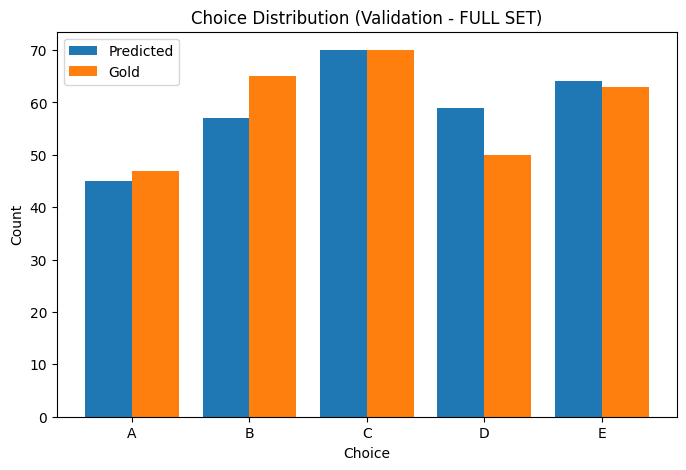

In [15]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

RESULTS_DIR = "/content/drive/MyDrive/Distill_Ensemble/ckpt_student/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

LETTERS = ["A","B","C","D","E"]

def force_letter_from_logits(logits, tok):
    scores = {}
    for c in LETTERS:
        tid = tok.encode(c, add_special_tokens=False)[0]
        scores[c] = logits[tid].item()
    return max(scores, key=scores.get)

pred_letters = []
gold_letters = []

model.eval()
device = next(model.parameters()).device

for _, r in df_val.iterrows():
    prompt = build_prompt(r["soru"], r["secenekler"])
    gold = r["label"]

    enc = tok(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        out = model.generate(
            **enc,
            max_new_tokens=3,
            do_sample=False,
            return_dict_in_generate=True,
            output_scores=True
        )

    gen_text = tok.decode(
        out.sequences[0][enc["input_ids"].shape[1]:],
        skip_special_tokens=True
    ).upper()

    pred = None
    for ch in gen_text:
        if ch in LETTERS:
            pred = ch
            break

    if pred is None:
        last_logits = out.scores[-1][0]
        pred = force_letter_from_logits(last_logits, tok)

    pred_letters.append(pred)
    gold_letters.append(gold)

pred_cnt = Counter(pred_letters)
gold_cnt = Counter(gold_letters)

dist_df = pd.DataFrame({
    "choice": LETTERS,
    "predicted": [pred_cnt[c] for c in LETTERS],
    "gold":      [gold_cnt[c] for c in LETTERS],
})

print(dist_df)
print("TOPLAM VAL:", sum(pred_cnt.values()))

x = np.arange(len(LETTERS))
fig = plt.figure(figsize=(8,5))
plt.bar(x - 0.2, dist_df["predicted"], width=0.4, label="Predicted")
plt.bar(x + 0.2, dist_df["gold"], width=0.4, label="Gold")
plt.xticks(x, LETTERS)
plt.xlabel("Choice")
plt.ylabel("Count")
plt.title("Choice Distribution (Validation - FULL SET)")
plt.legend()

out_path = os.path.join(RESULTS_DIR, "choice_distribution_full.png")
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print("Saved PNG:", out_path)

plt.show()
plt.close(fig)


In [16]:
import os, re, glob
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from collections import Counter

from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

TEST_PATH = "/content/drive/MyDrive/Distill_Ensemble/my_project_test_500.parquet"
OUT_DIR   = "/content/drive/MyDrive/Distill_Ensemble/ckpt_student"
RESULTS_DIR = os.path.join(OUT_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

STUDENT_ID = "Metin/gemma-2b-tr-inst"
MAX_LEN = 384
LETTERS = ["A","B","C","D","E"]
ANS_RE = re.compile(r"[A-E]")

def norm_letter(x):
    if x is None:
        return None
    s = str(x).upper()
    m = ANS_RE.search(s)
    return m.group(0) if m else None

def to_letter_from_gt(gt):
    if gt is None:
        return None
    if isinstance(gt, (int, np.integer)):
        if 0 <= int(gt) <= 4:
            return LETTERS[int(gt)]
        return None
    s = str(gt).strip().upper()
    if s.isdigit():
        k = int(s)
        if 0 <= k <= 4:
            return LETTERS[k]
    return norm_letter(s)

def build_prompt(question, options):
    lines = [f"Soru:\n{question}\n"]
    for i, opt in enumerate(options):
        lines.append(f"{LETTERS[i]}) {opt}")
    lines.append("Cevap:")
    return "\n".join(lines)

def force_letter_from_logits(logits, tok):
    scores = {}
    for c in LETTERS:
        tid = tok.encode(c, add_special_tokens=False)[0]
        scores[c] = logits[tid].item()
    return max(scores, key=scores.get)

ckpts = sorted(
    glob.glob(os.path.join(OUT_DIR, "checkpoint-*")),
    key=lambda p: int(os.path.basename(p).split("-")[-1])
)
CKPT_DIR = ckpts[-1]
print("Using latest checkpoint:", CKPT_DIR)

tok = AutoTokenizer.from_pretrained(CKPT_DIR, use_fast=True)
tok.padding_side = "right"
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

base = AutoModelForCausalLM.from_pretrained(
    STUDENT_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
model = PeftModel.from_pretrained(base, CKPT_DIR)
model.eval()
device = next(model.parameters()).device
print("Model device:", device)


df_test = pd.read_parquet(TEST_PATH).copy()
print("Loaded test rows:", len(df_test))

df_test["secenekler"] = df_test["secenekler"].apply(
    lambda x: x.tolist() if isinstance(x, np.ndarray) else x
)

df_test = df_test[df_test["secenekler"].apply(lambda x: isinstance(x, list) and len(x)==5)].reset_index(drop=True)
print("Test rows (valid 5 options):", len(df_test))

df_test["gold"] = df_test["cevap"].apply(to_letter_from_gt)
df_test = df_test[df_test["gold"].isin(LETTERS)].reset_index(drop=True)
print("Test rows (with valid gold):", len(df_test))

preds = []
raw_gen = []

BATCH = 8
for i in range(0, len(df_test), BATCH):
    batch = df_test.iloc[i:i+BATCH]
    prompts = [build_prompt(r["soru"], r["secenekler"]) for _, r in batch.iterrows()]

    enc = tok(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_LEN
    ).to(device)

    with torch.no_grad():
        out = model.generate(
            **enc,
            max_new_tokens=3,
            do_sample=False,
            return_dict_in_generate=True,
            output_scores=True,
            pad_token_id=tok.eos_token_id
        )

    prompt_len = enc["input_ids"].shape[1]
    seqs = out.sequences

    for b in range(seqs.shape[0]):
        gen_text = tok.decode(seqs[b][prompt_len:], skip_special_tokens=True).upper()
        raw_gen.append(gen_text)

        pred = None
        for ch in gen_text:
            if ch in LETTERS:
                pred = ch
                break

        if pred is None:
            pred = force_letter_from_logits(out.scores[-1][b], tok)

        preds.append(pred)

df_test["pred"] = preds
df_test["raw_gen"] = raw_gen

acc = float((df_test["pred"] == df_test["gold"]).mean())
print("TEST ACC (ground truth):", acc)

cm = pd.crosstab(df_test["gold"], df_test["pred"], rownames=["gold"], colnames=["pred"]).reindex(
    index=LETTERS, columns=LETTERS, fill_value=0
)

pred_cnt = Counter(df_test["pred"].tolist())
gold_cnt = Counter(df_test["gold"].tolist())
dist_df = pd.DataFrame({
    "choice": LETTERS,
    "predicted": [pred_cnt.get(c, 0) for c in LETTERS],
    "gold":      [gold_cnt.get(c, 0) for c in LETTERS],
})

topic_acc_df = (df_test.assign(ok=(df_test["pred"]==df_test["gold"]))
                .groupby("konu")["ok"].agg(["count","mean"])
                .sort_values("mean", ascending=False)
                .reset_index()
                .rename(columns={"mean":"accuracy"}))

pd.DataFrame([{
    "checkpoint": os.path.basename(CKPT_DIR),
    "test_rows": len(df_test),
    "test_acc_ground_truth": acc,
}]).to_csv(os.path.join(RESULTS_DIR, "test_metrics.csv"), index=False)

df_test.to_parquet(os.path.join(RESULTS_DIR, "test_predictions.parquet"), index=False)
cm.to_csv(os.path.join(RESULTS_DIR, "confusion_matrix.csv"))
dist_df.to_csv(os.path.join(RESULTS_DIR, "test_choice_distribution.csv"), index=False)
topic_acc_df.to_csv(os.path.join(RESULTS_DIR, "test_accuracy_by_topic.csv"), index=False)

x = np.arange(len(LETTERS))
plt.figure(figsize=(8,5))
plt.bar(x - 0.2, dist_df["predicted"], width=0.4, label="Predicted")
plt.bar(x + 0.2, dist_df["gold"], width=0.4, label="Gold")
plt.xticks(x, LETTERS)
plt.xlabel("Choice")
plt.ylabel("Count")
plt.title("Test Choice Distribution (Predicted vs Gold)")
plt.legend()
plt.savefig(os.path.join(RESULTS_DIR, "test_choice_distribution.png"), dpi=300, bbox_inches="tight")
plt.close()

plt.figure(figsize=(6,5))
plt.imshow(cm.values, interpolation="nearest")
plt.xticks(np.arange(len(LETTERS)), LETTERS)
plt.yticks(np.arange(len(LETTERS)), LETTERS)
plt.xlabel("Pred")
plt.ylabel("Gold")
plt.title("Confusion Matrix (Test)")
for r in range(len(LETTERS)):
    for c in range(len(LETTERS)):
        plt.text(c, r, int(cm.values[r, c]), ha="center", va="center")
plt.savefig(os.path.join(RESULTS_DIR, "confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.close()

print("\nDONE. Results under:", RESULTS_DIR)


Using latest checkpoint: /content/drive/MyDrive/Distill_Ensemble/ckpt_student/checkpoint-668


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model device: cuda:0
Loaded test rows: 500
Test rows (valid 5 options): 500
Test rows (with valid gold): 500
TEST ACC (ground truth): 0.212

DONE. Results under: /content/drive/MyDrive/Distill_Ensemble/ckpt_student/results


In [ ]:
import re
import random
import torch
import pandas as pd

SEED = 42
N_CHECK = 10
BATCH_SIZE = 8
MAX_NEW_TOKENS = 256
DATA_PATH = "/content/drive/MyDrive/Distill_Ensemble/my_project_train_2000.parquet"

# Teacher-2 decoding ayarlari
DO_SAMPLE = True
TEMPERATURE = 0.7
TOP_P = 0.9
TEACHER2_SEED = 123

random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

df_sub = pd.read_parquet(DATA_PATH)
sample_df = df_sub.sample(n=N_CHECK, random_state=SEED).reset_index(drop=True)

def permute_one_example(options, answer_idx, rng):
    opts = list(options)
    perm = list(range(len(opts)))
    rng.shuffle(perm)
    new_opts = [opts[i] for i in perm]
    new_answer_idx = perm.index(int(answer_idx))
    return new_opts, new_answer_idx, perm

def build_teacher_user_message_strict(question, options):
    letters = ["A", "B", "C", "D", "E"]
    opts_text = "\n".join([f"{letters[i]}) {options[i]}" for i in range(5)])

    msg = (
        "Sen bir test çözme asistanısın. Tek görevin düşünmek ve cevabı vermektir.\n\n"
        "ADIMLAR:\n"
        "1. <think> etiketi içinde soruyu UZATMADAN analiz et.\n"
        "2. </think> etiketini kapat.\n"
        "3. Hemen altına 'CEVAP: X' formatında doğru şıkkı yaz.\n"
        "4. Başka hiçbir açıklama veya özet ekleme.\n\n"
        "ÖRNEK ÇIKTI (Buna Birebir Uy):\n"
        "<think>\n"
        "Soru Kurtuluş Savaşı ile ilgili... Cevap C şıkkı görünüyor.\n"
        "</think>\n"
        "CEVAP: C\n\n"
        "--- SORU ---\n"
        f"Soru:\n{question}\n\n"
        f"Seçenekler:\n{opts_text}\n"
    )
    return msg

ANSWER_RE = re.compile(r"(?:cevap|final cevap)\s*:?\s*([A-E])", flags=re.IGNORECASE)
def parse_letter(text):
    ms = ANSWER_RE.findall(text)
    return ms[-1].upper() if ms else None

eos_id = tokenizer.eos_token_id
eot_id = tokenizer.convert_tokens_to_ids("<end_of_turn>")
terminators = [eos_id] + ([eot_id] if isinstance(eot_id, int) and eot_id not in (eos_id, -1) else [])


# BATCH GENERATE (Teacher-2)
def run_one_batch(batch_rows, rng):
    letters = ["A","B","C","D","E"]

    user_msgs = []
    gt_letters = []
    metas = []

    for _, r in batch_rows.iterrows():
        q = r["soru"]
        opts = r["secenekler"]
        ans = int(r["cevap"])

        opts_p, ans_p, perm = permute_one_example(opts, ans, rng)
        gt_letter = letters[ans_p]

        user_msg = build_teacher_user_message_strict(q, opts_p)
        chat_prompt = tokenizer.apply_chat_template(
            [{"role": "user", "content": user_msg}],
            tokenize=False,
            add_generation_prompt=True
        )

        user_msgs.append(chat_prompt)
        gt_letters.append(gt_letter)
        metas.append({"konu": r["konu"], "perm": perm})

    inputs = tokenizer(
        user_msgs,
        return_tensors="pt",
        padding=True,
        add_special_tokens=False
    ).to(model.device)

    prompt_len_padded = inputs["input_ids"].shape[1]

    # Teacher-2 sampling seed
    torch.manual_seed(TEACHER2_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(TEACHER2_SEED)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            eos_token_id=terminators,
            do_sample=DO_SAMPLE,
            temperature=TEMPERATURE,
            top_p=TOP_P,
            pad_token_id=eos_id
        )

    results = []
    kept = []

    for b in range(outputs.shape[0]):
        gen_ids = outputs[b][prompt_len_padded:]
        text = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()

        pred = parse_letter(text)
        format_ok = pred is not None
        acc_ok = (pred == gt_letters[b]) if format_ok else False

        item = {
            "konu": metas[b]["konu"],
            "perm": metas[b]["perm"],
            "gt": gt_letters[b],
            "pred": pred,
            "format_ok": format_ok,
            "acc_ok": acc_ok,
            "raw_text": text
        }

        results.append(item)
        if format_ok:
            kept.append(item)

    return results, kept

rng = random.Random(SEED)

print("\n=== TEACHER-2 DRY-RUN (BATCH) ===\n")

batch_rows = sample_df.iloc[:BATCH_SIZE]
results, kept = run_one_batch(batch_rows, rng)

ok_format = 0
ok_acc = 0

for i, item in enumerate(results, start=1):
    ok_format += int(item["format_ok"])
    ok_acc += int(item["acc_ok"])

    print("="*90)
    print(f"[{i}] Konu: {item['konu']}")
    print("GT:", item["gt"], "| perm:", item["perm"])
    print("Pred:", item["pred"], "| FormatOK:", item["format_ok"], "| AccOK:", item["acc_ok"])
    print("--- RAW OUTPUT ---")
    print(item["raw_text"])

kept_total = len(kept)
kept_acc = sum(1 for x in kept if x["acc_ok"])

print("\n=== OZET (BATCH TEST) ===")
print(f"Format rate (all) : {ok_format}/{BATCH_SIZE} = {ok_format/BATCH_SIZE:.2f}")
print(f"Accuracy (all)    : {ok_acc}/{BATCH_SIZE} = {ok_acc/BATCH_SIZE:.2f}")

print("\n=== FILTER (STUDENT DATA) ===")
print(f"Kept (format_ok)  : {kept_total}/{BATCH_SIZE} = {kept_total/BATCH_SIZE:.2f}")
print(
    f"Accuracy (kept)   : {kept_acc}/{kept_total} = {kept_acc/kept_total:.2f}"
    if kept_total > 0 else "Accuracy (kept): N/A"
)



=== TEACHER-2 DRY-RUN (BATCH) ===

[1] Konu: GENEL YETENEK DENEMELER
GT: E | perm: [3, 1, 2, 4, 0]
Pred: None | FormatOK: False | AccOK: False
--- RAW OUTPUT ---
<think>
Soru, günümüz iş dünyasında pozitif düşünce, duygusal zekâ ve çalışan refahına verilen önemi vurguluyor. Şirketlerin çalışanları makine gibi görmediği, onları sosyal varlıklar olarak kabul ettiği ve onlara ailelerini de dahil ederek maksimum verim elde etmeye çalıştığı anlatılıyor. Ayrıca, emir komuta zincirinden uzaklaşıp çalışan fikirlerine değer verildiği ve düşüncelerin özgürce paylaşıldığı belirtiliyor.

Soru, bu parçanın başına düşüncenin akışına uygun olarak hangi cümlenin getirilmesi gerektiğini soruyor. Seçenekler arasında en uygun olanı bulmalıyım.

Parçanın içeriği, modern yönetim yaklaşımlarının değişimini ve çalışan odaklılığı vurguluyor. Bu nedenle, başa konulacak cümle bu değişimi veya bu yaklaşımların ortaya çıkış nedenini açıklamalı.

Seçeneklere bakalım:

A) Çalışma hayatının ortaya koyduğu şartlar, 

In [ ]:
import re
import random
import time
import os
import json
import torch
import pandas as pd

SEED = 42
TEACHER2_SEED = 123

N_RUN = 2000
BATCH_SIZE = 8

MAX_NEW_TOKENS = 256
DO_SAMPLE = True
TEMPERATURE = 0.7
TOP_P = 0.9

DATA_PATH = "/content/drive/MyDrive/Distill_Ensemble/my_project_train_2000.parquet"
OUT_PATH  = "/content/drive/MyDrive/Distill_Ensemble/student_labels_t2.parquet"
CKPT_DIR = "/content/drive/MyDrive/Distill_Ensemble/ckpt_teacher2"
SHARD_DIR = os.path.join(CKPT_DIR, "student_labels_shards")
PROGRESS_PATH = os.path.join(CKPT_DIR, "progress.json")

SAVE_EVERY_N_BATCH = 20
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(SHARD_DIR, exist_ok=True)

def to_tuple(x):
    if isinstance(x, list):
        return tuple(to_tuple(i) for i in x)
    return x

def save_json(path, obj):
    tmp = path + ".tmp"
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)
    os.replace(tmp, path)

def load_json(path):
    if not os.path.exists(path):
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

model.eval()
torch.set_grad_enabled(False)

df_sub = pd.read_parquet(DATA_PATH)
df_sub = df_sub.reset_index().rename(columns={"index": "orig_idx"})

df_run = df_sub.sample(n=N_RUN, random_state=SEED).reset_index(drop=True)
total = len(df_run)

def permute_one_example(options, answer_idx, rng):
    opts = list(options)
    perm = list(range(len(opts)))
    rng.shuffle(perm)
    new_opts = [opts[i] for i in perm]
    new_answer_idx = perm.index(int(answer_idx))
    return new_opts, new_answer_idx, perm

def build_teacher_user_message_strict(question, options):
    letters = ["A", "B", "C", "D", "E"]
    opts_text = "\n".join([f"{letters[i]}) {options[i]}" for i in range(5)])
    msg = (
        "Sen bir test çözme asistanısın. Tek görevin düşünmek ve cevabı vermektir.\n\n"
        "ADIMLAR:\n"
        "1. <think> etiketi içinde soruyu UZATMADAN analiz et.\n"
        "2. </think> etiketini kapat.\n"
        "3. Hemen altına 'CEVAP: X' formatında doğru şıkkı yaz.\n"
        "4. Başka hiçbir açıklama veya özet ekleme.\n\n"
        "ÖRNEK ÇIKTI (Buna Birebir Uy):\n"
        "<think>\n"
        "Soru Kurtuluş Savaşı ile ilgili... Cevap C şıkkı görünüyor.\n"
        "</think>\n"
        "CEVAP: C\n\n"
        "--- SORU ---\n"
        f"Soru:\n{question}\n\n"
        f"Seçenekler:\n{opts_text}\n"
    )
    return msg

ANSWER_RE = re.compile(r"(?:cevap|final cevap)\s*:?\s*([A-E])", flags=re.IGNORECASE)
def parse_letter(text):
    ms = ANSWER_RE.findall(text)
    return ms[-1].upper() if ms else None

eos_id = tokenizer.eos_token_id
eot_id = tokenizer.convert_tokens_to_ids("<end_of_turn>")
terminators = [eos_id] + ([eot_id] if isinstance(eot_id, int) and eot_id not in (eos_id, -1) else [])

def run_one_batch(batch_rows, rng):
    letters = ["A","B","C","D","E"]

    user_msgs = []
    gt_letters = []
    metas = []

    for _, r in batch_rows.iterrows():
        q = r["soru"]
        opts = r["secenekler"]
        ans = int(r["cevap"])

        opts_p, ans_p, perm = permute_one_example(opts, ans, rng)
        gt_letter = letters[ans_p]

        user_msg = build_teacher_user_message_strict(q, opts_p)
        chat_prompt = tokenizer.apply_chat_template(
            [{"role": "user", "content": user_msg}],
            tokenize=False,
            add_generation_prompt=True
        )

        user_msgs.append(chat_prompt)
        gt_letters.append(gt_letter)
        metas.append({
            "orig_idx": int(r["orig_idx"]),
            "konu": r.get("konu", None),
            "perm": perm,
            "secenekler_perm": opts_p,
            "soru": q
        })

    inputs = tokenizer(
        user_msgs,
        return_tensors="pt",
        padding=True,
        add_special_tokens=False
    ).to(model.device)

    prompt_len_padded = inputs["input_ids"].shape[1]

    torch.manual_seed(TEACHER2_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(TEACHER2_SEED)

    outputs = model.generate(
        **inputs,
        max_new_tokens=MAX_NEW_TOKENS,
        eos_token_id=terminators,
        do_sample=DO_SAMPLE,
        temperature=TEMPERATURE,
        top_p=TOP_P,
        pad_token_id=eos_id
    )

    results, kept = [], []
    for b in range(outputs.shape[0]):
        gen_ids = outputs[b][prompt_len_padded:]
        text = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()

        pred = parse_letter(text)
        format_ok = pred is not None
        acc_ok = (pred == gt_letters[b]) if format_ok else False

        item = {
            "orig_idx": metas[b]["orig_idx"],
            "konu": metas[b]["konu"],
            "perm": metas[b]["perm"],
            "gt": gt_letters[b],
            "pred": pred,
            "format_ok": format_ok,
            "acc_ok": acc_ok,
            "raw_text": text,
            "secenekler_perm": metas[b]["secenekler_perm"],
            "soru": metas[b]["soru"]
        }
        results.append(item)
        if format_ok:
            kept.append(item)

    return results, kept

def print_detailed_batch(results, title):
    print(f"\n=== {title} ===\n")
    for i, item in enumerate(results, start=1):
        print("="*90)
        print(f"[{i}] orig_idx={item['orig_idx']} | Konu: {item['konu']}")
        print("GT:", item["gt"], "| perm:", item["perm"])
        print("Pred:", item["pred"], "| FormatOK:", item["format_ok"], "| AccOK:", item["acc_ok"])
        print("--- RAW OUTPUT ---")
        print(item["raw_text"])

def summarize_counts(ok_format, ok_acc, kept_total, kept_acc, done):
    format_rate = ok_format / done
    acc_all = ok_acc / done
    kept_rate = kept_total / done
    acc_kept = (kept_acc / kept_total) if kept_total > 0 else None
    return format_rate, acc_all, kept_rate, acc_kept

ckpt = load_json(PROGRESS_PATH)

if ckpt is None:
    rng = random.Random(SEED)
    start_pos = 0
    ok_format = 0
    ok_acc = 0
    kept_total = 0
    kept_acc = 0
    print("\n[START] Teacher-2 fresh run. No checkpoint.\n")
else:
    rng = random.Random(SEED)
    rng.setstate(to_tuple(ckpt["rng_state"]))

    start_pos_ckpt = int(ckpt["next_pos"])
    shard_id_ckpt  = int(ckpt.get("shard_id_next", start_pos_ckpt // BATCH_SIZE))

    ok_format = int(ckpt["ok_format"])
    ok_acc    = int(ckpt["ok_acc"])
    kept_total = int(ckpt["kept_total"])
    kept_acc   = int(ckpt["kept_acc"])

    existing_parts = sorted([f for f in os.listdir(SHARD_DIR) if f.endswith(".parquet")])
    shard_id_disk  = len(existing_parts)
    start_pos_disk = shard_id_disk * BATCH_SIZE

    start_pos = max(start_pos_ckpt, start_pos_disk)
    shard_id  = max(shard_id_ckpt, shard_id_disk)

    print(f"\n[RESUME SAFE T2] ckpt_pos={start_pos_ckpt}, disk_pos={start_pos_disk} -> using pos={start_pos}, shard_id={shard_id}\n")

if start_pos == 0:
    print("\n=== FIRST 8 QUESTIONS (ID CHECK) ===")
    for i in range(BATCH_SIZE):
        r = df_run.iloc[i]
        preview = str(r["soru"])[:70].replace("\n", " ")
        print(f"{i+1}. orig_idx={int(r['orig_idx'])} | konu={r.get('konu', None)} | soru_preview={preview}...")

    first_batch = df_run.iloc[:BATCH_SIZE]
    t0 = time.time()
    results0, kept0 = run_one_batch(first_batch, rng)
    print(f"\n(first batch time) {time.time()-t0:.1f} sec")

    print_detailed_batch(results0, "SANITY CHECK (FIRST BATCH - DETAILED)")

    ok_format += sum(1 for x in results0 if x["format_ok"])
    ok_acc    += sum(1 for x in results0 if x["acc_ok"])
    kept_total += len(kept0)
    kept_acc   += sum(1 for x in kept0 if x["acc_ok"])

    shard_path = os.path.join(SHARD_DIR, f"part_{0:04d}.parquet")
    shard_rows = []
    for x in kept0:
        shard_rows.append({
            "orig_idx": x["orig_idx"],
            "konu": x["konu"],
            "soru": x["soru"],
            "secenekler": x["secenekler_perm"],
            "label": x["pred"]
        })
    pd.DataFrame(shard_rows).to_parquet(shard_path, index=False)
    print("Saved shard:", shard_path)

    next_pos = BATCH_SIZE
    save_json(PROGRESS_PATH, {
        "next_pos": next_pos,
        "rng_state": list(rng.getstate()),
        "ok_format": ok_format,
        "ok_acc": ok_acc,
        "kept_total": kept_total,
        "kept_acc": kept_acc,
        "shard_id_next": 1
    })

    start_pos = next_pos
    shard_id = 1
else:
    shard_id = int(ckpt.get("shard_id_next", start_pos // BATCH_SIZE))

print("\n=== FULL RUN (CONTINUE) ===\n")

for start in range(start_pos, total, BATCH_SIZE):
    end = min(start + BATCH_SIZE, total)
    batch_rows = df_run.iloc[start:end]

    bt0 = time.time()
    results, kept = run_one_batch(batch_rows, rng)
    bt = time.time() - bt0

    ok_format += sum(1 for x in results if x["format_ok"])
    ok_acc    += sum(1 for x in results if x["acc_ok"])
    kept_total += len(kept)
    kept_acc   += sum(1 for x in kept if x["acc_ok"])

    shard_path = os.path.join(SHARD_DIR, f"part_{shard_id:04d}.parquet")
    shard_rows = []
    for x in kept:
        shard_rows.append({
            "orig_idx": x["orig_idx"],
            "konu": x["konu"],
            "soru": x["soru"],
            "secenekler": x["secenekler_perm"],
            "label": x["pred"]
        })
    pd.DataFrame(shard_rows).to_parquet(shard_path, index=False)
    shard_id += 1

    done = end
    if (start // BATCH_SIZE) % 20 == 0:
        format_rate, acc_all, kept_rate, acc_kept = summarize_counts(ok_format, ok_acc, kept_total, kept_acc, done)
        print(f"Processed {done}/{total} | batch_time={bt:.1f}s | kept_total={kept_total} | format_rate={format_rate:.2f} | acc_all={acc_all:.2f}")

    if ((start // BATCH_SIZE) % SAVE_EVERY_N_BATCH == 0) or (done == total):
        save_json(PROGRESS_PATH, {
            "next_pos": done,
            "rng_state": list(rng.getstate()),
            "ok_format": ok_format,
            "ok_acc": ok_acc,
            "kept_total": kept_total,
            "kept_acc": kept_acc,
            "shard_id_next": shard_id
        })

format_rate, acc_all, kept_rate, acc_kept = summarize_counts(ok_format, ok_acc, kept_total, kept_acc, total)

print("\n=== FINAL SUMMARY (ALL) ===")
print(f"Format rate (all) : {ok_format}/{total} = {format_rate:.2f}")
print(f"Accuracy (all)    : {ok_acc}/{total} = {acc_all:.2f}")

print("\n=== FINAL SUMMARY (STUDENT / KEPT) ===")
print(f"Kept (format_ok)  : {kept_total}/{total} = {kept_rate:.2f}")
print(f"Accuracy (kept)   : {kept_acc}/{kept_total} = {acc_kept:.2f}" if kept_total > 0 else "Accuracy (kept): N/A")

print("\nMerging shards to single parquet...")

parts = sorted([os.path.join(SHARD_DIR, f) for f in os.listdir(SHARD_DIR) if f.endswith(".parquet")])
dfs = [pd.read_parquet(p) for p in parts]
student_df = pd.concat(dfs, ignore_index=True) if len(dfs) else pd.DataFrame(columns=["orig_idx","konu","soru","secenekler","label"])

student_df.to_parquet(OUT_PATH, index=False)
print("Saved merged student labels:", OUT_PATH)
print("Total student rows:", len(student_df))
print("Checkpoint file:", PROGRESS_PATH)



[START] Teacher-2 fresh run. No checkpoint.


=== FIRST 8 QUESTIONS (ID CHECK) ===
1. orig_idx=1860 | konu=GENEL YETENEK DENEMELER | soru_preview=— Bundan birkaç yıl önce, firmalarda pozitif düşünce, duygusal zekâ, s...
2. orig_idx=353 | konu=MATEMATİK KONU SORULARI | soru_preview=Bir okuldaki bayan ögretmenlerin sayısı tüm ögretmenlerin sayısının % ...
3. orig_idx=1333 | konu=BİYOLOJİ KONU SORULARI | soru_preview=Glikoliz tepkimeleri sırasında, aşağıdaki olaylardan hangisi gerçekleş...
4. orig_idx=905 | konu=GENEL YETENEK DENEMELER | soru_preview=Aşağıdaki cümlelerden hangisinde öznellik ağır basmaktadır?...
5. orig_idx=1289 | konu=Vergi uygulamaları | soru_preview=Aşağıdakilerden hangisinde organizasyon sürecinin temel aşamaları sıra...
 kestigi noktaları ...
7. orig_idx=938 | konu=GENEL YETENEK DENEMELER | soru_preview=x + y = 8 doğrusu üzerinde bulunan ve A (8,8) noktasına en yakın olan ...
8. orig_idx=1731 | konu=Vergi uygulamaları | soru_preview=I. Kadınların sünnet edilmesi - K

In [ ]:
import random
import pandas as pd

IN_PATH  = "/content/drive/MyDrive/Distill_Ensemble/student_labels_t2.parquet"
OUT_PATH = "/content/drive/MyDrive/Distill_Ensemble/student_train_perm_t2.parquet"

SEED = 42
K_PERM = 3
LETTERS = ["A","B","C","D","E"]

rng = random.Random(SEED)
df = pd.read_parquet(IN_PATH)

def permute_keep_correct(options, correct_text, rng):
    opts = list(options)
    rng.shuffle(opts)
    new_idx = opts.index(correct_text)
    return opts, LETTERS[new_idx]

rows = []
for _, r in df.iterrows():
    options = list(r["secenekler"])
    label = str(r["label"]).strip().upper()
    if label not in LETTERS:
        continue

    correct_text = options[LETTERS.index(label)]

    rows.append({"soru": r["soru"], "secenekler": options, "label": label})

    for _ in range(K_PERM):
        new_opts, new_label = permute_keep_correct(options, correct_text, rng)
        rows.append({"soru": r["soru"], "secenekler": new_opts, "label": new_label})

df_aug = pd.DataFrame(rows).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
df_aug.to_parquet(OUT_PATH, index=False)

print("Saved:", OUT_PATH)
print("Original rows:", len(df), "| Augmented rows:", len(df_aug), "| factor:", round(len(df_aug)/len(df), 2))


Saved: /content/drive/MyDrive/Distill_Ensemble/student_train_perm_t2.parquet
Original rows: 260 | Augmented rows: 1040 | factor: 4.0


In [ ]:
import os
import re
import gc
import numpy as np
import torch
import pandas as pd

from dataclasses import dataclass
from typing import List, Dict, Any

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
)
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
)

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
torch.set_grad_enabled(True)

STUDENT_ID = "Metin/gemma-2b-tr-inst"
DATA_PATH  = "/content/drive/MyDrive/Distill_Ensemble/student_train_perm_t2.parquet"
OUT_DIR    = "/content/drive/MyDrive/Distill_Ensemble/ckpt_student2"

SEED = 42
MAX_LEN = 384

LETTERS = ["A", "B", "C", "D", "E"]
ANS_RE = re.compile(r"[A-E]")

torch.manual_seed(SEED)
np.random.seed(SEED)

def build_prompt(question, options):
    lines = [f"Soru:\n{question}\n"]
    for i, opt in enumerate(options):
        lines.append(f"{LETTERS[i]}) {opt}")
    lines.append("Cevap:")
    return "\n".join(lines)

def norm_letter(x):
    if x is None:
        return None
    x = str(x).upper()
    m = ANS_RE.search(x)
    return m.group(0) if m else None

def clear_vram():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

df = pd.read_parquet(DATA_PATH)

df["label"] = df["label"].astype(str).str.strip().str.upper()
df = df[df["label"].isin(LETTERS)].reset_index(drop=True)

df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

n_val = max(50, int(0.1 * len(df)))
df_val = df.iloc[:n_val].copy().reset_index(drop=True)
df_tr  = df.iloc[n_val:].copy().reset_index(drop=True)

print("Train rows:", len(df_tr), "| Val rows:", len(df_val))

tr_ds = Dataset.from_pandas(df_tr)
va_ds = Dataset.from_pandas(df_val)

bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)

tok = AutoTokenizer.from_pretrained(STUDENT_ID, use_fast=True)
tok.padding_side = "right"
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

base = AutoModelForCausalLM.from_pretrained(
    STUDENT_ID,
    device_map="auto",
    quantization_config=bnb,
)

base = prepare_model_for_kbit_training(base)

lora = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)

model = get_peft_model(base, lora)
model.print_trainable_parameters()

def tokenize_fn(ex):
    prompt = build_prompt(ex["soru"], ex["secenekler"])
    target = norm_letter(ex["label"])
    if target is None:
        target = "A"

    full = prompt + " " + target

    enc_full = tok(full, truncation=True, max_length=MAX_LEN)
    enc_prompt = tok(prompt, truncation=True, max_length=MAX_LEN)
    prompt_len = len(enc_prompt["input_ids"])

    labels = [-100] * len(enc_full["input_ids"])
    for i in range(prompt_len, len(labels)):
        labels[i] = enc_full["input_ids"][i]

    enc_full["labels"] = labels
    return enc_full

tr_tok = tr_ds.map(tokenize_fn, remove_columns=tr_ds.column_names)
va_tok = va_ds.map(tokenize_fn, remove_columns=va_ds.column_names)

@dataclass
class CausalLMPadCollator:
    tokenizer: Any
    label_pad_token_id: int = -100

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        batch_inputs = self.tokenizer.pad(
            [{"input_ids": f["input_ids"], "attention_mask": f.get("attention_mask", None)} for f in features],
            padding=True,
            return_tensors="pt"
        )
        input_ids = batch_inputs["input_ids"]
        attention_mask = batch_inputs["attention_mask"]

        max_len = input_ids.shape[1]
        padded_labels = torch.full((len(features), max_len), self.label_pad_token_id, dtype=torch.long)

        for i, f in enumerate(features):
            lab = torch.tensor(f["labels"], dtype=torch.long)
            padded_labels[i, :lab.shape[0]] = lab

        return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": padded_labels}

data_collator = CausalLMPadCollator(tokenizer=tok, label_pad_token_id=-100)

args = TrainingArguments(
    output_dir=OUT_DIR,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    num_train_epochs=8,
    learning_rate=2e-4,
    warmup_ratio=0.03,
    logging_steps=20,
    eval_strategy="no",
    save_strategy="steps",
    save_steps=100,
    save_total_limit=2,
    bf16=True,
    fp16=False,
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tr_tok,
    data_collator=data_collator,
)

clear_vram()
trainer.train()
print("Training bitti. (Eval kapaliydi; accuracy'yi simdi ayri olcecegiz.)")

def eval_accuracy_generate(model, tok, df_val, bs=8, max_items=None):
    model.eval()
    letters = ["A", "B", "C", "D", "E"]
    ok, tot = 0, 0

    if max_items is None:
        max_items = len(df_val)

    clear_vram()

    for i in range(0, min(len(df_val), max_items), bs):
        batch = df_val.iloc[i:i+bs]
        prompts = []
        gts = []

        for _, r in batch.iterrows():
            q = r["soru"]
            opts = r["secenekler"]
            gt = str(r["label"]).strip().upper()
            gts.append(gt)

            lines = [f"Soru:\n{q}\n"]
            for j, opt in enumerate(opts):
                lines.append(f"{letters[j]}) {opt}")
            lines.append("Cevap:")
            prompts.append("\n".join(lines))

        enc = tok(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_LEN
        ).to(model.device)

        with torch.no_grad():
            out = model.generate(
                **enc,
                max_new_tokens=1,
                do_sample=False,
                pad_token_id=tok.eos_token_id
            )

        gen_ids = out[:, enc["input_ids"].shape[1]:]
        preds = [tok.decode(x, skip_special_tokens=True).strip().upper() for x in gen_ids]

        for p, g in zip(preds, gts):
            p = (p[:1] if p else "")
            if p in letters and g in letters:
                tot += 1
                ok += int(p == g)

    return ok / tot if tot else 0.0

acc = eval_accuracy_generate(model, tok, df_val, bs=8)
print("VAL ACC (generate, teacher-2 label'a gore):", acc)


Train rows: 936 | Val rows: 104


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

trainable params: 19,611,648 || all params: 2,525,784,064 || trainable%: 0.7765


Map:   0%|          | 0/936 [00:00<?, ? examples/s]

Map:   0%|          | 0/104 [00:00<?, ? examples/s]

You're using a GemmaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
20,1.701400
40,1.674000
60,1.684100
80,1.627200
100,1.638500
120,1.589700
140,1.557200
160,1.584000
180,1.530300
200,1.345100


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

Training bitti. (Eval kapaliydi; accuracy'yi simdi ayri olcecegiz.)
VAL ACC (generate, teacher-2 label'a gore): 0.6111111111111112


In [ ]:
import os, json, glob
import pandas as pd
import matplotlib.pyplot as plt

OUT_DIR = "/content/drive/MyDrive/Distill_Ensemble/ckpt_student2"
VAL_ACC = 0.6111111111111112

RESULTS_DIR = os.path.join(OUT_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

candidates = []
candidates += glob.glob(os.path.join(OUT_DIR, "trainer_state.json"))
candidates += glob.glob(os.path.join(OUT_DIR, "checkpoint-*", "trainer_state.json"))

if not candidates:
    raise FileNotFoundError("trainer_state.json bulunamadi. OUT_DIR veya checkpoint-* icinde olmali.")

state_path = max(candidates, key=os.path.getmtime)
print("Using trainer_state:", state_path)

with open(state_path, "r", encoding="utf-8") as f:
    state = json.load(f)

log_history = state.get("log_history", [])
if not log_history:
    raise ValueError("trainer_state.json icinde log_history bos. logging_steps ayarin kontrol et.")


df = pd.DataFrame(log_history)
loss_df = df[df["loss"].notna()].copy() if "loss" in df.columns else pd.DataFrame()

raw_path = os.path.join(RESULTS_DIR, "train_log_history.csv")
df.to_csv(raw_path, index=False)
print("Saved:", raw_path)

last_step = int(loss_df["step"].max()) if (not loss_df.empty and "step" in loss_df.columns) else None
last_loss = float(loss_df.sort_values("step")["loss"].iloc[-1]) if not loss_df.empty else None
min_loss  = float(loss_df["loss"].min()) if not loss_df.empty else None

summary = pd.DataFrame([{
    "val_acc_generate_teacher": VAL_ACC,
    "last_logged_step": last_step,
    "last_training_loss": last_loss,
    "min_training_loss": min_loss,
    "trainer_state_path": state_path
}])

summary_path = os.path.join(RESULTS_DIR, "summary.csv")
summary.to_csv(summary_path, index=False)
print("Saved:", summary_path)

if not loss_df.empty and "step" in loss_df.columns:
    loss_df = loss_df.sort_values("step")

    plt.figure()
    plt.plot(loss_df["step"], loss_df["loss"])
    plt.xlabel("Step")
    plt.ylabel("Training Loss")
    plt.title("Training Loss vs Step")

    plot_path = os.path.join(RESULTS_DIR, "training_loss_curve.png")
    plt.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.close()
    print("Saved:", plot_path)
else:
    print("Uyari: loss_df bos veya step yok. Grafik uretilmedi.")

report_md = os.path.join(RESULTS_DIR, "report.md")
with open(report_md, "w", encoding="utf-8") as f:
    f.write("# Student Training Results\n\n")
    f.write(f"- Val ACC (generate, teacher label'a gore): **{VAL_ACC:.4f}**\n")
    if last_step is not None:
        f.write(f"- Last logged step: **{last_step}**\n")
    if last_loss is not None:
        f.write(f"- Last training loss: **{last_loss:.4f}**\n")
    if min_loss is not None:
        f.write(f"- Min training loss: **{min_loss:.4f}**\n")
    f.write(f"\nFiles saved under: `{RESULTS_DIR}`\n")
    f.write("\n- train_log_history.csv\n- summary.csv\n- training_loss_curve.png\n- report.md\n")

print("Saved:", report_md)
print("\nDONE. Results folder:", RESULTS_DIR)


Using trainer_state: /content/drive/MyDrive/Distill_Ensemble/ckpt_student2/checkpoint-472/trainer_state.json
Saved: /content/drive/MyDrive/Distill_Ensemble/ckpt_student2/results/train_log_history.csv
Saved: /content/drive/MyDrive/Distill_Ensemble/ckpt_student2/results/summary.csv
Saved: /content/drive/MyDrive/Distill_Ensemble/ckpt_student2/results/training_loss_curve.png
Saved: /content/drive/MyDrive/Distill_Ensemble/ckpt_student2/results/report.md

DONE. Results folder: /content/drive/MyDrive/Distill_Ensemble/ckpt_student2/results


In [ ]:
import os, re, glob, json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from collections import Counter

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

OUT_DIR     = "/content/drive/MyDrive/Distill_Ensemble/ckpt_student2"
DATA_PATH   = "/content/drive/MyDrive/Distill_Ensemble/student_train_perm_t2.parquet"
RESULTS_DIR = os.path.join(OUT_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

SEED = 42
MAX_LEN = 384
STUDENT_ID = "Metin/gemma-2b-tr-inst"

LETTERS = ["A","B","C","D","E"]
ANS_RE = re.compile(r"[A-E]")

def norm_letter(x):
    if x is None:
        return None
    x = str(x).upper()
    m = ANS_RE.search(x)
    return m.group(0) if m else None

def build_prompt(question, options):
    lines = [f"Soru:\n{question}\n"]
    for i, opt in enumerate(options):
        lines.append(f"{LETTERS[i]}) {opt}")
    lines.append("Cevap:")
    return "\n".join(lines)

ckpts = sorted(
    glob.glob(os.path.join(OUT_DIR, "checkpoint-*")),
    key=lambda p: int(os.path.basename(p).split("-")[-1])
)

if not ckpts:
    raise FileNotFoundError("OUT_DIR altinda checkpoint-* bulunamadi. (Student-2 OUT_DIR dogru mu?)")

CKPT_DIR = ckpts[-1]
print("Using latest checkpoint:", CKPT_DIR)

state_path = os.path.join(CKPT_DIR, "trainer_state.json")
if not os.path.exists(state_path):
    raise FileNotFoundError(f"trainer_state.json bulunamadi: {state_path}")

with open(state_path, "r", encoding="utf-8") as f:
    state = json.load(f)

df_logs = pd.DataFrame(state.get("log_history", []))
log_csv = os.path.join(RESULTS_DIR, "train_log_history.csv")
df_logs.to_csv(log_csv, index=False)
print("Saved:", log_csv)

if "loss" in df_logs.columns and "step" in df_logs.columns:
    loss_df = df_logs[df_logs["loss"].notna()].sort_values("step")
    if len(loss_df):
        fig = plt.figure()
        plt.plot(loss_df["step"], loss_df["loss"])
        plt.xlabel("Step")
        plt.ylabel("Training Loss")
        plt.title("Training Loss vs Step (Student-2)")
        loss_plot = os.path.join(RESULTS_DIR, "training_loss_curve.png")
        fig.savefig(loss_plot, dpi=200, bbox_inches="tight")
        plt.close(fig)
        print("Saved:", loss_plot)

acc_cols = [c for c in df_logs.columns if "accuracy" in c.lower()]
if acc_cols and "step" in df_logs.columns:
    col = acc_cols[0]
    acc_df = df_logs[df_logs[col].notna()].sort_values("step")
    if len(acc_df):
        fig = plt.figure()
        plt.plot(acc_df["step"], acc_df[col])
        plt.xlabel("Step")
        plt.ylabel(col)
        plt.title(f"{col} vs Step (Student-2)")
        acc_plot = os.path.join(RESULTS_DIR, "accuracy_curve.png")
        fig.savefig(acc_plot, dpi=200, bbox_inches="tight")
        plt.close(fig)
        print("Saved:", acc_plot)
else:
    print("Not: trainer loglarinda accuracy yok (eval kapali oldugu icin normal).")


df = pd.read_parquet(DATA_PATH)
df["label"] = df["label"].astype(str).str.strip().str.upper()
df = df[df["label"].isin(LETTERS)].reset_index(drop=True)
df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

n_val = max(50, int(0.1 * len(df)))
df_val = df.iloc[:n_val].copy().reset_index(drop=True)
df_tr  = df.iloc[n_val:].copy().reset_index(drop=True)

print("Train rows:", len(df_tr), "| Val rows:", len(df_val))

tok = AutoTokenizer.from_pretrained(CKPT_DIR, use_fast=True)
tok.padding_side = "right"
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

base = AutoModelForCausalLM.from_pretrained(
    STUDENT_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

model = PeftModel.from_pretrained(base, CKPT_DIR)
model.eval()

device = next(model.parameters()).device
print("Model device:", device)

def eval_accuracy_and_dist(model, tok, df_val, bs=8):
    ok = 0
    tot = 0
    pred_letters = []
    gold_letters = []

    for i in range(0, len(df_val), bs):
        batch = df_val.iloc[i:i+bs]

        prompts = []
        gts = []
        for _, r in batch.iterrows():
            prompts.append(build_prompt(r["soru"], r["secenekler"]))
            gts.append(r["label"])

        enc = tok(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_LEN
        ).to(device)

        with torch.no_grad():
            out = model.generate(
                **enc,
                max_new_tokens=1,
                do_sample=False,
                pad_token_id=tok.eos_token_id
            )

        gen_ids = out[:, enc["input_ids"].shape[1]:]
        preds = [tok.decode(x, skip_special_tokens=True).strip().upper() for x in gen_ids]

        for ptxt, g in zip(preds, gts):
            p = norm_letter(ptxt[:1] if ptxt else None)
            if p in LETTERS and g in LETTERS:
                pred_letters.append(p)
                gold_letters.append(g)
                tot += 1
                ok += int(p == g)

    acc = ok / tot if tot else 0.0
    return acc, Counter(pred_letters), Counter(gold_letters)

val_acc, pred_cnt, gold_cnt = eval_accuracy_and_dist(model, tok, df_val, bs=8)
print("VAL ACC (generate, teacher-2 label'a gore):", val_acc)

metrics_df = pd.DataFrame([{
    "checkpoint": os.path.basename(CKPT_DIR),
    "val_acc_generate_teacher2": val_acc,
    "val_rows_used": len(df_val)
}])
metrics_path = os.path.join(RESULTS_DIR, "val_metrics.csv")
metrics_df.to_csv(metrics_path, index=False)
print("Saved:", metrics_path)

dist_df = pd.DataFrame({
    "choice": LETTERS,
    "predicted": [pred_cnt[c] for c in LETTERS],
    "gold":      [gold_cnt[c] for c in LETTERS],
})
dist_csv = os.path.join(RESULTS_DIR, "choice_distribution_val.csv")
dist_df.to_csv(dist_csv, index=False)
print("Saved:", dist_csv)

x = np.arange(len(LETTERS))
fig = plt.figure()
plt.bar(x - 0.2, dist_df["predicted"], width=0.4, label="Predicted")
plt.bar(x + 0.2, dist_df["gold"], width=0.4, label="Gold")
plt.xticks(x, LETTERS)
plt.xlabel("Choice")
plt.ylabel("Count")
plt.title("Choice Distribution (Validation - Student-2)")
plt.legend()

dist_png = os.path.join(RESULTS_DIR, "choice_distribution_val.png")
fig.savefig(dist_png, dpi=250, bbox_inches="tight")
plt.close(fig)
print("Saved:", dist_png)

print("\nDONE. Results under:", RESULTS_DIR)


Using latest checkpoint: /content/drive/MyDrive/Distill_Ensemble/ckpt_student2/checkpoint-472
Saved: /content/drive/MyDrive/Distill_Ensemble/ckpt_student2/results/train_log_history.csv
Saved: /content/drive/MyDrive/Distill_Ensemble/ckpt_student2/results/training_loss_curve.png
Not: trainer loglarinda accuracy yok (eval kapali oldugu icin normal).
Train rows: 936 | Val rows: 104


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model device: cuda:0
VAL ACC (generate, teacher-2 label'a gore): 0.27586206896551724
Saved: /content/drive/MyDrive/Distill_Ensemble/ckpt_student2/results/val_metrics.csv
Saved: /content/drive/MyDrive/Distill_Ensemble/ckpt_student2/results/choice_distribution_val.csv
Saved: /content/drive/MyDrive/Distill_Ensemble/ckpt_student2/results/choice_distribution_val.png

DONE. Results under: /content/drive/MyDrive/Distill_Ensemble/ckpt_student2/results


  choice  predicted  gold
0      A         15    19
1      B         16    19
2      C         38    32
3      D         16    16
4      E         19    18
TOPLAM VAL: 104
Saved CSV: /content/drive/MyDrive/Distill_Ensemble/ckpt_student2/results/choice_distribution_full.csv
Saved PNG: /content/drive/MyDrive/Distill_Ensemble/ckpt_student2/results/choice_distribution_full.png


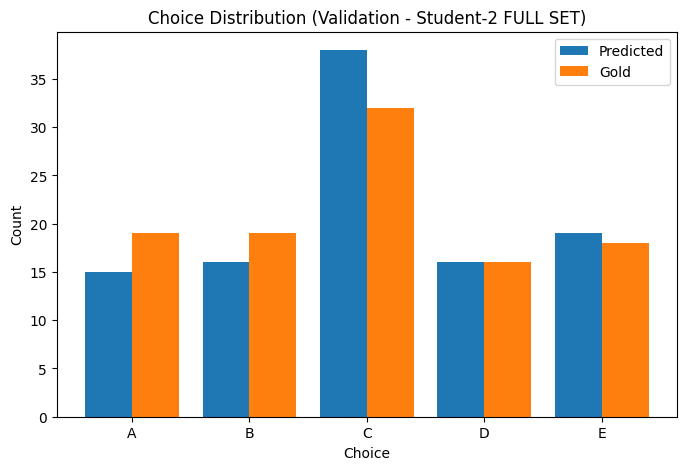

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

RESULTS_DIR = "/content/drive/MyDrive/Distill_Ensemble/ckpt_student2/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

LETTERS = ["A","B","C","D","E"]

def force_letter_from_logits(logits, tok):
    """Son token logits'inden A-E arasinda zorla sec"""
    scores = {}
    for c in LETTERS:
        ids = tok.encode(c, add_special_tokens=False)
        tid = ids[0]
        scores[c] = float(logits[tid].item())
    return max(scores, key=scores.get)

pred_letters = []
gold_letters = []

model.eval()
device = next(model.parameters()).device


for _, r in df_val.iterrows():
    prompt = build_prompt(r["soru"], r["secenekler"])
    gold = str(r["label"]).strip().upper()

    enc = tok(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        out = model.generate(
            **enc,
            max_new_tokens=3,
            do_sample=False,
            return_dict_in_generate=True,
            output_scores=True,
            pad_token_id=tok.eos_token_id
        )

    gen_text = tok.decode(
        out.sequences[0][enc["input_ids"].shape[1]:],
        skip_special_tokens=True
    ).upper()

    pred = None
    for ch in gen_text:
        if ch in LETTERS:
            pred = ch
            break

    if pred is None:
        last_logits = out.scores[-1][0]
        pred = force_letter_from_logits(last_logits, tok)

    pred_letters.append(pred)
    gold_letters.append(gold)

pred_cnt = Counter(pred_letters)
gold_cnt = Counter(gold_letters)

dist_df = pd.DataFrame({
    "choice": LETTERS,
    "predicted": [pred_cnt[c] for c in LETTERS],
    "gold":      [gold_cnt[c] for c in LETTERS],
})

print(dist_df)
print("TOPLAM VAL:", sum(pred_cnt.values()))

csv_path = os.path.join(RESULTS_DIR, "choice_distribution_full.csv")
dist_df.to_csv(csv_path, index=False)
print("Saved CSV:", csv_path)

x = np.arange(len(LETTERS))
fig = plt.figure(figsize=(8,5))
plt.bar(x - 0.2, dist_df["predicted"], width=0.4, label="Predicted")
plt.bar(x + 0.2, dist_df["gold"], width=0.4, label="Gold")
plt.xticks(x, LETTERS)
plt.xlabel("Choice")
plt.ylabel("Count")
plt.title("Choice Distribution (Validation - Student-2 FULL SET)")
plt.legend()

out_path = os.path.join(RESULTS_DIR, "choice_distribution_full.png")
fig.savefig(out_path, dpi=300, bbox_inches="tight")
print("Saved PNG:", out_path)

plt.show()
plt.close(fig)


In [ ]:
import os, re, glob
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from collections import Counter

from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

TEST_PATH = "/content/drive/MyDrive/Distill_Ensemble/my_project_test_500.parquet"
OUT_DIR   = "/content/drive/MyDrive/Distill_Ensemble/ckpt_student2"
RESULTS_DIR = os.path.join(OUT_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

STUDENT_ID = "Metin/gemma-2b-tr-inst"
MAX_LEN = 384

LETTERS = ["A","B","C","D","E"]
ANS_RE = re.compile(r"[A-E]")

def norm_letter(x):
    if x is None:
        return None
    s = str(x).upper()
    m = ANS_RE.search(s)
    return m.group(0) if m else None

def to_letter_from_gt(gt):
    if gt is None:
        return None
    if isinstance(gt, (int, np.integer)):
        if 0 <= int(gt) <= 4:
            return LETTERS[int(gt)]
        return None
    s = str(gt).strip().upper()
    if s.isdigit():
        k = int(s)
        if 0 <= k <= 4:
            return LETTERS[k]
    return norm_letter(s)

def build_prompt(question, options):
    lines = [f"Soru:\n{question}\n"]
    for i, opt in enumerate(options):
        lines.append(f"{LETTERS[i]}) {opt}")
    lines.append("Cevap:")
    return "\n".join(lines)

def force_letter_from_logits(logits, tok):
    scores = {}
    for c in LETTERS:
        ids = tok.encode(c, add_special_tokens=False)
        tid = ids[0]
        scores[c] = float(logits[tid].item())
    return max(scores, key=scores.get)

ckpts = sorted(
    glob.glob(os.path.join(OUT_DIR, "checkpoint-*")),
    key=lambda p: int(os.path.basename(p).split("-")[-1]) if os.path.basename(p).split("-")[-1].isdigit() else -1
)

if not ckpts:
    raise FileNotFoundError(f"{OUT_DIR} altinda checkpoint-* bulunamadi. Student-2 egitimi kaydetmis mi kontrol et.")

CKPT_DIR = ckpts[-1]
print("Using latest checkpoint (Student-2):", CKPT_DIR)

tok = AutoTokenizer.from_pretrained(CKPT_DIR, use_fast=True)
tok.padding_side = "right"
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

base = AutoModelForCausalLM.from_pretrained(
    STUDENT_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

model = PeftModel.from_pretrained(base, CKPT_DIR)
model.eval()
device = next(model.parameters()).device
print("Model device:", device)

df_test = pd.read_parquet(TEST_PATH).copy()
print("Loaded test rows:", len(df_test))

df_test["secenekler"] = df_test["secenekler"].apply(lambda x: x.tolist() if isinstance(x, np.ndarray) else x)

df_test = df_test[df_test["secenekler"].apply(lambda x: isinstance(x, list) and len(x)==5)].reset_index(drop=True)
print("Test rows (valid 5 options):", len(df_test))

df_test["gold"] = df_test["cevap"].apply(to_letter_from_gt)
df_test = df_test[df_test["gold"].isin(LETTERS)].reset_index(drop=True)
print("Test rows (with valid gold):", len(df_test))

preds = []
raw_gen = []

BATCH = 8
for i in range(0, len(df_test), BATCH):
    batch = df_test.iloc[i:i+BATCH]
    prompts = [build_prompt(r["soru"], r["secenekler"]) for _, r in batch.iterrows()]

    enc = tok(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_LEN
    ).to(device)

    with torch.no_grad():
        out = model.generate(
            **enc,
            max_new_tokens=3,
            do_sample=False,
            return_dict_in_generate=True,
            output_scores=True,
            pad_token_id=tok.eos_token_id
        )

    prompt_len = enc["input_ids"].shape[1]
    seqs = out.sequences

    for b in range(seqs.shape[0]):
        gen_text = tok.decode(seqs[b][prompt_len:], skip_special_tokens=True).upper()
        raw_gen.append(gen_text)

        pred = None
        for ch in gen_text:
            if ch in LETTERS:
                pred = ch
                break

        if pred is None:
            pred = force_letter_from_logits(out.scores[-1][b], tok)

        preds.append(pred)

df_test["pred"] = preds
df_test["raw_gen"] = raw_gen


acc = float((df_test["pred"] == df_test["gold"]).mean())
print("TEST ACC (ground truth) [Student-2]:", acc)

cm = pd.crosstab(df_test["gold"], df_test["pred"], rownames=["gold"], colnames=["pred"]).reindex(
    index=LETTERS, columns=LETTERS, fill_value=0
)

pred_cnt = Counter(df_test["pred"].tolist())
gold_cnt = Counter(df_test["gold"].tolist())
dist_df = pd.DataFrame({
    "choice": LETTERS,
    "predicted": [pred_cnt.get(c, 0) for c in LETTERS],
    "gold":      [gold_cnt.get(c, 0) for c in LETTERS],
})

topic_acc_df = (
    df_test.assign(ok=(df_test["pred"] == df_test["gold"]))
    .groupby("konu")["ok"].agg(["count", "mean"])
    .sort_values("mean", ascending=False)
    .reset_index()
    .rename(columns={"mean": "accuracy"})
)

pd.DataFrame([{
    "checkpoint": os.path.basename(CKPT_DIR),
    "test_rows": len(df_test),
    "test_acc_ground_truth": acc,
}]).to_csv(os.path.join(RESULTS_DIR, "test_metrics.csv"), index=False)

df_test.to_parquet(os.path.join(RESULTS_DIR, "test_predictions.parquet"), index=False)
cm.to_csv(os.path.join(RESULTS_DIR, "confusion_matrix.csv"))
dist_df.to_csv(os.path.join(RESULTS_DIR, "test_choice_distribution.csv"), index=False)
topic_acc_df.to_csv(os.path.join(RESULTS_DIR, "test_accuracy_by_topic.csv"), index=False)

x = np.arange(len(LETTERS))
fig = plt.figure(figsize=(8,5))
plt.bar(x - 0.2, dist_df["predicted"], width=0.4, label="Predicted")
plt.bar(x + 0.2, dist_df["gold"], width=0.4, label="Gold")
plt.xticks(x, LETTERS)
plt.xlabel("Choice")
plt.ylabel("Count")
plt.title("Test Choice Distribution (Student-2: Predicted vs Gold)")
plt.legend()
fig.savefig(os.path.join(RESULTS_DIR, "test_choice_distribution.png"), dpi=300, bbox_inches="tight")
plt.close(fig)

fig = plt.figure(figsize=(6,5))
plt.imshow(cm.values, interpolation="nearest")
plt.xticks(np.arange(len(LETTERS)), LETTERS)
plt.yticks(np.arange(len(LETTERS)), LETTERS)
plt.xlabel("Pred")
plt.ylabel("Gold")
plt.title("Confusion Matrix (Student-2 Test)")
for r in range(len(LETTERS)):
    for c in range(len(LETTERS)):
        plt.text(c, r, int(cm.values[r, c]), ha="center", va="center")
fig.savefig(os.path.join(RESULTS_DIR, "confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.close(fig)

print("\nDONE. Student-2 results under:", RESULTS_DIR)


Using latest checkpoint (Student-2): /content/drive/MyDrive/Distill_Ensemble/ckpt_student2/checkpoint-472


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model device: cuda:0
Loaded test rows: 500
Test rows (valid 5 options): 500
Test rows (with valid gold): 500
TEST ACC (ground truth) [Student-2]: 0.226

DONE. Student-2 results under: /content/drive/MyDrive/Distill_Ensemble/ckpt_student2/results


In [ ]:
import re
import random
import torch
import pandas as pd

SEED = 42
N_CHECK = 10
BATCH_SIZE = 8
MAX_NEW_TOKENS = 384
DATA_PATH = "/content/drive/MyDrive/Distill_Ensemble/my_project_train_2000.parquet"

K_SAMPLES = 2
DO_SAMPLE = True
TEMPERATURE = 0.7
TOP_P = 0.9

TEACHER3_BASE_SEED = 999

random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

df_sub = pd.read_parquet(DATA_PATH)
sample_df = df_sub.sample(n=N_CHECK, random_state=SEED).reset_index(drop=True)

def permute_one_example(options, answer_idx, rng):
    opts = list(options)
    perm = list(range(len(opts)))
    rng.shuffle(perm)
    new_opts = [opts[i] for i in perm]
    new_answer_idx = perm.index(int(answer_idx))
    return new_opts, new_answer_idx, perm

def build_teacher_user_message_strict(question, options):
    letters = ["A", "B", "C", "D", "E"]
    opts_text = "\n".join([f"{letters[i]}) {options[i]}" for i in range(5)])

    msg = (
        "Sen bir test cozme asistanisin. Tek gorevin dusunmek ve cevabi vermektir.\n\n"
        "ADIMLAR:\n"
        "1. <think> etiketi icinde soruyu UZATMADAN analiz et.\n"
        "2. </think> etiketini kapat.\n"
        "3. Hemen altina 'CEVAP: X' formatinda dogru sikki yaz.\n"
        "4. Baska hicbir aciklama veya ozet ekleme.\n\n"
        "ORNEK CIKTI (Buna Birebir Uy):\n"
        "<think>\n"
        "Soru Kurtulus Savasi ile ilgili... Cevap C sikki gorunuyor.\n"
        "</think>\n"
        "CEVAP: C\n\n"
        "--- SORU ---\n"
        f"Soru:\n{question}\n\n"
        f"Secenekler:\n{opts_text}\n"
    )
    return msg

ANSWER_RE = re.compile(r"(?:cevap|final cevap)\s*:?\s*([A-E])", flags=re.IGNORECASE)
def parse_letter(text):
    ms = ANSWER_RE.findall(text)
    return ms[-1].upper() if ms else None

eos_id = tokenizer.eos_token_id
eot_id = tokenizer.convert_tokens_to_ids("<end_of_turn>")
terminators = [eos_id] + ([eot_id] if isinstance(eot_id, int) and eot_id not in (eos_id, -1) else [])

def set_seed_everywhere(seed: int):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def run_one_batch_k_samples(batch_rows, rng, k_samples=2):
    letters = ["A","B","C","D","E"]

    user_msgs = []
    gt_letters = []
    metas = []

    for _, r in batch_rows.iterrows():
        q = r["soru"]
        opts = r["secenekler"]
        ans = int(r["cevap"])

        opts_p, ans_p, perm = permute_one_example(opts, ans, rng)
        gt_letter = letters[ans_p]

        user_msg = build_teacher_user_message_strict(q, opts_p)
        chat_prompt = tokenizer.apply_chat_template(
            [{"role": "user", "content": user_msg}],
            tokenize=False,
            add_generation_prompt=True
        )

        user_msgs.append(chat_prompt)
        gt_letters.append(gt_letter)
        metas.append({"konu": r.get("konu", None), "perm": perm})

    inputs = tokenizer(
        user_msgs,
        return_tensors="pt",
        padding=True,
        add_special_tokens=False
    ).to(model.device)

    prompt_len_padded = inputs["input_ids"].shape[1]

    all_results = []

    seed_rng = random.Random(TEACHER3_BASE_SEED)
    seeds = [seed_rng.randint(1, 10_000_000) for _ in range(k_samples)]

    with torch.no_grad():
        for k_i, sd in enumerate(seeds, start=1):
            set_seed_everywhere(sd)

            outputs = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                eos_token_id=terminators,
                do_sample=DO_SAMPLE,
                temperature=TEMPERATURE,
                top_p=TOP_P,
                pad_token_id=eos_id
            )

            results_k = []
            for b in range(outputs.shape[0]):
                gen_ids = outputs[b][prompt_len_padded:]
                text = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()

                pred = parse_letter(text)
                format_ok = pred is not None
                acc_ok = (pred == gt_letters[b]) if format_ok else False

                results_k.append({
                    "k": k_i,
                    "seed": sd,
                    "konu": metas[b]["konu"],
                    "perm": metas[b]["perm"],
                    "gt": gt_letters[b],
                    "pred": pred,
                    "format_ok": format_ok,
                    "acc_ok": acc_ok,
                    "raw_text": text
                })

            all_results.append(results_k)

    return all_results

rng = random.Random(SEED)

print("\n=== TEACHER-3 DRY-RUN (BATCH, K SAMPLES) ===\n")
batch_rows = sample_df.iloc[:BATCH_SIZE]

all_results = run_one_batch_k_samples(batch_rows, rng, k_samples=K_SAMPLES)

# yazdır + özet
for k_block in all_results:
    k_id = k_block[0]["k"]
    sd = k_block[0]["seed"]

    ok_format = sum(int(x["format_ok"]) for x in k_block)
    ok_acc = sum(int(x["acc_ok"]) for x in k_block)
    kept_total = ok_format
    kept_acc = ok_acc

    print("\n" + "#"*100)
    print(f"### SAMPLE k={k_id}/{K_SAMPLES} | seed={sd}")
    print(f"Format rate: {ok_format}/{BATCH_SIZE} = {ok_format/BATCH_SIZE:.2f}")
    print(f"Accuracy(all): {ok_acc}/{BATCH_SIZE} = {ok_acc/BATCH_SIZE:.2f}")
    print("#"*100 + "\n")

    for i, item in enumerate(k_block, start=1):
        print("="*90)
        print(f"[{i}] Konu: {item['konu']}")
        print("GT:", item["gt"], "| perm:", item["perm"])
        print("Pred:", item["pred"], "| FormatOK:", item["format_ok"], "| AccOK:", item["acc_ok"])
        print("--- RAW OUTPUT ---")
        print(item["raw_text"])



=== TEACHER-3 DRY-RUN (BATCH, K SAMPLES) ===


####################################################################################################
### SAMPLE k=1/2 | seed=1343279
Format rate: 4/8 = 0.50
Accuracy(all): 3/8 = 0.38
####################################################################################################

[1] Konu: GENEL YETENEK DENEMELER
GT: E | perm: [3, 1, 2, 4, 0]
Pred: None | FormatOK: False | AccOK: False
--- RAW OUTPUT ---
<think>
<think>
Soru, düşüncenin akışına uygun bir giriş cümlesi seçmemizi istiyor. Paragraf, firmaların çalışanları makine gibi görmeyi bırakıp onları sosyal varlıklar olarak kabul etmeye başladığını, pozitif düşünce, duygusal zekâ gibi kavramların önem kazandığını, çalışanların aileleriyle birlikte sistemin içine alındığını ve fikirlerine değer verildiğini anlatıyor. Ayrıca, emir komuta zincirinin terk edildiği ve açık iletişimin vurgulandığı belirtiliyor.

Şimdi seçeneklere bakalım:

A) "Çalışma hayatının ortaya koyduğu şartlar, ça

In [ ]:
import re
import random
import time
import os
import json
import torch
import pandas as pd

SEED = 42

N_RUN = 2000
BATCH_SIZE = 8

K_SAMPLES = 2
MAX_NEW_TOKENS = 384
DO_SAMPLE = True
TEMPERATURE = 0.7
TOP_P = 0.9

TEACHER3_BASE_SEED = 777

DATA_PATH = "/content/drive/MyDrive/Distill_Ensemble/my_project_train_2000.parquet"
OUT_PATH  = "/content/drive/MyDrive/Distill_Ensemble/student_labels_t3.parquet"
CKPT_DIR  = "/content/drive/MyDrive/Distill_Ensemble/ckpt_teacher3"
SHARD_DIR = os.path.join(CKPT_DIR, "student_labels_shards")
PROGRESS_PATH = os.path.join(CKPT_DIR, "progress.json")

SAVE_EVERY_N_BATCH = 20
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(SHARD_DIR, exist_ok=True)


def to_tuple(x):
    if isinstance(x, list):
        return tuple(to_tuple(i) for i in x)
    return x

def save_json(path, obj):
    tmp = path + ".tmp"
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)
    os.replace(tmp, path)

def load_json(path):
    if not os.path.exists(path):
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def set_all_seeds(seed: int):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

model.eval()
torch.set_grad_enabled(False)

df_sub = pd.read_parquet(DATA_PATH)
df_sub = df_sub.reset_index().rename(columns={"index": "orig_idx"})

df_run = df_sub.sample(n=N_RUN, random_state=SEED).reset_index(drop=True)
total = len(df_run)

def permute_one_example(options, answer_idx, rng):
    opts = list(options)
    perm = list(range(len(opts)))
    rng.shuffle(perm)
    new_opts = [opts[i] for i in perm]
    new_answer_idx = perm.index(int(answer_idx))
    return new_opts, new_answer_idx, perm

def build_teacher_user_message_strict(question, options):
    letters = ["A", "B", "C", "D", "E"]
    opts_text = "\n".join([f"{letters[i]}) {options[i]}" for i in range(5)])
    msg = (
        "Sen bir test çözme asistanısın. Tek görevin düşünmek ve cevabı vermektir.\n\n"
        "ADIMLAR:\n"
        "1. <think> etiketi içinde soruyu UZATMADAN analiz et.\n"
        "2. </think> etiketini kapat.\n"
        "3. Hemen altına 'CEVAP: X' formatında doğru şıkkı yaz.\n"
        "4. Başka hiçbir açıklama veya özet ekleme.\n\n"
        "ÖRNEK ÇIKTI (Buna Birebir Uy):\n"
        "<think>\n"
        "Soru Kurtuluş Savaşı ile ilgili... Cevap C şıkkı görünüyor.\n"
        "</think>\n"
        "CEVAP: C\n\n"
        "--- SORU ---\n"
        f"Soru:\n{question}\n\n"
        f"Seçenekler:\n{opts_text}\n"
    )
    return msg

ANSWER_RE = re.compile(r"(?:cevap|final cevap)\s*:?\s*([A-E])", flags=re.IGNORECASE)
def parse_letter(text):
    ms = ANSWER_RE.findall(text)
    return ms[-1].upper() if ms else None

eos_id = tokenizer.eos_token_id
eot_id = tokenizer.convert_tokens_to_ids("<end_of_turn>")
terminators = [eos_id] + ([eot_id] if isinstance(eot_id, int) and eot_id not in (eos_id, -1) else [])

def run_one_batch_k(batch_rows, rng, batch_global_id: int):
    """
    Returns:
      results_all: list of dict per (example, k)
      kept_all:    format_ok olanlar (example, k) bazinda
    """
    letters = ["A","B","C","D","E"]

    user_msgs = []
    metas = []
    gt_letters = []

    for _, r in batch_rows.iterrows():
        q = r["soru"]
        opts = r["secenekler"]
        ans = int(r["cevap"])

        opts_p, ans_p, perm = permute_one_example(opts, ans, rng)
        gt_letter = letters[ans_p]

        user_msg = build_teacher_user_message_strict(q, opts_p)
        chat_prompt = tokenizer.apply_chat_template(
            [{"role": "user", "content": user_msg}],
            tokenize=False,
            add_generation_prompt=True
        )

        user_msgs.append(chat_prompt)
        gt_letters.append(gt_letter)
        metas.append({
            "orig_idx": int(r["orig_idx"]),
            "konu": r.get("konu", None),
            "perm": perm,
            "secenekler_perm": opts_p,
            "soru": q
        })

    inputs = tokenizer(
        user_msgs,
        return_tensors="pt",
        padding=True,
        add_special_tokens=False
    ).to(model.device)

    prompt_len_padded = inputs["input_ids"].shape[1]

    results_all = []
    kept_all = []

    for k in range(K_SAMPLES):
        sample_seed = TEACHER3_BASE_SEED + (batch_global_id * 1000) + k
        set_all_seeds(sample_seed)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                eos_token_id=terminators,
                do_sample=DO_SAMPLE,
                temperature=TEMPERATURE,
                top_p=TOP_P,
                pad_token_id=eos_id
            )

        for b in range(outputs.shape[0]):
            gen_ids = outputs[b][prompt_len_padded:]
            text = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()

            pred = parse_letter(text)
            format_ok = pred is not None
            acc_ok = (pred == gt_letters[b]) if format_ok else False

            item = {
                "k": k,
                "sample_seed": sample_seed,

                "orig_idx": metas[b]["orig_idx"],
                "konu": metas[b]["konu"],
                "perm": metas[b]["perm"],

                "gt": gt_letters[b],
                "pred": pred,
                "format_ok": format_ok,
                "acc_ok": acc_ok,

                "raw_text": text,

                "secenekler_perm": metas[b]["secenekler_perm"],
                "soru": metas[b]["soru"]
            }
            results_all.append(item)
            if format_ok:
                kept_all.append(item)

    return results_all, kept_all

def print_detailed_batch(results, title, max_print=16):
    print(f"\n=== {title} ===\n")
    for i, item in enumerate(results[:max_print], start=1):
        print("="*90)
        print(f"[{i}] k={item['k']} seed={item['sample_seed']} | orig_idx={item['orig_idx']} | konu={item['konu']}")
        print("GT:", item["gt"], "| perm:", item["perm"])
        print("Pred:", item["pred"], "| FormatOK:", item["format_ok"], "| AccOK:", item["acc_ok"])
        print("--- RAW OUTPUT ---")
        print(item["raw_text"])

def summarize_counts(ok_format, ok_acc, kept_total, kept_acc, done_pairs):
    format_rate = ok_format / done_pairs
    acc_all = ok_acc / done_pairs
    kept_rate = kept_total / done_pairs
    acc_kept = (kept_acc / kept_total) if kept_total > 0 else None
    return format_rate, acc_all, kept_rate, acc_kept

ckpt = load_json(PROGRESS_PATH)

if ckpt is None:
    rng = random.Random(SEED)
    start_pos = 0
    ok_format = 0
    ok_acc = 0
    kept_total = 0
    kept_acc = 0
    print("\n[START] Teacher-3 fresh run. No checkpoint.\n")
else:
    rng = random.Random(SEED)
    rng.setstate(to_tuple(ckpt["rng_state"]))

    start_pos_ckpt = int(ckpt["next_pos"])
    shard_id_ckpt  = int(ckpt.get("shard_id_next", start_pos_ckpt // BATCH_SIZE))

    ok_format = int(ckpt["ok_format"])
    ok_acc    = int(ckpt["ok_acc"])
    kept_total = int(ckpt["kept_total"])
    kept_acc   = int(ckpt["kept_acc"])

    existing_parts = sorted([f for f in os.listdir(SHARD_DIR) if f.endswith(".parquet")])
    shard_id_disk  = len(existing_parts)
    start_pos_disk = shard_id_disk * BATCH_SIZE

    start_pos = max(start_pos_ckpt, start_pos_disk)
    shard_id  = max(shard_id_ckpt, shard_id_disk)

    print(f"\n[RESUME SAFE T3] ckpt_pos={start_pos_ckpt}, disk_pos={start_pos_disk} -> using pos={start_pos}, shard_id={shard_id}\n")

if start_pos == 0:
    print("\n=== FIRST 8 QUESTIONS (ID CHECK) ===")
    for i in range(BATCH_SIZE):
        r = df_run.iloc[i]
        preview = str(r["soru"])[:70].replace("\n", " ")
        print(f"{i+1}. orig_idx={int(r['orig_idx'])} | konu={r.get('konu', None)} | soru_preview={preview}...")

    first_batch = df_run.iloc[:BATCH_SIZE]
    t0 = time.time()
    results0, kept0 = run_one_batch_k(first_batch, rng, batch_global_id=0)
    print(f"\n(first batch time) {time.time()-t0:.1f} sec")

    print_detailed_batch(results0, f"SANITY CHECK (FIRST BATCH - DETAILED) [K={K_SAMPLES}]", max_print=8*K_SAMPLES)

    ok_format += sum(1 for x in results0 if x["format_ok"])
    ok_acc    += sum(1 for x in results0 if x["acc_ok"])
    kept_total += len(kept0)
    kept_acc   += sum(1 for x in kept0 if x["acc_ok"])

    shard_path = os.path.join(SHARD_DIR, f"part_{0:04d}.parquet")
    shard_rows = []
    for x in kept0:
        shard_rows.append({
            "orig_idx": x["orig_idx"],
            "konu": x["konu"],
            "soru": x["soru"],
            "secenekler": x["secenekler_perm"],
            "label": x["pred"],

            "k": x["k"],
            "sample_seed": x["sample_seed"],
        })
    pd.DataFrame(shard_rows).to_parquet(shard_path, index=False)
    print("Saved shard:", shard_path)

    next_pos = BATCH_SIZE
    save_json(PROGRESS_PATH, {
        "next_pos": next_pos,
        "rng_state": list(rng.getstate()),
        "ok_format": ok_format,
        "ok_acc": ok_acc,
        "kept_total": kept_total,
        "kept_acc": kept_acc,
        "shard_id_next": 1
    })

    start_pos = next_pos
    shard_id = 1
else:
    shard_id = int(ckpt.get("shard_id_next", start_pos // BATCH_SIZE))

print("\n=== FULL RUN (CONTINUE) ===\n")

batch_global_id = start_pos // BATCH_SIZE

for start in range(start_pos, total, BATCH_SIZE):
    end = min(start + BATCH_SIZE, total)
    batch_rows = df_run.iloc[start:end]

    bt0 = time.time()
    results, kept = run_one_batch_k(batch_rows, rng, batch_global_id=batch_global_id)
    bt = time.time() - bt0

    ok_format += sum(1 for x in results if x["format_ok"])
    ok_acc    += sum(1 for x in results if x["acc_ok"])
    kept_total += len(kept)
    kept_acc   += sum(1 for x in kept if x["acc_ok"])

    shard_path = os.path.join(SHARD_DIR, f"part_{shard_id:04d}.parquet")
    shard_rows = []
    for x in kept:
        shard_rows.append({
            "orig_idx": x["orig_idx"],
            "konu": x["konu"],
            "soru": x["soru"],
            "secenekler": x["secenekler_perm"],
            "label": x["pred"],
            "k": x["k"],
            "sample_seed": x["sample_seed"],
        })
    pd.DataFrame(shard_rows).to_parquet(shard_path, index=False)

    shard_id += 1
    done_examples = end
    done_pairs = done_examples * K_SAMPLES

    if (start // BATCH_SIZE) % 20 == 0:
        format_rate, acc_all, kept_rate, acc_kept = summarize_counts(ok_format, ok_acc, kept_total, kept_acc, done_pairs)
        print(
            f"Processed {done_examples}/{total} (pairs={done_pairs}) | "
            f"batch_time={bt:.1f}s | kept_total={kept_total} | "
            f"format_rate={format_rate:.2f} | acc_all={acc_all:.2f}"
        )

    if ((start // BATCH_SIZE) % SAVE_EVERY_N_BATCH == 0) or (done_examples == total):
        save_json(PROGRESS_PATH, {
            "next_pos": done_examples,
            "rng_state": list(rng.getstate()),
            "ok_format": ok_format,
            "ok_acc": ok_acc,
            "kept_total": kept_total,
            "kept_acc": kept_acc,
            "shard_id_next": shard_id,
            "K_SAMPLES": K_SAMPLES,
            "MAX_NEW_TOKENS": MAX_NEW_TOKENS,
            "temperature": TEMPERATURE,
            "top_p": TOP_P
        })

    batch_global_id += 1

done_pairs = total * K_SAMPLES
format_rate, acc_all, kept_rate, acc_kept = summarize_counts(ok_format, ok_acc, kept_total, kept_acc, done_pairs)

print("\n=== FINAL SUMMARY (ALL) ===")
print(f"Format rate (all) : {ok_format}/{done_pairs} = {format_rate:.2f}")
print(f"Accuracy (all)    : {ok_acc}/{done_pairs} = {acc_all:.2f}")

print("\n=== FINAL SUMMARY (STUDENT / KEPT) ===")
print(f"Kept (format_ok)  : {kept_total}/{done_pairs} = {kept_rate:.2f}")
print(f"Accuracy (kept)   : {kept_acc}/{kept_total} = {acc_kept:.2f}" if kept_total > 0 else "Accuracy (kept): N/A")

print("\nMerging shards to single parquet...")

parts = sorted([os.path.join(SHARD_DIR, f) for f in os.listdir(SHARD_DIR) if f.endswith(".parquet")])
dfs = [pd.read_parquet(p) for p in parts]
student_df = pd.concat(dfs, ignore_index=True) if len(dfs) else pd.DataFrame(
    columns=["orig_idx","konu","soru","secenekler","label","k","sample_seed"]
)

student_df.to_parquet(OUT_PATH, index=False)
print("Saved merged student labels:", OUT_PATH)
print("Total student rows:", len(student_df))
print("Checkpoint file:", PROGRESS_PATH)
print("K_SAMPLES:", K_SAMPLES, "| MAX_NEW_TOKENS:", MAX_NEW_TOKENS)



[RESUME SAFE T3] ckpt_pos=1768, disk_pos=1736 -> using pos=1768, shard_id=217


=== FULL RUN (CONTINUE) ===

Processed 1928/2000 (pairs=3856) | batch_time=409.1s | kept_total=761 | format_rate=0.20 | acc_all=0.12

=== FINAL SUMMARY (ALL) ===
Format rate (all) : 781/4000 = 0.20
Accuracy (all)    : 490/4000 = 0.12

=== FINAL SUMMARY (STUDENT / KEPT) ===
Kept (format_ok)  : 781/4000 = 0.20
Accuracy (kept)   : 490/781 = 0.63

Merging shards to single parquet...
Saved merged student labels: /content/drive/MyDrive/Distill_Ensemble/student_labels_t3.parquet
Total student rows: 781
Checkpoint file: /content/drive/MyDrive/Distill_Ensemble/ckpt_teacher3/progress.json
K_SAMPLES: 2 | MAX_NEW_TOKENS: 384


In [4]:
import random
import pandas as pd

IN_PATH  = "/content/drive/MyDrive/Distill_Ensemble/student_labels_t3.parquet"
OUT_PATH = "/content/drive/MyDrive/Distill_Ensemble/student_train_perm_t3.parquet"

SEED = 42
K_PERM = 3
LETTERS = ["A","B","C","D","E"]


DROP_DISAGREEMENT = False

rng = random.Random(SEED)
df = pd.read_parquet(IN_PATH)

df["label"] = df["label"].astype(str).str.strip().str.upper()
df = df[df["label"].isin(LETTERS)].reset_index(drop=True)

if DROP_DISAGREEMENT:
    nunq = df.groupby("orig_idx")["label"].nunique()
    keep_ids = set(nunq[nunq == 1].index.tolist())
    before = len(df)
    df = df[df["orig_idx"].isin(keep_ids)].reset_index(drop=True)
    after = len(df)
    print("DROP_DISAGREEMENT=True | kept rows:", after, "| dropped rows:", before - after)

def permute_keep_correct(options, correct_text, rng):
    opts = list(options)
    rng.shuffle(opts)
    new_idx = opts.index(correct_text)
    return opts, LETTERS[new_idx]

rows = []
for _, r in df.iterrows():
    options = list(r["secenekler"])
    label = str(r["label"]).strip().upper()
    if label not in LETTERS:
        continue

    correct_text = options[LETTERS.index(label)]

    rows.append({"soru": r["soru"], "secenekler": options, "label": label})

    for _ in range(K_PERM):
        new_opts, new_label = permute_keep_correct(options, correct_text, rng)
        rows.append({"soru": r["soru"], "secenekler": new_opts, "label": new_label})

df_aug = pd.DataFrame(rows).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
df_aug.to_parquet(OUT_PATH, index=False)

print("Saved:", OUT_PATH)
print("Original rows:", len(df), "| Augmented rows:", len(df_aug), "| factor:", round(len(df_aug)/len(df), 2))


Saved: /content/drive/MyDrive/Distill_Ensemble/student_train_perm_t3.parquet
Original rows: 781 | Augmented rows: 3124 | factor: 4.0


In [6]:
import os
import re
import gc
import numpy as np
import torch
import pandas as pd

from dataclasses import dataclass
from typing import List, Dict, Any

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
)
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
)

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
torch.set_grad_enabled(True)

STUDENT_ID = "Metin/gemma-2b-tr-inst"
DATA_PATH  = "/content/drive/MyDrive/Distill_Ensemble/student_train_perm_t3.parquet"
OUT_DIR    = "/content/drive/MyDrive/Distill_Ensemble/ckpt_student3"

SEED = 42
MAX_LEN = 384

LETTERS = ["A", "B", "C", "D", "E"]
ANS_RE = re.compile(r"[A-E]")

torch.manual_seed(SEED)
np.random.seed(SEED)

def build_prompt(question, options):
    lines = [f"Soru:\n{question}\n"]
    for i, opt in enumerate(options):
        lines.append(f"{LETTERS[i]}) {opt}")
    lines.append("Cevap:")
    return "\n".join(lines)

def norm_letter(x):
    if x is None:
        return None
    x = str(x).upper()
    m = ANS_RE.search(x)
    return m.group(0) if m else None

def clear_vram():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

df = pd.read_parquet(DATA_PATH)

df["label"] = df["label"].astype(str).str.strip().str.upper()
df = df[df["label"].isin(LETTERS)].reset_index(drop=True)

df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

n_val = max(50, int(0.1 * len(df)))
df_val = df.iloc[:n_val].copy().reset_index(drop=True)
df_tr  = df.iloc[n_val:].copy().reset_index(drop=True)

print("Train rows:", len(df_tr), "| Val rows:", len(df_val))

tr_ds = Dataset.from_pandas(df_tr)
va_ds = Dataset.from_pandas(df_val)

bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)

tok = AutoTokenizer.from_pretrained(STUDENT_ID, use_fast=True)
tok.padding_side = "right"
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

base = AutoModelForCausalLM.from_pretrained(
    STUDENT_ID,
    device_map="auto",
    quantization_config=bnb,
)

base = prepare_model_for_kbit_training(base)

lora = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)

model = get_peft_model(base, lora)
model.print_trainable_parameters()

def tokenize_fn(ex):
    prompt = build_prompt(ex["soru"], ex["secenekler"])
    target = norm_letter(ex["label"])
    if target is None:
        target = "A"

    full = prompt + " " + target

    enc_full = tok(full, truncation=True, max_length=MAX_LEN)
    enc_prompt = tok(prompt, truncation=True, max_length=MAX_LEN)
    prompt_len = len(enc_prompt["input_ids"])

    labels = [-100] * len(enc_full["input_ids"])
    for i in range(prompt_len, len(labels)):
        labels[i] = enc_full["input_ids"][i]

    enc_full["labels"] = labels
    return enc_full

tr_tok = tr_ds.map(tokenize_fn, remove_columns=tr_ds.column_names)
va_tok = va_ds.map(tokenize_fn, remove_columns=va_ds.column_names)

@dataclass
class CausalLMPadCollator:
    tokenizer: Any
    label_pad_token_id: int = -100

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        batch_inputs = self.tokenizer.pad(
            [{"input_ids": f["input_ids"], "attention_mask": f.get("attention_mask", None)} for f in features],
            padding=True,
            return_tensors="pt"
        )
        input_ids = batch_inputs["input_ids"]
        attention_mask = batch_inputs["attention_mask"]

        max_len = input_ids.shape[1]
        padded_labels = torch.full((len(features), max_len), self.label_pad_token_id, dtype=torch.long)

        for i, f in enumerate(features):
            lab = torch.tensor(f["labels"], dtype=torch.long)
            padded_labels[i, :lab.shape[0]] = lab

        return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": padded_labels}

data_collator = CausalLMPadCollator(tokenizer=tok, label_pad_token_id=-100)

args = TrainingArguments(
    output_dir=OUT_DIR,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    num_train_epochs=6,
    learning_rate=2e-4,
    warmup_ratio=0.03,
    logging_steps=20,
    eval_strategy="no",
    save_strategy="steps",
    save_steps=100,
    save_total_limit=2,
    bf16=True,
    fp16=False,
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tr_tok,
    data_collator=data_collator,
)

clear_vram()
trainer.train()
print("Training bitti. (Eval kapaliydi; accuracy'yi simdi ayri olcecegiz.)")

def eval_accuracy_generate(model, tok, df_val, bs=8, max_items=None):
    model.eval()
    letters = ["A", "B", "C", "D", "E"]
    ok, tot = 0, 0

    if max_items is None:
        max_items = len(df_val)

    clear_vram()

    for i in range(0, min(len(df_val), max_items), bs):
        batch = df_val.iloc[i:i+bs]
        prompts = []
        gts = []

        for _, r in batch.iterrows():
            q = r["soru"]
            opts = r["secenekler"]
            gt = str(r["label"]).strip().upper()
            gts.append(gt)

            lines = [f"Soru:\n{q}\n"]
            for j, opt in enumerate(opts):
                lines.append(f"{letters[j]}) {opt}")
            lines.append("Cevap:")
            prompts.append("\n".join(lines))

        enc = tok(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_LEN
        ).to(model.device)

        with torch.no_grad():
            out = model.generate(
                **enc,
                max_new_tokens=1,
                do_sample=False,
                pad_token_id=tok.eos_token_id
            )

        gen_ids = out[:, enc["input_ids"].shape[1]:]
        preds = [tok.decode(x, skip_special_tokens=True).strip().upper() for x in gen_ids]

        for p, g in zip(preds, gts):
            p = (p[:1] if p else "")
            if p in letters and g in letters:
                tot += 1
                ok += int(p == g)

    return ok / tot if tot else 0.0

acc = eval_accuracy_generate(model, tok, df_val, bs=8)
print("VAL ACC (generate, teacher-3 label'a gore):", acc)


Train rows: 2812 | Val rows: 312


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

trainable params: 19,611,648 || all params: 2,525,784,064 || trainable%: 0.7765


Map:   0%|          | 0/2812 [00:00<?, ? examples/s]

Map:   0%|          | 0/312 [00:00<?, ? examples/s]

You're using a GemmaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
20,1.695200
40,1.653000
60,1.658900
80,1.649400
100,1.638500
120,1.627100
140,1.604600
160,1.559000
180,1.548700
200,1.532400


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

Training bitti. (Eval kapaliydi; accuracy'yi simdi ayri olcecegiz.)
VAL ACC (generate, teacher-3 label'a gore): 0.8181818181818182


In [7]:
import os, json, glob
import pandas as pd
import matplotlib.pyplot as plt

OUT_DIR = "/content/drive/MyDrive/Distill_Ensemble/ckpt_student3"
VAL_ACC = 0.8181818181818182

RESULTS_DIR = os.path.join(OUT_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

candidates = []
candidates += glob.glob(os.path.join(OUT_DIR, "trainer_state.json"))
candidates += glob.glob(os.path.join(OUT_DIR, "checkpoint-*", "trainer_state.json"))

if not candidates:
    raise FileNotFoundError("trainer_state.json bulunamadi. OUT_DIR veya checkpoint-* icinde olmali.")

state_path = max(candidates, key=os.path.getmtime)
print("Using trainer_state:", state_path)

with open(state_path, "r", encoding="utf-8") as f:
    state = json.load(f)

log_history = state.get("log_history", [])
if not log_history:
    raise ValueError("trainer_state.json icinde log_history bos. logging_steps ayarin kontrol et.")

df = pd.DataFrame(log_history)
loss_df = df[df["loss"].notna()].copy() if "loss" in df.columns else pd.DataFrame()

raw_path = os.path.join(RESULTS_DIR, "train_log_history.csv")
df.to_csv(raw_path, index=False)
print("Saved:", raw_path)

last_step = int(loss_df["step"].max()) if (not loss_df.empty and "step" in loss_df.columns) else None
last_loss = float(loss_df.sort_values("step")["loss"].iloc[-1]) if not loss_df.empty else None
min_loss  = float(loss_df["loss"].min()) if not loss_df.empty else None

summary = pd.DataFrame([{
    "val_acc_generate_teacher": VAL_ACC,
    "last_logged_step": last_step,
    "last_training_loss": last_loss,
    "min_training_loss": min_loss,
    "trainer_state_path": state_path
}])

summary_path = os.path.join(RESULTS_DIR, "summary.csv")
summary.to_csv(summary_path, index=False)
print("Saved:", summary_path)

if not loss_df.empty and "step" in loss_df.columns:
    loss_df = loss_df.sort_values("step")

    plt.figure()
    plt.plot(loss_df["step"], loss_df["loss"])
    plt.xlabel("Step")
    plt.ylabel("Training Loss")
    plt.title("Training Loss vs Step")

    plot_path = os.path.join(RESULTS_DIR, "training_loss_curve.png")
    plt.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.close()
    print("Saved:", plot_path)
else:
    print("Uyari: loss_df bos veya step yok. Grafik uretilmedi.")

report_md = os.path.join(RESULTS_DIR, "report.md")
with open(report_md, "w", encoding="utf-8") as f:
    f.write("# Student Training Results\n\n")
    f.write(f"- Val ACC (generate, teacher label'a gore): **{VAL_ACC:.4f}**\n")
    if last_step is not None:
        f.write(f"- Last logged step: **{last_step}**\n")
    if last_loss is not None:
        f.write(f"- Last training loss: **{last_loss:.4f}**\n")
    if min_loss is not None:
        f.write(f"- Min training loss: **{min_loss:.4f}**\n")
    f.write(f"\nFiles saved under: `{RESULTS_DIR}`\n")
    f.write("\n- train_log_history.csv\n- summary.csv\n- training_loss_curve.png\n- report.md\n")

print("Saved:", report_md)
print("\nDONE. Results folder:", RESULTS_DIR)


Using trainer_state: /content/drive/MyDrive/Distill_Ensemble/ckpt_student3/checkpoint-1056/trainer_state.json
Saved: /content/drive/MyDrive/Distill_Ensemble/ckpt_student3/results/train_log_history.csv
Saved: /content/drive/MyDrive/Distill_Ensemble/ckpt_student3/results/summary.csv
Saved: /content/drive/MyDrive/Distill_Ensemble/ckpt_student3/results/training_loss_curve.png
Saved: /content/drive/MyDrive/Distill_Ensemble/ckpt_student3/results/report.md

DONE. Results folder: /content/drive/MyDrive/Distill_Ensemble/ckpt_student3/results


In [8]:
import os, re, glob, json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from collections import Counter

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

OUT_DIR     = "/content/drive/MyDrive/Distill_Ensemble/ckpt_student3"
DATA_PATH   = "/content/drive/MyDrive/Distill_Ensemble/student_train_perm_t3.parquet"
RESULTS_DIR = os.path.join(OUT_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

SEED = 42
MAX_LEN = 384
STUDENT_ID = "Metin/gemma-2b-tr-inst"

LETTERS = ["A","B","C","D","E"]
ANS_RE = re.compile(r"[A-E]")

def norm_letter(x):
    if x is None:
        return None
    x = str(x).upper()
    m = ANS_RE.search(x)
    return m.group(0) if m else None

def build_prompt(question, options):
    lines = [f"Soru:\n{question}\n"]
    for i, opt in enumerate(options):
        lines.append(f"{LETTERS[i]}) {opt}")
    lines.append("Cevap:")
    return "\n".join(lines)

ckpts = sorted(
    glob.glob(os.path.join(OUT_DIR, "checkpoint-*")),
    key=lambda p: int(os.path.basename(p).split("-")[-1])
)

if not ckpts:
    raise FileNotFoundError("OUT_DIR altinda checkpoint-* bulunamadi. (Student-3 OUT_DIR dogru mu?)")

CKPT_DIR = ckpts[-1]
print("Using latest checkpoint:", CKPT_DIR)

state_path = os.path.join(CKPT_DIR, "trainer_state.json")
if not os.path.exists(state_path):
    raise FileNotFoundError(f"trainer_state.json bulunamadi: {state_path}")

with open(state_path, "r", encoding="utf-8") as f:
    state = json.load(f)

df_logs = pd.DataFrame(state.get("log_history", []))
log_csv = os.path.join(RESULTS_DIR, "train_log_history.csv")
df_logs.to_csv(log_csv, index=False)
print("Saved:", log_csv)

if "loss" in df_logs.columns and "step" in df_logs.columns:
    loss_df = df_logs[df_logs["loss"].notna()].sort_values("step")
    if len(loss_df):
        fig = plt.figure()
        plt.plot(loss_df["step"], loss_df["loss"])
        plt.xlabel("Step")
        plt.ylabel("Training Loss")
        plt.title("Training Loss vs Step (Student-3)")
        loss_plot = os.path.join(RESULTS_DIR, "training_loss_curve.png")
        fig.savefig(loss_plot, dpi=200, bbox_inches="tight")
        plt.close(fig)
        print("Saved:", loss_plot)

acc_cols = [c for c in df_logs.columns if "accuracy" in c.lower()]
if acc_cols and "step" in df_logs.columns:
    col = acc_cols[0]
    acc_df = df_logs[df_logs[col].notna()].sort_values("step")
    if len(acc_df):
        fig = plt.figure()
        plt.plot(acc_df["step"], acc_df[col])
        plt.xlabel("Step")
        plt.ylabel(col)
        plt.title(f"{col} vs Step (Student-3)")
        acc_plot = os.path.join(RESULTS_DIR, "accuracy_curve.png")
        fig.savefig(acc_plot, dpi=200, bbox_inches="tight")
        plt.close(fig)
        print("Saved:", acc_plot)
else:
    print("Not: trainer loglarinda accuracy yok (eval kapali oldugu icin normal).")

df = pd.read_parquet(DATA_PATH)
df["label"] = df["label"].astype(str).str.strip().str.upper()
df = df[df["label"].isin(LETTERS)].reset_index(drop=True)
df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

n_val = max(50, int(0.1 * len(df)))
df_val = df.iloc[:n_val].copy().reset_index(drop=True)
df_tr  = df.iloc[n_val:].copy().reset_index(drop=True)

print("Train rows:", len(df_tr), "| Val rows:", len(df_val))

tok = AutoTokenizer.from_pretrained(CKPT_DIR, use_fast=True)
tok.padding_side = "right"
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

base = AutoModelForCausalLM.from_pretrained(
    STUDENT_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

model = PeftModel.from_pretrained(base, CKPT_DIR)
model.eval()

device = next(model.parameters()).device
print("Model device:", device)

def eval_accuracy_and_dist(model, tok, df_val, bs=8):
    ok = 0
    tot = 0
    pred_letters = []
    gold_letters = []

    for i in range(0, len(df_val), bs):
        batch = df_val.iloc[i:i+bs]

        prompts = []
        gts = []
        for _, r in batch.iterrows():
            prompts.append(build_prompt(r["soru"], r["secenekler"]))
            gts.append(r["label"])

        enc = tok(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_LEN
        ).to(device)

        with torch.no_grad():
            out = model.generate(
                **enc,
                max_new_tokens=1,
                do_sample=False,
                pad_token_id=tok.eos_token_id
            )

        gen_ids = out[:, enc["input_ids"].shape[1]:]
        preds = [tok.decode(x, skip_special_tokens=True).strip().upper() for x in gen_ids]

        for ptxt, g in zip(preds, gts):
            p = norm_letter(ptxt[:1] if ptxt else None)
            if p in LETTERS and g in LETTERS:
                pred_letters.append(p)
                gold_letters.append(g)
                tot += 1
                ok += int(p == g)

    acc = ok / tot if tot else 0.0
    return acc, Counter(pred_letters), Counter(gold_letters)

val_acc, pred_cnt, gold_cnt = eval_accuracy_and_dist(model, tok, df_val, bs=8)
print("VAL ACC (generate, teacher-3 label'a gore):", val_acc)

metrics_df = pd.DataFrame([{
    "checkpoint": os.path.basename(CKPT_DIR),
    "val_acc_generate_teacher3": val_acc,
    "val_rows_used": len(df_val)
}])
metrics_path = os.path.join(RESULTS_DIR, "val_metrics.csv")
metrics_df.to_csv(metrics_path, index=False)
print("Saved:", metrics_path)

dist_df = pd.DataFrame({
    "choice": LETTERS,
    "predicted": [pred_cnt[c] for c in LETTERS],
    "gold":      [gold_cnt[c] for c in LETTERS],
})
dist_csv = os.path.join(RESULTS_DIR, "choice_distribution_val.csv")
dist_df.to_csv(dist_csv, index=False)
print("Saved:", dist_csv)

x = np.arange(len(LETTERS))
fig = plt.figure()
plt.bar(x - 0.2, dist_df["predicted"], width=0.4, label="Predicted")
plt.bar(x + 0.2, dist_df["gold"], width=0.4, label="Gold")
plt.xticks(x, LETTERS)
plt.xlabel("Choice")
plt.ylabel("Count")
plt.title("Choice Distribution (Validation - Student-3)")
plt.legend()

dist_png = os.path.join(RESULTS_DIR, "choice_distribution_val.png")
fig.savefig(dist_png, dpi=250, bbox_inches="tight")
plt.close(fig)
print("Saved:", dist_png)

print("\nDONE. Results under:", RESULTS_DIR)


Using latest checkpoint: /content/drive/MyDrive/Distill_Ensemble/ckpt_student3/checkpoint-1056
Saved: /content/drive/MyDrive/Distill_Ensemble/ckpt_student3/results/train_log_history.csv
Saved: /content/drive/MyDrive/Distill_Ensemble/ckpt_student3/results/training_loss_curve.png
Not: trainer loglarinda accuracy yok (eval kapali oldugu icin normal).
Train rows: 2812 | Val rows: 312


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model device: cuda:0
VAL ACC (generate, teacher-3 label'a gore): 0.5070422535211268
Saved: /content/drive/MyDrive/Distill_Ensemble/ckpt_student3/results/val_metrics.csv
Saved: /content/drive/MyDrive/Distill_Ensemble/ckpt_student3/results/choice_distribution_val.csv
Saved: /content/drive/MyDrive/Distill_Ensemble/ckpt_student3/results/choice_distribution_val.png

DONE. Results under: /content/drive/MyDrive/Distill_Ensemble/ckpt_student3/results


  choice  predicted  gold
0      A         49    54
1      B         62    65
2      C         79    73
3      D         61    56
4      E         61    64
TOPLAM VAL: 312
Saved CSV: /content/drive/MyDrive/Distill_Ensemble/ckpt_student3/results/choice_distribution_full.csv
Saved PNG: /content/drive/MyDrive/Distill_Ensemble/ckpt_student3/results/choice_distribution_full.png


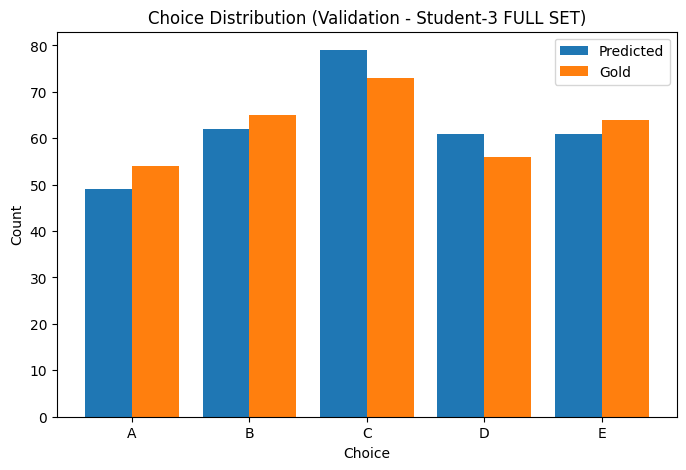

In [9]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

RESULTS_DIR = "/content/drive/MyDrive/Distill_Ensemble/ckpt_student3/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

LETTERS = ["A","B","C","D","E"]

def force_letter_from_logits(logits, tok):
    """Son token logits'inden A-E arasinda zorla sec"""
    scores = {}
    for c in LETTERS:
        ids = tok.encode(c, add_special_tokens=False)
        tid = ids[0]
        scores[c] = float(logits[tid].item())
    return max(scores, key=scores.get)

pred_letters = []
gold_letters = []

model.eval()
device = next(model.parameters()).device

for _, r in df_val.iterrows():
    prompt = build_prompt(r["soru"], r["secenekler"])
    gold = str(r["label"]).strip().upper()

    enc = tok(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        out = model.generate(
            **enc,
            max_new_tokens=3,
            do_sample=False,
            return_dict_in_generate=True,
            output_scores=True,
            pad_token_id=tok.eos_token_id
        )

    gen_text = tok.decode(
        out.sequences[0][enc["input_ids"].shape[1]:],
        skip_special_tokens=True
    ).upper()

    pred = None
    for ch in gen_text:
        if ch in LETTERS:
            pred = ch
            break

    if pred is None:
        last_logits = out.scores[-1][0]
        pred = force_letter_from_logits(last_logits, tok)

    pred_letters.append(pred)
    gold_letters.append(gold)

pred_cnt = Counter(pred_letters)
gold_cnt = Counter(gold_letters)

dist_df = pd.DataFrame({
    "choice": LETTERS,
    "predicted": [pred_cnt[c] for c in LETTERS],
    "gold":      [gold_cnt[c] for c in LETTERS],
})

print(dist_df)
print("TOPLAM VAL:", sum(pred_cnt.values()))

csv_path = os.path.join(RESULTS_DIR, "choice_distribution_full.csv")
dist_df.to_csv(csv_path, index=False)
print("Saved CSV:", csv_path)

x = np.arange(len(LETTERS))
fig = plt.figure(figsize=(8,5))
plt.bar(x - 0.2, dist_df["predicted"], width=0.4, label="Predicted")
plt.bar(x + 0.2, dist_df["gold"], width=0.4, label="Gold")
plt.xticks(x, LETTERS)
plt.xlabel("Choice")
plt.ylabel("Count")
plt.title("Choice Distribution (Validation - Student-3 FULL SET)")
plt.legend()

out_path = os.path.join(RESULTS_DIR, "choice_distribution_full.png")
fig.savefig(out_path, dpi=300, bbox_inches="tight")
print("Saved PNG:", out_path)

plt.show()
plt.close(fig)


In [10]:
import os, re, glob
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from collections import Counter

from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

TEST_PATH = "/content/drive/MyDrive/Distill_Ensemble/my_project_test_500.parquet"
OUT_DIR   = "/content/drive/MyDrive/Distill_Ensemble/ckpt_student3"
RESULTS_DIR = os.path.join(OUT_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

STUDENT_ID = "Metin/gemma-2b-tr-inst"
MAX_LEN = 384

LETTERS = ["A","B","C","D","E"]
ANS_RE = re.compile(r"[A-E]")

def norm_letter(x):
    if x is None:
        return None
    s = str(x).upper()
    m = ANS_RE.search(s)
    return m.group(0) if m else None

def to_letter_from_gt(gt):
    if gt is None:
        return None
    if isinstance(gt, (int, np.integer)):
        if 0 <= int(gt) <= 4:
            return LETTERS[int(gt)]
        return None
    s = str(gt).strip().upper()
    if s.isdigit():
        k = int(s)
        if 0 <= k <= 4:
            return LETTERS[k]
    return norm_letter(s)

def build_prompt(question, options):
    lines = [f"Soru:\n{question}\n"]
    for i, opt in enumerate(options):
        lines.append(f"{LETTERS[i]}) {opt}")
    lines.append("Cevap:")
    return "\n".join(lines)

def force_letter_from_logits(logits, tok):
    scores = {}
    for c in LETTERS:
        ids = tok.encode(c, add_special_tokens=False)
        tid = ids[0]
        scores[c] = float(logits[tid].item())
    return max(scores, key=scores.get)

ckpts = sorted(
    glob.glob(os.path.join(OUT_DIR, "checkpoint-*")),
    key=lambda p: int(os.path.basename(p).split("-")[-1]) if os.path.basename(p).split("-")[-1].isdigit() else -1
)

if not ckpts:
    raise FileNotFoundError(f"{OUT_DIR} altinda checkpoint-* bulunamadi. Student-3 egitimi kaydetmis mi kontrol et.")

CKPT_DIR = ckpts[-1]
print("Using latest checkpoint (Student-3):", CKPT_DIR)

tok = AutoTokenizer.from_pretrained(CKPT_DIR, use_fast=True)
tok.padding_side = "right"
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

base = AutoModelForCausalLM.from_pretrained(
    STUDENT_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

model = PeftModel.from_pretrained(base, CKPT_DIR)
model.eval()
device = next(model.parameters()).device
print("Model device:", device)

df_test = pd.read_parquet(TEST_PATH).copy()
print("Loaded test rows:", len(df_test))

df_test["secenekler"] = df_test["secenekler"].apply(lambda x: x.tolist() if isinstance(x, np.ndarray) else x)

df_test = df_test[df_test["secenekler"].apply(lambda x: isinstance(x, list) and len(x)==5)].reset_index(drop=True)
print("Test rows (valid 5 options):", len(df_test))

df_test["gold"] = df_test["cevap"].apply(to_letter_from_gt)
df_test = df_test[df_test["gold"].isin(LETTERS)].reset_index(drop=True)
print("Test rows (with valid gold):", len(df_test))

preds = []
raw_gen = []

BATCH = 8
for i in range(0, len(df_test), BATCH):
    batch = df_test.iloc[i:i+BATCH]
    prompts = [build_prompt(r["soru"], r["secenekler"]) for _, r in batch.iterrows()]

    enc = tok(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_LEN
    ).to(device)

    with torch.no_grad():
        out = model.generate(
            **enc,
            max_new_tokens=3,
            do_sample=False,
            return_dict_in_generate=True,
            output_scores=True,
            pad_token_id=tok.eos_token_id
        )

    prompt_len = enc["input_ids"].shape[1]
    seqs = out.sequences

    for b in range(seqs.shape[0]):
        gen_text = tok.decode(seqs[b][prompt_len:], skip_special_tokens=True).upper()
        raw_gen.append(gen_text)

        pred = None
        for ch in gen_text:
            if ch in LETTERS:
                pred = ch
                break

        if pred is None:
            pred = force_letter_from_logits(out.scores[-1][b], tok)

        preds.append(pred)

df_test["pred"] = preds
df_test["raw_gen"] = raw_gen

acc = float((df_test["pred"] == df_test["gold"]).mean())
print("TEST ACC (ground truth) [Student-3]:", acc)

cm = pd.crosstab(df_test["gold"], df_test["pred"], rownames=["gold"], colnames=["pred"]).reindex(
    index=LETTERS, columns=LETTERS, fill_value=0
)

pred_cnt = Counter(df_test["pred"].tolist())
gold_cnt = Counter(df_test["gold"].tolist())
dist_df = pd.DataFrame({
    "choice": LETTERS,
    "predicted": [pred_cnt.get(c, 0) for c in LETTERS],
    "gold":      [gold_cnt.get(c, 0) for c in LETTERS],
})

topic_acc_df = (
    df_test.assign(ok=(df_test["pred"] == df_test["gold"]))
    .groupby("konu")["ok"].agg(["count", "mean"])
    .sort_values("mean", ascending=False)
    .reset_index()
    .rename(columns={"mean": "accuracy"})
)

pd.DataFrame([{
    "checkpoint": os.path.basename(CKPT_DIR),
    "test_rows": len(df_test),
    "test_acc_ground_truth": acc,
}]).to_csv(os.path.join(RESULTS_DIR, "test_metrics.csv"), index=False)

df_test.to_parquet(os.path.join(RESULTS_DIR, "test_predictions.parquet"), index=False)
cm.to_csv(os.path.join(RESULTS_DIR, "confusion_matrix.csv"))
dist_df.to_csv(os.path.join(RESULTS_DIR, "test_choice_distribution.csv"), index=False)
topic_acc_df.to_csv(os.path.join(RESULTS_DIR, "test_accuracy_by_topic.csv"), index=False)

x = np.arange(len(LETTERS))
fig = plt.figure(figsize=(8,5))
plt.bar(x - 0.2, dist_df["predicted"], width=0.4, label="Predicted")
plt.bar(x + 0.2, dist_df["gold"], width=0.4, label="Gold")
plt.xticks(x, LETTERS)
plt.xlabel("Choice")
plt.ylabel("Count")
plt.title("Test Choice Distribution (Student-3: Predicted vs Gold)")
plt.legend()
fig.savefig(os.path.join(RESULTS_DIR, "test_choice_distribution.png"), dpi=300, bbox_inches="tight")
plt.close(fig)

fig = plt.figure(figsize=(6,5))
plt.imshow(cm.values, interpolation="nearest")
plt.xticks(np.arange(len(LETTERS)), LETTERS)
plt.yticks(np.arange(len(LETTERS)), LETTERS)
plt.xlabel("Pred")
plt.ylabel("Gold")
plt.title("Confusion Matrix (Student-3 Test)")
for r in range(len(LETTERS)):
    for c in range(len(LETTERS)):
        plt.text(c, r, int(cm.values[r, c]), ha="center", va="center")
fig.savefig(os.path.join(RESULTS_DIR, "confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.close(fig)

print("\nDONE. Student-3 results under:", RESULTS_DIR)


Using latest checkpoint (Student-3): /content/drive/MyDrive/Distill_Ensemble/ckpt_student3/checkpoint-1056


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model device: cuda:0
Loaded test rows: 500
Test rows (valid 5 options): 500
Test rows (with valid gold): 500
TEST ACC (ground truth) [Student-3]: 0.222

DONE. Student-3 results under: /content/drive/MyDrive/Distill_Ensemble/ckpt_student3/results


In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt

IN_PATH = "/content/drive/MyDrive/Distill_Ensemble/student_labels_t3.parquet"
OUT_DIR = "/content/drive/MyDrive/Distill_Ensemble/ckpt_teacher3/analysis_agreement"
os.makedirs(OUT_DIR, exist_ok=True)

LETTERS = ["A","B","C","D","E"]

df = pd.read_parquet(IN_PATH).copy()

need_cols = {"orig_idx", "label", "k"}
missing = need_cols - set(df.columns)
if missing:
    raise ValueError(f"Eksik kolon(lar): {missing}. Dosyada orig_idx, label, k olmali.")

df["label"] = df["label"].astype(str).str.strip().str.upper()
df = df[df["label"].isin(LETTERS)].copy()
df["k"] = pd.to_numeric(df["k"], errors="coerce").astype("Int64")

df = df[df["k"].isin([0, 1])].copy()

df = df.sort_values(["orig_idx", "k"]).drop_duplicates(["orig_idx", "k"], keep="first")

pv = df.pivot(index="orig_idx", columns="k", values="label")

pv2 = pv.dropna(subset=[0, 1]).copy()
pv2 = pv2.rename(columns={0: "k0", 1: "k1"})

pv2["same"] = (pv2["k0"] == pv2["k1"])
same_count = int(pv2["same"].sum())
diff_count = int((~pv2["same"]).sum())
total_pairs = int(len(pv2))

agree_rate = same_count / total_pairs if total_pairs else 0.0
disagree_rate = diff_count / total_pairs if total_pairs else 0.0

print("Toplam (k0,k1 ikisi de var) soru:", total_pairs)
print("Ayni cevap:", same_count, f"({agree_rate:.3f})")
print("Farkli cevap:", diff_count, f"({disagree_rate:.3f})")

pv2_out = pv2.reset_index()
pv2_csv = os.path.join(OUT_DIR, "teacher3_k0_k1_agreement_table.csv")
pv2_out.to_csv(pv2_csv, index=False)
print("Saved:", pv2_csv)

summary_df = pd.DataFrame([{
    "total_pairs": total_pairs,
    "same_count": same_count,
    "diff_count": diff_count,
    "agree_rate": agree_rate,
    "disagree_rate": disagree_rate,
}])
summary_csv = os.path.join(OUT_DIR, "teacher3_agreement_summary.csv")
summary_df.to_csv(summary_csv, index=False)
print("Saved:", summary_csv)

plt.figure(figsize=(6,4))
plt.bar(["Same", "Different"], [same_count, diff_count])
plt.ylabel("Count")
plt.title("Teacher-3: Agreement of k=0 vs k=1")
bar_png = os.path.join(OUT_DIR, "teacher3_agreement_bar.png")
plt.savefig(bar_png, dpi=300, bbox_inches="tight")
plt.close()
print("Saved:", bar_png)

plt.figure(figsize=(5,5))
plt.pie([same_count, diff_count], labels=["Same", "Different"], autopct="%1.1f%%")
plt.title("Teacher-3: Agreement Rate (k=0 vs k=1)")
pie_png = os.path.join(OUT_DIR, "teacher3_agreement_pie.png")
plt.savefig(pie_png, dpi=300, bbox_inches="tight")
plt.close()
print("Saved:", pie_png)

print("\nDONE. Outputs under:", OUT_DIR)


Toplam (k0,k1 ikisi de var) soru: 189
Ayni cevap: 141 (0.746)
Farkli cevap: 48 (0.254)
Saved: /content/drive/MyDrive/Distill_Ensemble/ckpt_teacher3/analysis_agreement/teacher3_k0_k1_agreement_table.csv
Saved: /content/drive/MyDrive/Distill_Ensemble/ckpt_teacher3/analysis_agreement/teacher3_agreement_summary.csv
Saved: /content/drive/MyDrive/Distill_Ensemble/ckpt_teacher3/analysis_agreement/teacher3_agreement_bar.png
Saved: /content/drive/MyDrive/Distill_Ensemble/ckpt_teacher3/analysis_agreement/teacher3_agreement_pie.png

DONE. Outputs under: /content/drive/MyDrive/Distill_Ensemble/ckpt_teacher3/analysis_agreement


In [18]:
import os, re, glob
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from collections import Counter

from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

TEST_PATH = "/content/drive/MyDrive/Distill_Ensemble/my_project_test_500.parquet"
STUDENT_ID = "Metin/gemma-2b-tr-inst"
MAX_LEN = 384
BATCH = 8

OUT_DIR_1 = "/content/drive/MyDrive/Distill_Ensemble/ckpt_student"
OUT_DIR_2 = "/content/drive/MyDrive/Distill_Ensemble/ckpt_student2"
OUT_DIR_3 = "/content/drive/MyDrive/Distill_Ensemble/ckpt_student3"

VAL_ACC_1 = 0.8157894736842105
VAL_ACC_2 = 0.6111111111111112
VAL_ACC_3 = 0.8181818181818182

RESULTS_DIR = "/content/drive/MyDrive/Distill_Ensemble/results_ensemble_s123"
os.makedirs(RESULTS_DIR, exist_ok=True)

LETTERS = ["A","B","C","D","E"]
ANS_RE = re.compile(r"[A-E]")

def norm_letter(x):
    if x is None:
        return None
    s = str(x).upper()
    m = ANS_RE.search(s)
    return m.group(0) if m else None

def to_letter_from_gt(gt):
    if gt is None:
        return None
    if isinstance(gt, (int, np.integer)):
        if 0 <= int(gt) <= 4:
            return LETTERS[int(gt)]
        return None
    s = str(gt).strip().upper()
    if s.isdigit():
        k = int(s)
        if 0 <= k <= 4:
            return LETTERS[k]
    return norm_letter(s)

def build_prompt(question, options):
    lines = [f"Soru:\n{question}\n"]
    for i, opt in enumerate(options):
        lines.append(f"{LETTERS[i]}) {opt}")
    lines.append("Cevap:")
    return "\n".join(lines)

def force_letter_from_logits(logits, tok):
    scores = {}
    for c in LETTERS:
        tid = tok.encode(c, add_special_tokens=False)[0]
        scores[c] = float(logits[tid].item())
    return max(scores, key=scores.get)

def latest_ckpt(out_dir):
    ckpts = sorted(
        glob.glob(os.path.join(out_dir, "checkpoint-*")),
        key=lambda p: int(os.path.basename(p).split("-")[-1]) if os.path.basename(p).split("-")[-1].isdigit() else -1
    )
    if not ckpts:
        raise FileNotFoundError(f"{out_dir} altinda checkpoint-* bulunamadi.")
    return ckpts[-1]

def predict_with_ckpt(df_test, ckpt_dir):
    tok = AutoTokenizer.from_pretrained(ckpt_dir, use_fast=True)
    tok.padding_side = "right"
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    base = AutoModelForCausalLM.from_pretrained(
        STUDENT_ID,
        torch_dtype=torch.bfloat16,
        device_map="auto",
    )
    model = PeftModel.from_pretrained(base, ckpt_dir)
    model.eval()
    device = next(model.parameters()).device

    preds = []
    raw_gen = []

    for i in range(0, len(df_test), BATCH):
        batch = df_test.iloc[i:i+BATCH]
        prompts = [build_prompt(r["soru"], r["secenekler"]) for _, r in batch.iterrows()]

        enc = tok(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_LEN
        ).to(device)

        with torch.no_grad():
            out = model.generate(
                **enc,
                max_new_tokens=3,
                do_sample=False,
                return_dict_in_generate=True,
                output_scores=True,
                pad_token_id=tok.eos_token_id
            )

        prompt_len = enc["input_ids"].shape[1]
        seqs = out.sequences

        for b in range(seqs.shape[0]):
            gen_text = tok.decode(seqs[b][prompt_len:], skip_special_tokens=True).upper()
            raw_gen.append(gen_text)

            pred = None
            for ch in gen_text:
                if ch in LETTERS:
                    pred = ch
                    break
            if pred is None:
                pred = force_letter_from_logits(out.scores[-1][b], tok)

            preds.append(pred)

    del model
    del base
    torch.cuda.empty_cache()

    return preds, raw_gen

def majority_vote(a, b, c, tie_break_order):
    votes = [a, b, c]
    ct = Counter(votes)
    top = ct.most_common()
    if len(top) == 0:
        return "A"
    if top[0][1] >= 2:
        return top[0][0]
    best_model = tie_break_order[0][0]
    if best_model == "m1":
        return a
    if best_model == "m2":
        return b
    return c

df_test = pd.read_parquet(TEST_PATH).copy()
df_test["secenekler"] = df_test["secenekler"].apply(lambda x: x.tolist() if isinstance(x, np.ndarray) else x)
df_test = df_test[df_test["secenekler"].apply(lambda x: isinstance(x, list) and len(x)==5)].reset_index(drop=True)

df_test["gold"] = df_test["cevap"].apply(to_letter_from_gt)
df_test = df_test[df_test["gold"].isin(LETTERS)].reset_index(drop=True)

print("Test rows:", len(df_test))

CKPT_1 = latest_ckpt(OUT_DIR_1)
CKPT_2 = latest_ckpt(OUT_DIR_2)
CKPT_3 = latest_ckpt(OUT_DIR_3)
print("CKPT1:", CKPT_1)
print("CKPT2:", CKPT_2)
print("CKPT3:", CKPT_3)

tie_break = sorted(
    [("m1", VAL_ACC_1), ("m2", VAL_ACC_2), ("m3", VAL_ACC_3)],
    key=lambda x: x[1],
    reverse=True
)

pred1, raw1 = predict_with_ckpt(df_test, CKPT_1)
pred2, raw2 = predict_with_ckpt(df_test, CKPT_2)
pred3, raw3 = predict_with_ckpt(df_test, CKPT_3)

df_test["pred_s1"] = pred1
df_test["pred_s2"] = pred2
df_test["pred_s3"] = pred3

# Merge
final_preds = []
for a,b,c in zip(pred1, pred2, pred3):
    final_preds.append(majority_vote(a,b,c, tie_break))
df_test["pred_merged"] = final_preds

acc_s1 = float((df_test["pred_s1"] == df_test["gold"]).mean())
acc_s2 = float((df_test["pred_s2"] == df_test["gold"]).mean())
acc_s3 = float((df_test["pred_s3"] == df_test["gold"]).mean())
acc_m  = float((df_test["pred_merged"] == df_test["gold"]).mean())

print("TEST ACC Student-1:", acc_s1)
print("TEST ACC Student-2:", acc_s2)
print("TEST ACC Student-3:", acc_s3)
print("TEST ACC MERGED   :", acc_m)

cm = pd.crosstab(df_test["gold"], df_test["pred_merged"], rownames=["gold"], colnames=["pred"]).reindex(
    index=LETTERS, columns=LETTERS, fill_value=0
)

pred_cnt = Counter(df_test["pred_merged"].tolist())
gold_cnt = Counter(df_test["gold"].tolist())
dist_df = pd.DataFrame({
    "choice": LETTERS,
    "predicted": [pred_cnt.get(c, 0) for c in LETTERS],
    "gold":      [gold_cnt.get(c, 0) for c in LETTERS],
})

df_test.to_parquet(os.path.join(RESULTS_DIR, "test_predictions_ensemble.parquet"), index=False)
cm.to_csv(os.path.join(RESULTS_DIR, "confusion_matrix_ensemble.csv"))
dist_df.to_csv(os.path.join(RESULTS_DIR, "test_choice_distribution_ensemble.csv"), index=False)

metrics = pd.DataFrame([{
    "ckpt_s1": os.path.basename(CKPT_1),
    "ckpt_s2": os.path.basename(CKPT_2),
    "ckpt_s3": os.path.basename(CKPT_3),
    "test_rows": len(df_test),
    "acc_student1": acc_s1,
    "acc_student2": acc_s2,
    "acc_student3": acc_s3,
    "acc_merged": acc_m,
    "tie_break_order": str(tie_break),
}])
metrics.to_csv(os.path.join(RESULTS_DIR, "test_metrics_ensemble.csv"), index=False)

x = np.arange(len(LETTERS))
fig = plt.figure(figsize=(8,5))
plt.bar(x - 0.2, dist_df["predicted"], width=0.4, label="Predicted (Merged)")
plt.bar(x + 0.2, dist_df["gold"], width=0.4, label="Gold")
plt.xticks(x, LETTERS)
plt.xlabel("Choice")
plt.ylabel("Count")
plt.title("Test Choice Distribution (Merged: S1+S2+S3 vs Gold)")
plt.legend()
fig.savefig(os.path.join(RESULTS_DIR, "test_choice_distribution_ensemble.png"), dpi=300, bbox_inches="tight")
plt.close(fig)

fig = plt.figure(figsize=(6,5))
plt.imshow(cm.values, interpolation="nearest")
plt.xticks(np.arange(len(LETTERS)), LETTERS)
plt.yticks(np.arange(len(LETTERS)), LETTERS)
plt.xlabel("Pred")
plt.ylabel("Gold")
plt.title("Confusion Matrix (Merged Ensemble Test)")
for r in range(len(LETTERS)):
    for c in range(len(LETTERS)):
        plt.text(c, r, int(cm.values[r, c]), ha="center", va="center")
fig.savefig(os.path.join(RESULTS_DIR, "confusion_matrix_ensemble.png"), dpi=300, bbox_inches="tight")
plt.close(fig)

print("\nDONE. Ensemble results under:", RESULTS_DIR)


Test rows: 500
CKPT1: /content/drive/MyDrive/Distill_Ensemble/ckpt_student/checkpoint-668
CKPT2: /content/drive/MyDrive/Distill_Ensemble/ckpt_student2/checkpoint-472
CKPT3: /content/drive/MyDrive/Distill_Ensemble/ckpt_student3/checkpoint-1056


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

TEST ACC Student-1: 0.212
TEST ACC Student-2: 0.226
TEST ACC Student-3: 0.222
TEST ACC MERGED   : 0.214

DONE. Ensemble results under: /content/drive/MyDrive/Distill_Ensemble/results_ensemble_s123
